# PoD_esti v30 —— 宏像元 SPAD 直方图的检测阈值与探测概率

**这个文件在做什么**：在 1 bit（二值）SPAD 宏像元 + 多发累加的条件下，
把「底噪有多高」「阈值该定多少」「要多强的回波才能以给定概率被检出」「因此能测多远」
这一整条链算通，并给出可复现的蒙特卡洛证据。

**贯穿全文的横轴只有一个：bg**。所有对比都在同一个 bg 上做。

## 文件结构

| 模块 | 内容 | 数据来源 |
|---|---|---|
| 0–4 | 参数、光链路、时间窗、SPAD 引擎、波形示例 | 现算（很快） |
| 5 | 纯噪声 bg 扫描 → peak 分布 + 检测阈值 | **本文件唯一的大重算** |
| 6–7 | PoD 临界能量与全 bg 汇总 | PoD 扫描 |
| 8 | 固定信号 × 全 bg 网格 | 信号扫描 |
| 9–11 | 阈值倍数 ρ、三个统计量、有效 z 值 | **复用模块 5** |
| 12–13 | 所需信号、平方反比测远 | **复用模块 6** |
| 14 | 同信号不同 bg 的 peak 分布 | **复用模块 8** |
| 15 | 宏像元 3×9 vs 3×6 | 独立脚本缓存 |
| 回收站 | 已废弃代码，注释保留 | — |

每个分析模块都是三段式：**计算/载入缓存 → 绘图参数 → 绘图**。
只想调图不想重算的话，改「绘图参数」那个 cell 再跑「绘图」cell 就行。

## 缩写

| 缩写 | 全称 | 含义 |
|---|---|---|
| SPAD | Single-Photon Avalanche Diode | 单光子雪崩二极管 |
| TCSPC | Time-Correlated Single Photon Counting | 时间相关单光子计数 |
| ToF | Time of Flight | 飞行时间 |
| PDE | Photon Detection Efficiency | 光子探测效率 |
| IRF | Instrument Response Function | 仪器响应函数 |
| BRDF | Bidirectional Reflectance Distribution Function | 双向反射分布函数 |
| FAR | False Alarm Rate | 虚警率，`P(peak ≥ T)` |
| PoD | Probability of Detection | 探测概率 |
| MC | Monte Carlo | 蒙特卡洛 |
| EVT | Extreme Value Theory | 极值理论 |
| RC | Resistor-Capacitor | 阻容（过偏压恢复模型）|

## 核心记号

| 记号 | 定义 |
|---|---|
| `hist_i` | 单发直方图，每 bin 取值 0…n_pix |
| `hist_add` | N 发累加直方图，每 bin 取值 0…n_tr |
| `n_tr` | 轨迹数 `= n_pix × N_shots`（3×9、N=4 → 108）|
| **`bg`** | `hist_add` 在统计窗内每 bin 的平均计数。**全项目统一横轴** |
| `noise` | 单发 `hist_i` 每 bin 的平均计数，`= bg / N_shots`。只用来描述单次直方图的底噪 |
| `peak` | 一条 `hist_add` 在统计窗 152 个 bin 内的最大计数 |
| `T` | 检测阈值，**整数计数**（见下） |
| `boost` | 回波能量倍率，`boost=0` 为纯噪声基线 |

> **为什么阈值 T 只能是整数**：`hist_add` 是 27×N 条二值轨迹求和，取值只能是整数 0…n_tr，
> 判定就是 `peak >= T`，所以 `T=10.25` 与 `T=11` 完全等价。阈值曲线看着像阶梯，
> 是因为 **bg 以 0.25 连续步进而 T 只能按 1 跳**，不是画法问题。

## 四条原始需求分别在哪个模块回答

| 需求 | 说明 | 去哪看 |
|---|---|---|
| ① 扫 N=1/2/4，bg 步长 0.25，给阈值曲线；每个 bg 给「单条 hist 的 std 均值」「peak 均值」「peak 标准差」 | 阈值曲线在 **模块 5**；三个统计量在 **模块 10**（①②③ 三个子图） | 模块 5、10 |
| ② 5% / 1% FAR 下，PoD50 与 PoD90 所需的信号均值，随 bg 与 N_shots | **模块 12**（上排净峰高 `S_net`，下排临界发射能量 `E_crit`） | 模块 12 |
| ③ 平方反比下的测距能力 | **模块 13**（①纯 `1/D²`，②再叠大气衰减 `e^{-2αD}`） | 模块 13 |
| ④ peak 分布怎么随 bg 变；peak 均值是不是「信号峰 + bg」直接相加；同信号下 peak 标准差怎么变 | **模块 14** 三排分别回答：①分布形状 ②加法假设检验（含理想「信号峰+bg」斜率 1 参考线）③有信号 vs 无信号的 σ_peak | 模块 14 |

④ 的结论先说在这里：**peak 均值不是简单相加**，实测始终低于理想线（斜率约 0.77–0.85，
N 越大压得越狠），因为 SPAD 是 1 bit——某个 bin 已被环境光点亮时，信号光子再来也不增加计数
（抢占效应）；**σ_peak 在有信号时反而略大于无信号**，信号自身带来的二项涨落盖过了
「峰位被钉住」带来的收窄。

理论推导、公式与历史踩坑不在本文件里，见 `theory_PoD_esti_v30.md`、
`worklog_PoD_esti.md`、`handoff_PoD_esti.md`。

## 模块 0 — 全局参数与常数

整个 notebook 唯一的参数入口：光链路、SPAD 器件、时间窗、宏像元、bg 网格、
FAR 目标、MC 规模、并行线程与缓存文件名。**改任何物理量都只改这个 cell。**

- **FAR_SPECS**：七条虚警率目标（10 ppm → 10%），阈值全算。
- **POD_FARS**：只对这四条（0.5% / 1% / 5% / 10%）求 PoD 临界能量。
- **BG_GRID**：0.25 → 12，步长 0.25，共 48 档；仿真时单发 `noise = bg / N_shots`。
- **RUN_ENGINE_CHECK**：模块 3c 引擎比对开关，默认 `False`。

In [1]:
import json, os, time
# ★ 必须在 import numpy/scipy 之前：多线程自管并行时禁止 BLAS 再开线程
for _k in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS",
           "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ.setdefault(_k, "1")
from concurrent.futures import ThreadPoolExecutor, as_completed
import threading
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.special import erf
from scipy.stats import binom as _binom, norm as _norm

for _f in ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Source Han Sans SC"]:
    try:
        matplotlib.rcParams["font.sans-serif"] = [_f]; break
    except Exception:
        continue
matplotlib.rcParams["axes.unicode_minus"] = False

C_LIGHT  = 2.99792458e8      # 光速 [m/s]
H_PLANCK = 6.62607015e-34    # 普朗克常数 [J·s]

# ============================ 物理参数（与 v45 / v01 逐项一致，未改） ============================
PARAMS = {
    "laser": {
        "wavelength": 905e-9,   # 波长 [m]
        "amp_mode": "peak",     # "peak"=用 P_peak 定幅 / "energy"=用 E_pulse 定幅
        "P_peak": 235.0,        # 峰值光功率 [W]
        "E_pulse": 800e-9,      # 目标单脉冲能量 [J]（amp_mode="energy" 时生效）
        "tau_r": 0.7e-9,        # 双指数上升时间常数 [s]
        "tau_f": 1.9e-9,        # 双指数下降时间常数 [s]
        "x_L": 60e-6,           # 发光面 X 尺寸（慢轴, 1/e² 全宽）[m]
        "y_L": 1150e-6,         # 发光面 Y 尺寸（快轴, 1/e² 全宽）[m]
    },
    "tx": {"f_TX": 36e-3, "D_TX": 12.7e-3, "eta_coupling": 0.87, "T_TX": 0.92},
    "channel": {"alpha": 0.1e-3},          # 消光系数 @905 nm [1/m]（0.1/km ≈ 晴朗）
    "rx": {"f_RX": 25e-3, "D_RX": 13e-3, "eta_RX": 0.82,
           "T_RX": 0.90, "T_filter": 0.90, "filter_bw": 12e-9},
    "spad": {
        "PDE": 0.30,            # PDE_max，满过电压时的峰值光子探测效率
        "DCR": 0.0e3,           # 单像元暗计数率 [cps]
        "jitter_sigma": 100e-12,# IRF 高斯 σ [s]
        "tau_rc": 8.7315e-9,    # RC 恢复时间常数 τ = R·C_J [s]（使计数死区 = 8 ns）
        "Vov_max": 3.3,         # 满过电压 [V]
        "Vth_frac": 0.60,       # 计数所需最小过电压占比
        "reset_mode": "count",
        "resp_shape": "exp",    # 响应函数 g(Vov) 形状
        "resp_k": 3.0,
    },
    "spad_array": {"pitch": 10e-6, "Nx": 9, "Ny": 120, "fill_factor": 1.00},
    "ambient": {
        "enable": True,
        "E_lambda": 0.68,       # 905 nm 处光谱辐照度 [W/m²/nm]，≈100 klux 白天（基准值）
        "surface_rho": 0.10,    # 被观测面反射率（用于环境光漫反射）
    },
    "hist": {"bin_width": 1e-9, "seed": 0},
}
E_PHOTON = H_PLANCK * C_LIGHT / PARAMS["laser"]["wavelength"]

# ============================ PoD_esti 专用参数区（可调） ============================
# ---- 场景 ----
D_TARGET   = 15.0        # 目标距离 [m] → ToF ≈ 100.07 ns，落在 0–200 ns 窗正中
RHO_TARGET = 0.10        # 目标反射率（与 v45 主回波一致）

# ---- 采集窗与统计窗 ----
WIN_LO_NS  = 0.0         # 采集窗起点 [ns]
WIN_HI_NS  = 200.0       # 采集窗终点 [ns]
TRIM_NS    = 24.0        # 掐头去尾各多少 ns（= 3 × 过阈窗宽 8 ns），统计时剔除
WARM_NS    = 50.0        # 光子生成的左侧护带（暖机）[ns]，采样点不动
DT_FINE    = 200e-12     # 逐光子引擎的细网格步长 [s]（同 v45）

# ---- 宏像元（macro pixel）----
MACRO_BX   = 9           # 沿短边 x 的 SPAD 数
MACRO_BY   = 3           # 沿长边 y 的 SPAD 数   ⇒ 27 个 SPAD
N_SHOTS_MAX  = 4                 # ★ v11：一次最多仿 4 发（按 N 分别扫 bg）
N_SHOTS_LIST = [1, 2, 4]         # ★ v11：N∈{1,2,4}；同 bg 网格对比

# ---- ★ v02：第 1、2 步的噪声档，改为【目标 noise 线性等间距】 ----
#   键 = N_shots；值 = 目标底噪（宏像元每 1 ns bin 的平均计数）。
#   两条网格都覆盖到各自二值硬上限（27 / 108）的约 20%，并都包含 noise = 9 与 10。
# ★ v11：各 N 目标 bg 网格统一（步长 0.25）；仿真时 noise_amb = bg / N
BG_GRID = np.round(np.arange(0.25, 12.0 + 1e-9, 0.25), 4)  # 48 档，统一 bg
NOISE_GRID = {n: BG_GRID.copy() for n in N_SHOTS_LIST}       # 目标 = bg（兼容旧键 noise_target）
NOISE_GRID_AMB = BG_GRID.copy()  # 兼容旧变量名；v11 中表示统一 bg 网格，不再表示「单次 ambient 扫轴」
# ---- ★ v05：噪点率 / FAR 目标（ppm + 百分数）----
# tag 用于字典键与文件字段；label 用于图例显示
FAR_SPECS = [
    (10e-6,  "10ppm",  "10 ppm"),
    (100e-6, "100ppm", "100 ppm"),
    (0.001,  "0p1pct", "0.1%"),
    (0.005,  "0p5pct", "0.5%"),
    (0.01,   "1pct",   "1%"),
    (0.05,   "5pct",   "5%"),
    (0.10,   "10pct",  "10%"),      # ★ v30 新增
]
TARGET_FARS = [v for v, _, _ in FAR_SPECS]
FAR_TAG     = {v: t for v, t, _ in FAR_SPECS}
FAR_LABEL   = {v: lab for v, _, lab in FAR_SPECS}
FAR_TAGS    = [t for _, t, _ in FAR_SPECS]
FAR_TAG_TO_LABEL = {t: lab for _, t, lab in FAR_SPECS}
# ★ v30：阈值七条都算（由 peak 分布直接得到，几乎不花钱），
#        但 PoD 临界能量只对下面这四条求解，机时省一大半。
POD_FARS = [0.005, 0.01, 0.05, 0.10]
POD_FAR_TAGS = [FAR_TAG[f] for f in POD_FARS]
N_MC_SIG    = 20_000            # ★ v30：模块 8/14 固定信号扫描（v20 为 8000）
N_MC_NOISE  = 1_000_000         # 每档纯噪声 MC 条数（10 ppm 需 ≥1e6 才有约 10 个越阈事件）
# 分块大小：快速引擎 A 峰值内存 ≈ chunk × n_tr × 4 B × 约 8 个中间数组。
# chunk=100_000 会到 GB 级并因内存压力显著掉速；25_000 约 150 MB，实测最快。
# ---- ★ v05：并行与缓存策略（CPU 支持 20 线程）----
N_WORKERS   = 20         # 全机线程预算
MC_CHUNK    = 5_000      # 纯噪声分块；20 线程时控制峰值内存
NOISE_WORKERS = N_WORKERS
POD_BIN_WORKERS = N_WORKERS  # ★ 单层：外层 20 档并行；内层不再嵌套线程池
POD_MC_CHUNK = 250       # 信号 MC 再切块，喂满内层线程
CHECKPOINT_EVERY = 8     # ★ 每 8 档落盘一次（原先每档压缩写盘会饿死 CPU）

# ---- 第 3 步：能量扫描与 PoD ----
# ---- v04：完整 noise 网格上的自适应 PoD 交点 ----
NOISE_POD = {n: NOISE_GRID[n].copy() for n in N_SHOTS_LIST}
POD_WORKERS = 1  # ★ 内层串行，避免 4×5 嵌套线程 + GIL 吃不满
N_POD_COARSE = 15        # ★ v30：11→15，粗网格间距从 0.4 缩到 ~0.29 decade
N_MC_POD_COARSE = 600    # ★ v30：300→600，粗交点定位误差减半
N_POD_LOCAL_PER_ROOT = 7 # ★ v30：5→7
N_MC_POD_LOCAL = 800     # 每个局部能量点的 MC 次数
N_MC_POD_VERIFY = 5000   # 每个最终临界点的独立验证次数
POD_LEVELS = [0.50, 0.90]
POD_LOG_BOOST_MIN = -6.0
POD_LOG_BOOST_MAX = 2.0
POD_LOCAL_HALF_DECADE = 0.35   # ★ v30：0.22→0.35，粗交点偏一点也还能罩住真根
POD_VERIFY_TOL = 0.02
POD_VERIFY_ROUNDS = 6          # ★ v30：临界点迭代验证的最大轮数（原实现只有 1 步）
SIG_PRE_NS = 3.0         # 信号窗：ToF 之前 [ns]
SIG_POST_NS= 12.0        # 信号窗：ToF 之后 [ns]（覆盖 8 ns 过阈窗 + 余量）
POD_WARM_NS= 60.0        # PoD 子窗的暖机长度 [ns]（≫ 3τ_RC + T_OVER ≈ 34 ns）

# ---- ★ v05 缓存：主文件 + 兼容读取旧版 + 增量检查点 ----
USE_CACHE = True
CACHE_NOISE = "pod_esti_v30_cache_noise.npz"
CACHE_POD   = "pod_esti_v30_cache_pod.npz"
CACHE_SIG   = "pod_esti_v30_cache_signal.npz"  # 模块 9.3 / 15 固定信号
# ★ v30：FAR 列表与 res 结构都变了（新增 10% 与 hist_std），旧缓存一律不复用。
CACHE_NOISE_FALLBACK = []
CACHE_POD_FALLBACK   = []
CACHE_NOISE_CKPT = "pod_esti_v30_cache_noise.partial.npz"
CACHE_POD_CKPT   = "pod_esti_v30_cache_pod.partial.npz"
CACHE_SIG_CKPT   = "pod_esti_v30_cache_signal.partial.npz"

print(f"单光子能量 E_photon = {E_PHOTON:.3e} J")
print(f"目标 D = {D_TARGET} m → ToF = {2*D_TARGET/C_LIGHT*1e9:.2f} ns")
print(f"采集窗 {WIN_LO_NS:.0f}–{WIN_HI_NS:.0f} ns，bin 宽 {PARAMS['hist']['bin_width']*1e9:.0f} ns，"
      f"掐头去尾各 {TRIM_NS:.0f} ns")
print(f"宏像元 {MACRO_BX}×{MACRO_BY} = {MACRO_BX*MACRO_BY} 个 SPAD；N_SHOTS_MAX={N_SHOTS_MAX}；分析 N={N_SHOTS_LIST}")
print(f"  ★ v20 统一 BG_GRID：{BG_GRID[0]:g}→{BG_GRID[-1]:g}，共 {BG_GRID.size} 档，步长 0.25；noise_amb=bg/N")
for _ns, _g in NOISE_GRID.items():
    print(f"  ★ N_shots={_ns} 目标 bg = {_g[0]:g} → {_g[-1]:g}（noise_amb=bg/{_ns}），"
          f"步长 {_g[1]-_g[0]:g}，共 {_g.size} 档（线性等间距）")
print(f"  ★ FAR 目标：{[FAR_LABEL[f] for f in TARGET_FARS]}，每档 {N_MC_NOISE:,} 次 MC")
print(f"  ★ 并行：N_WORKERS={N_WORKERS}，噪声分块={MC_CHUNK:,}；PoD 外层×内层={POD_BIN_WORKERS}×{POD_WORKERS}，POD_MC_CHUNK={POD_MC_CHUNK}；每 {CHECKPOINT_EVERY} 档增量落盘")
print(f"  ★ 缓存主文件：{CACHE_NOISE} / {CACHE_POD}")
print(f"  ★ v30 缓存与 v11/v20 不互通（FAR 列表与 res 字段都变了），本版全量重算")

def _run_cmd_stream(cmd):
    """运行外部命令并实时打印 stdout（耗时多进程扫描用）。"""
    import subprocess, sys
    env = os.environ.copy()
    env["PYTHONUNBUFFERED"] = "1"
    env["PYTHONIOENCODING"] = "utf-8"
    env.setdefault("POD_CORE_QUIET", "1")
    print(f"[run] {' '.join(str(c) for c in cmd)}", flush=True)
    p = subprocess.Popen(
        [str(c) for c in cmd],
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
        text=True, encoding="utf-8", errors="replace",
        bufsize=1, env=env,
    )
    assert p.stdout is not None
    for line in p.stdout:
        print(line, end="", flush=True)
    return int(p.wait())

# ---- ★ v30：全局绘图约定与开关 ----
# 三个 N_shots 在全项目所有图里用同一套颜色，方便跨图对照
_COLORS_N = {1: "tab:blue", 2: "tab:green", 4: "tab:red"}
# 模块 3c 的精确引擎 vs 快速引擎比对很费时，且已在 v20 验证为 bit 级一致。
# 需要重新验证时改成 True。
RUN_ENGINE_CHECK = False
# 模块 3d 的 noise → E_lambda 反解校验单次约 2 分钟，闭合误差已验证 <0.2%。
RUN_INVERSE_CHECK = False

print(f"  ★ v30：FAR 共 {len(FAR_SPECS)} 条；PoD 临界能量只解 "
      f"{[FAR_LABEL[f] for f in POD_FARS]}")
print(f"  ★ v30：信号扫描 {N_MC_SIG:,} MC/档；RUN_ENGINE_CHECK={RUN_ENGINE_CHECK}")

单光子能量 E_photon = 2.195e-19 J
目标 D = 15.0 m → ToF = 100.07 ns
采集窗 0–200 ns，bin 宽 1 ns，掐头去尾各 24 ns
宏像元 9×3 = 27 个 SPAD；N_SHOTS_MAX=4；分析 N=[1, 2, 4]
  ★ v20 统一 BG_GRID：0.25→12，共 48 档，步长 0.25；noise_amb=bg/N
  ★ N_shots=1 目标 bg = 0.25 → 12（noise_amb=bg/1），步长 0.25，共 48 档（线性等间距）
  ★ N_shots=2 目标 bg = 0.25 → 12（noise_amb=bg/2），步长 0.25，共 48 档（线性等间距）
  ★ N_shots=4 目标 bg = 0.25 → 12（noise_amb=bg/4），步长 0.25，共 48 档（线性等间距）
  ★ FAR 目标：['10 ppm', '100 ppm', '0.1%', '0.5%', '1%', '5%', '10%']，每档 1,000,000 次 MC
  ★ 并行：N_WORKERS=20，噪声分块=5,000；PoD 外层×内层=20×1，POD_MC_CHUNK=250；每 8 档增量落盘
  ★ 缓存主文件：pod_esti_v30_cache_noise.npz / pod_esti_v30_cache_pod.npz
  ★ v30 缓存与 v11/v20 不互通（FAR 列表与 res 字段都变了），本版全量重算
  ★ v30：FAR 共 7 条；PoD 临界能量只解 ['0.5%', '1%', '5%', '10%']
  ★ v30：信号扫描 20,000 MC/档；RUN_ENGINE_CHECK=False


## 模块 1 — 光链路：从发射脉冲到单个 SPAD 上的光子率

从 `lidar_histogram_sim_v45.ipynb` 逐行移植，函数与参数一致。依次给出激光脉冲波形、
目标回波、环境光背景，以及经光学系统与 **PDE**（Photon Detection Efficiency，光子探测效率）
后落到单个 SPAD 上的光子到达率。

- **BRDF**（Bidirectional Reflectance Distribution Function，双向反射分布函数）：目标散射模型。

In [2]:
# ---- 激光脉冲 ----
def _pulse_norm(p=PARAMS):
    tr, tf_ = p["laser"]["tau_r"], p["laser"]["tau_f"]
    t_peak = np.log(tf_ / tr) / (1.0 / tr - 1.0 / tf_)
    s_peak = np.exp(-t_peak / tf_) - np.exp(-t_peak / tr)
    area_shape = tf_ - tr
    A = (p["laser"]["E_pulse"] * s_peak / area_shape
         if p["laser"]["amp_mode"] == "energy" else p["laser"]["P_peak"])
    return A, s_peak, t_peak, area_shape

def pulse_temporal(t, p=PARAMS):
    """激光时域光功率 P(t) [W]（双指数）。"""
    tr, tf_ = p["laser"]["tau_r"], p["laser"]["tau_f"]
    A, s_peak, _, _ = _pulse_norm(p)
    tpos = np.clip(t, 0.0, None)
    shape = np.where(t >= 0, np.exp(-tpos / tf_) - np.exp(-tpos / tr), 0.0)
    return A * np.clip(shape, 0.0, None) / s_peak

def pulse_energy(p=PARAMS):
    """单脉冲发射能量 [J] = ∫P(t)dt（双指数解析值 = A/s_peak·(τ_f−τ_r)）。"""
    A, s_peak, _, area_shape = _pulse_norm(p)
    return A / s_peak * area_shape

# ---- 发射光学 / 信道 / 目标 ----
def tx_derived(p=PARAMS):
    x_L, y_L = p["laser"]["x_L"], p["laser"]["y_L"]
    f_TX = p["tx"]["f_TX"]; lam = p["laser"]["wavelength"]; w0 = p["tx"]["D_TX"] / 2.0
    tgx, tgy = x_L / (2 * f_TX), y_L / (2 * f_TX)
    tdf = lam / (np.pi * w0)
    tx_, ty_ = np.hypot(tgx, tdf), np.hypot(tgy, tdf)
    return {"theta_x": tx_, "theta_y": ty_, "zR_x": w0 / tx_, "zR_y": w0 / ty_, "w0": w0,
            "eta_TX": p["tx"]["eta_coupling"] * p["tx"]["T_TX"]}

def atm_transmission(D, p=PARAMS):
    return np.exp(-p["channel"]["alpha"] * D)

def beam_spot_size(D, p=PARAMS):
    tx = tx_derived(p); w0 = tx["w0"]
    return (2 * w0 * np.sqrt(1 + (D / tx["zR_x"])**2),
            2 * w0 * np.sqrt(1 + (D / tx["zR_y"])**2))

def time_of_flight(D):
    return 2.0 * D / C_LIGHT

def lambertian_brdf(rho):
    return rho / np.pi

def echo_range_broadening_sigma(D, tilt_deg, p=PARAMS):
    """目标倾斜带来的几何测距展宽 σ [s]（本文件 tilt=0，返回 0）。"""
    x_D, y_D = beam_spot_size(D, p)
    w = 0.5 * np.hypot(x_D, y_D) / np.sqrt(2)
    dz = w * np.tan(np.deg2rad(tilt_deg))
    return (2.0 * dz / C_LIGHT) / 2.0

# ---- 接收光学 ----
def rx_area(p=PARAMS):
    return np.pi * (p["rx"]["D_RX"] / 2.0)**2

def airy_diameter(p=PARAMS):
    fnum = p["rx"]["f_RX"] / p["rx"]["D_RX"]
    return 2.44 * p["laser"]["wavelength"] * fnum

def rx_image_spot_size(D, p=PARAMS):
    """RX 像面光斑 1/e² 全宽 [m] = 几何成像 ⊕ 衍射艾里斑（平方和）。"""
    x_D, y_D = beam_spot_size(D, p)
    s_airy = airy_diameter(p)
    return (np.hypot((x_D / D) * p["rx"]["f_RX"], s_airy),
            np.hypot((y_D / D) * p["rx"]["f_RX"], s_airy))

def link_factor(echo, p=PARAMS):
    """从发射光功率到单位收集比例下接收光功率的总链路因子（无量纲）。"""
    tx = tx_derived(p); D = echo["D"]
    Omega = rx_area(p) / D**2
    eta_rx_total = p["rx"]["eta_RX"] * p["rx"]["T_RX"] * p["rx"]["T_filter"]
    return (tx["eta_TX"] * echo["frac"] * lambertian_brdf(echo["rho"]) * Omega
            * atm_transmission(D, p)**2 * eta_rx_total)

# ---- 像元收集比例 & 环境光 ----
def gaussian_kernel(sigma, dt, n_sigma=5):
    if sigma <= 0:
        return np.array([1.0 / dt])
    half = max(1, int(np.ceil(n_sigma * sigma / dt)))
    tk = np.arange(-half, half + 1) * dt
    k = np.exp(-0.5 * (tk / sigma)**2)
    return k / (k.sum() * dt)

def pixel_grid(p=PARAMS):
    a = p["spad_array"]; pitch = a["pitch"]
    xi = (np.arange(a["Nx"]) - (a["Nx"] - 1) / 2.0) * pitch
    yj = (np.arange(a["Ny"]) - (a["Ny"] - 1) / 2.0) * pitch
    return xi, yj

def pixel_collection_matrix(D, p=PARAMS):
    """每个像元在椭圆高斯像斑上的空间收集比例 f_pix[i,j]（∑ ≤ 1，其余漏到阵列外）。"""
    sx, sy = rx_image_spot_size(D, p)
    sig_x, sig_y = sx / 4.0, sy / 4.0
    xi, yj = pixel_grid(p); pitch = p["spad_array"]["pitch"]
    def _frac(centers_, sig):
        lo = (centers_ - pitch / 2.0) / (np.sqrt(2) * sig)
        hi = (centers_ + pitch / 2.0) / (np.sqrt(2) * sig)
        return 0.5 * (erf(hi) - erf(lo))
    fx = _frac(xi, sig_x); fy = _frac(yj, sig_y)
    return np.outer(fx, fy), fx, fy

def ambient_photon_rate_per_pixel(p=PARAMS, e_lambda=None):
    """单像元环境光【光子到达率】[ph/s]，不含 PDE。
    e_lambda 不给则用 PARAMS 里的基准值 0.68 W/m²/nm（≈100 klux）。"""
    if not p["ambient"]["enable"]:
        return 0.0
    E_l = p["ambient"]["E_lambda"] if e_lambda is None else e_lambda
    E = E_l * (p["rx"]["filter_bw"] * 1e9)                        # 带内辐照 [W/m²]
    L = p["ambient"]["surface_rho"] * E / np.pi                   # 辐亮度 [W/m²/sr]
    iFOV = p["spad_array"]["pitch"] / p["rx"]["f_RX"]
    P_amb = L * iFOV**2 * rx_area(p)
    return P_amb / E_PHOTON * p["rx"]["T_RX"] * p["rx"]["T_filter"]

def signal_photon_rate_fine(echo, f_pix_ij, tf_grid, p=PARAMS):
    """单 SPAD 信号【光子到达率】[ph/s]（不含 PDE），在精细网格 tf_grid 上。"""
    t0 = time_of_flight(echo["D"])
    r = (pulse_temporal(tf_grid - t0, p) * link_factor(echo, p) / E_PHOTON * f_pix_ij)
    sig_b = echo_range_broadening_sigma(echo["D"], echo.get("tilt_deg", 0.0), p)
    if sig_b > 0:
        dtf = tf_grid[1] - tf_grid[0]
        r = np.convolve(r, gaussian_kernel(sig_b, dtf), mode="same") * dtf
    return r

# ---- 自检 ----
ECHO0 = {"D": D_TARGET, "rho": RHO_TARGET, "frac": 1.00, "tilt_deg": 0.0}
E_PULSE_BASE = pulse_energy()
_sx, _sy = rx_image_spot_size(D_TARGET)
print("="*78)
print(f"单脉冲发射能量 E_pulse = {E_PULSE_BASE*1e9:.1f} nJ（P_peak={PARAMS['laser']['P_peak']:.0f} W，"
      f"双指数 τ_r={PARAMS['laser']['tau_r']*1e9:.1f} / τ_f={PARAMS['laser']['tau_f']*1e9:.1f} ns）")
print(f"D={D_TARGET} m: 像面光斑 1/e² 全宽 x={_sx*1e6:.2f} µm, y={_sy*1e6:.2f} µm")
print(f"链路因子 link_factor = {link_factor(ECHO0):.3e}（ρ={RHO_TARGET}）")
print(f"环境光基准 E_lambda = {PARAMS['ambient']['E_lambda']} W/m²/nm（≈100 klux）："
      f"单像元 r_amb = {ambient_photon_rate_per_pixel():.3e} ph/s  "
      f"→ 探测率 r_det = r_amb·PDE = {ambient_photon_rate_per_pixel()*PARAMS['spad']['PDE']:.3e} cps")

单脉冲发射能量 E_pulse = 799.4 nJ（P_peak=235 W，双指数 τ_r=0.7 / τ_f=1.9 ns）
D=15.0 m: 像面光斑 1/e² 全宽 x=46.98 µm, y=798.91 µm
链路因子 link_factor = 9.953e-09（ρ=0.1）
环境光基准 E_lambda = 0.68 W/m²/nm（≈100 klux）：单像元 r_amb = 2.036e+07 ph/s  → 探测率 r_det = r_amb·PDE = 6.107e+06 cps


## 模块 2 — 时间窗、宏像元与掐头去尾

定义采集窗、1 ns bin 网格、宏像元（3×9 = 27 个 SPAD），以及**统计窗**：
采集窗前后各掐掉 `TRIM_NS`，只在中间 152 个 bin 上取 peak 和算 bg，
避开暖机段与截断边缘。全项目所有统计量都在这个统计窗里算。

In [3]:
# ---- SPAD 器件参数（从 PARAMS["spad"] 解出全局量，命名沿用 v45） ----
_sp = PARAMS["spad"]
PDE        = _sp["PDE"]
JIT        = _sp["jitter_sigma"]
TAU_RC     = _sp["tau_rc"]
VTH_FRAC   = _sp["Vth_frac"]
RESP_SHAPE = _sp["resp_shape"]
RESP_K     = _sp["resp_k"]
jit = JIT

T_OVER = -TAU_RC * np.log(1.0 - VTH_FRAC)          # 过阈窗宽 ≈ 8.00 ns（导出量）

# ---- 时间窗与 bin ----
BIN_W  = PARAMS["hist"]["bin_width"]
WIN_LO, WIN_HI = WIN_LO_NS * 1e-9, WIN_HI_NS * 1e-9
NBINS  = int(round((WIN_HI - WIN_LO) / BIN_W))
CENTERS = WIN_LO + (np.arange(NBINS) + 0.5) * BIN_W        # bin 中心 [s]
TC_NS   = CENTERS * 1e9

# 统计窗（掐头去尾）：bin 中心落在 [TRIM, WIN_HI-TRIM] 内
_keep = (TC_NS >= TRIM_NS) & (TC_NS <= WIN_HI_NS - TRIM_NS)
IDX_STAT = np.where(_keep)[0]
I_STAT0, I_STAT1 = int(IDX_STAT[0]), int(IDX_STAT[-1] + 1)   # 切片 [I_STAT0, I_STAT1)
N_STAT = I_STAT1 - I_STAT0

# 光子生成网格（左扩护带，采样点不动）
TF_GEN = np.arange(WIN_LO - WARM_NS*1e-9, WIN_HI, DT_FINE)

# ---- 宏像元 ----
N_PIX_MACRO = MACRO_BX * MACRO_BY
FPIX, FX, FY = pixel_collection_matrix(D_TARGET)
_n_macro = PARAMS["spad_array"]["Ny"] // MACRO_BY
_macro_fsum = np.array([FPIX[:, m*MACRO_BY:(m+1)*MACRO_BY].sum() for m in range(_n_macro)])
M_PEAK = int(_macro_fsum.argmax())
F_VALS = FPIX[:, M_PEAK*MACRO_BY:(M_PEAK+1)*MACRO_BY].ravel()   # 峰值宏像元 27 个 SPAD 的收集比例

# ---- 环境光基准速率 ----
R_AMB_BASE = ambient_photon_rate_per_pixel()       # E_lambda = 0.68 时的单像元光子率 [ph/s]

# ---- 信号率形状（单位收集比例、boost=1）----
T0_SIG   = time_of_flight(D_TARGET)
T0_SIG_NS= T0_SIG * 1e9
R_SIG_UNIT_GEN = signal_photon_rate_fine(ECHO0, 1.0, TF_GEN)    # [ph/s]，f_pix=1

print("="*78)
print(f"过阈窗宽 T_OVER = -τ_RC·ln(1-Vth_frac) = {T_OVER*1e9:.3f} ns")
print(f"采集窗 {WIN_LO_NS:.0f}–{WIN_HI_NS:.0f} ns → {NBINS} 个 1 ns bin（中心 "
      f"{TC_NS[0]:.1f} … {TC_NS[-1]:.1f} ns）")
print(f"统计窗（掐头去尾 {TRIM_NS:.0f} ns）→ bin 下标 [{I_STAT0}, {I_STAT1}) 共 {N_STAT} 个，"
      f"中心 {TC_NS[I_STAT0]:.1f} … {TC_NS[I_STAT1-1]:.1f} ns")
print(f"生成网格 TF_GEN：{TF_GEN[0]*1e9:.1f} … {TF_GEN[-1]*1e9:.1f} ns，"
      f"步长 {DT_FINE*1e12:.0f} ps，共 {TF_GEN.size} 点（左扩护带 {WARM_NS:.0f} ns）")
print(f"宏像元 {MACRO_BX}×{MACRO_BY} = {N_PIX_MACRO} SPAD；峰值宏像元 m={M_PEAK}"
      f"（Σf_pix={_macro_fsum[M_PEAK]:.4f}）")
for ns_ in N_SHOTS_LIST:
    print(f"  N_shots={ns_} → 轨迹数 n_tr = 27×{ns_} = {N_PIX_MACRO*ns_}，"
          f"二值硬上限 macro_cap = {N_PIX_MACRO*ns_}")
print(f"信号峰位 ToF = {T0_SIG_NS:.2f} ns（bin 下标 {int(T0_SIG_NS)}）")
print(f"环境光基准 r_amb = {R_AMB_BASE:.3e} ph/s，r_det = {R_AMB_BASE*PDE:.3e} cps")

过阈窗宽 T_OVER = -τ_RC·ln(1-Vth_frac) = 8.001 ns
采集窗 0–200 ns → 200 个 1 ns bin（中心 0.5 … 199.5 ns）
统计窗（掐头去尾 24 ns）→ bin 下标 [24, 176) 共 152 个，中心 24.5 … 175.5 ns
生成网格 TF_GEN：-50.0 … 200.0 ns，步长 200 ps，共 1251 点（左扩护带 50 ns）
宏像元 9×3 = 27 SPAD；峰值宏像元 m=19（Σf_pix=0.0597）
  N_shots=1 → 轨迹数 n_tr = 27×1 = 27，二值硬上限 macro_cap = 27
  N_shots=2 → 轨迹数 n_tr = 27×2 = 54，二值硬上限 macro_cap = 54
  N_shots=4 → 轨迹数 n_tr = 27×4 = 108，二值硬上限 macro_cap = 108
信号峰位 ToF = 100.07 ns（bin 下标 100）
环境光基准 r_amb = 2.036e+07 ph/s，r_det = 6.107e+06 cps


## 模块 3 — SPAD 二值采样引擎

SPAD 是 1 bit 器件：一个 1 ns bin 内无论来多少光子，最多只记 1 次。雪崩之后过偏压按
**RC**（Resistor-Capacitor，阻容）规律恢复，探测能力随之同步回升；期间若再次雪崩，
电压被打回 0 重新恢复。不是简单的固定死时间。

| 引擎 | 用途 |
|---|---|
| `spad_binary_trace` | 精确版（v45 原样），作基准 |
| `noise_macro_hist_fast` | 快速版 A：$H^{-1}$ 直查表，仅纯环境光 |
| `binary_macro_stepping` | 快速版 B：同步时间步进，含信号 |
| `stats_from_hist_i` | 由单发直方图派生各 N 的充分统计量 |

三个引擎为什么等价，见 `theory_engine_equivalence.md`。

In [4]:
def spad_response_g(vov_frac, shape="linear", k=3.0):
    """SPAD 对光子的响应函数 g(vov_frac) ∈ [0,1]；触发概率 = PDE_max·g。
    约束 g(0)=0（Vov=0 完全不响应）、g(1)=1（满 Vov 触发概率 = PDE_max）。"""
    x = np.clip(vov_frac, 0.0, 1.0)
    if shape == "exp":
        return (1.0 - np.exp(-k * x)) / (1.0 - np.exp(-k))
    return x


def spad_binary_trace(r_sig_fine, r_amb_ph, tf, centers, PDE_max, tau_rc, Vth_frac,
                      jitter_sigma, rng, t_over, t_laser=0.0,
                      resp_shape="linear", resp_k=3.0):
    """【精确引擎，v45 cell 32 原样移植（去掉归因分支）】
    单 SPAD、单次 shot 的二值采样，返回长度 len(centers) 的 int8 数组（每 bin 0/1）。"""
    dt = tf[1] - tf[0]
    nbn = len(centers)
    out = np.zeros(nbn, dtype=np.int8)
    inv_tau = 1.0 / tau_rc
    mu = (r_sig_fine + r_amb_ph) * dt
    n_ph = rng.poisson(mu)
    if n_ph.sum() == 0:
        return out
    t_arr = np.repeat(tf, n_ph)                 # 逐光子到达时刻（升序）
    u = rng.random(t_arr.size)
    last = -1e30
    av = []
    for k in range(t_arr.size):
        t = t_arr[k]
        d = (t - last) * inv_tau
        vov_frac = 1.0 - np.exp(-d) if d < 700 else 1.0
        if u[k] < PDE_max * spad_response_g(vov_frac, resp_shape, resp_k):
            av.append(t); last = t             # 二值：雪崩即复位
    if not av:
        return out
    av = np.asarray(av)
    if jitter_sigma > 0:
        av = av + rng.normal(0.0, jitter_sigma, av.size)   # IRF 抖动
    for tt in av:
        lo = tt + t_laser
        out[(centers >= lo) & (centers < lo + t_over)] = 1
    return out


def macro_hist_exact(n_real, f_arr, r_sig_unit, r_amb, tf, centers, rng, boost=1.0):
    """用精确引擎堆出 (n_real, nbins) 宏像元二值累加直方图（f_arr 已含 N_shots 平铺）。"""
    nb = len(centers)
    h = np.zeros((n_real, nb))
    for i in range(n_real):
        acc = np.zeros(nb, dtype=np.int32)
        for fij in f_arr:
            acc += spad_binary_trace(r_sig_unit * fij * boost, r_amb, tf, centers,
                                     PDE, TAU_RC, VTH_FRAC, JIT, rng, T_OVER, 0.0,
                                     RESP_SHAPE, RESP_K)
        h[i] = acc
    return h

In [5]:
# ============================================================================
# 更新过程工具：累积强度 H、生存函数 S、平衡态点亮概率 p_bin、以及 noise -> r_det 反解
# ============================================================================
U_C    = 20.0 * TAU_RC     # 超过 20τ 后 g≈1，hazard 恒为 r_det ⇒ 尾部可解析积分
E_MAX  = 30.0              # -ln(U) 的截断：P(E>30)=e^-30≈9e-14，远低于任何 MC 规模
N_ETAB = 262144            # 反函数直查表的点数（均匀 E 网格）


def build_renewal_table(r_det, tau_rc=TAU_RC, resp_shape=RESP_SHAPE, resp_k=RESP_K,
                        d_max=None, n_grid=400001):
    """累积强度 H(Δ) = ∫₀^Δ r_det·g(1−e^{−s/τ}) ds，在 [0, d_max] 上数值积分。"""
    if d_max is None:
        d_max = E_MAX / r_det + 40 * tau_rc
    d = np.linspace(0.0, d_max, n_grid)
    h = r_det * spad_response_g(1.0 - np.exp(-d / tau_rc), resp_shape, resp_k)
    H = np.concatenate([[0.0], np.cumsum(0.5 * (h[1:] + h[:-1]) * np.diff(d))])
    return d, H


def p_bin_equilibrium(r_det, t_over=T_OVER, tau_rc=TAU_RC,
                      resp_shape=RESP_SHAPE, resp_k=RESP_K, n=200001):
    """更新过程【平衡态】下，某个 1 ns 采样点被点亮的概率 p_bin，以及平均雪崩间隔 mu。

        点亮 ⟺ 回溯时间 B < T_OVER；平衡态密度 f_B(u) = S(u)/mu
        ⇒ p_bin = (1/mu)·∫₀^{T_OVER} S(u) du,   S(u)=exp(−H(u)),  mu=∫₀^∞ S

    积分网格只覆盖 [0, U_C=20τ]（步长 ≈0.9 ps，足以分辨 8 ns 的过阈窗）；
    尾部 u > U_C 时 hazard 恒为 r_det ⇒ ∫_{U_C}^∞ S = S(U_C)/r_det，解析补上。
    ⚠️ v01 曾把网格设成 d_max=40/r_det 且点数固定，低噪声档步长会粗到上百 ns，
       连 T_OVER 都分辨不了 —— 这里固定 [0, U_C] 就是为了避开这个坑。
    """
    d = np.linspace(0.0, U_C, n)
    h = r_det * spad_response_g(1.0 - np.exp(-d / tau_rc), resp_shape, resp_k)
    H = np.concatenate([[0.0], np.cumsum(0.5 * (h[1:] + h[:-1]) * np.diff(d))])
    S = np.exp(-H)
    mu = np.trapezoid(S, d) + S[-1] / r_det
    m = d <= t_over
    return float(np.trapezoid(S[m], d[m]) / mu), float(mu)


def r_det_for_noise(noise_target, n_tr, lo=1e2, hi=1e11, iters=45):
    """二分反解：使平衡态底噪 = noise_target（宏像元每 bin 平均计数）的 r_det [cps]。"""
    p_t = noise_target / n_tr
    if not (0.0 < p_t < 1.0):
        return np.nan
    for _ in range(iters):
        mid = np.sqrt(lo * hi)
        if p_bin_equilibrium(mid, n=20001)[0] < p_t:
            lo = mid
        else:
            hi = mid
    return float(np.sqrt(lo * hi))


def e_lambda_for_r_det(r_det, p=PARAMS):
    """由所需的单 SPAD 环境探测率反推 E_lambda [W/m²/nm]（链路对 E_lambda 线性）。"""
    return p["ambient"]["E_lambda"] * (r_det / PDE) / R_AMB_BASE


# ============================================================================
# 快速引擎 A（★ v02 优化版）：更新过程反函数【O(1) 直查表】+ float32
# ============================================================================
def build_inv_table(r_det, tau_rc=TAU_RC, resp_shape=RESP_SHAPE, resp_k=RESP_K,
                    e_max=E_MAX, n_etab=N_ETAB):
    """把 Δ = H⁻¹(E) 重采样到【均匀 E 网格】，使采样变成 O(1) 直查 + 线性插值。
    只在建表时做一次二分（np.interp），之后每次采样都是常数时间。"""
    d, H = build_renewal_table(r_det, tau_rc, resp_shape, resp_k)
    e_grid = np.linspace(0.0, e_max, n_etab)
    inv = np.interp(e_grid, H, d).astype(np.float32)
    return inv, np.float32((n_etab - 1) / e_max)


def noise_macro_hist_fast(n_real, n_tr, r_det, rng, win_lo=None, win_hi=None,
                          nbins=None, bin_w=None, t_over=T_OVER, jitter=JIT,
                          warm=None, max_round=20000, inv_tab=None):
    """纯环境光下的 (n_real, nbins) 宏像元二值累加直方图（int32）。

    n_tr = 宏像元 SPAD 数 × N_shots。纯噪声时各 SPAD、各 shot 独立同分布，
    可以直接折进"轨迹数"这一个维度。

    覆盖技巧：bin 被点亮 ⟺ 它之前最近一次雪崩距它 < T_OVER。
    于是把每次雪崩的窗口【在下一次雪崩处截断】，得到互不重叠的区间，
    就能用「差分数组 + bincount + cumsum」直接累进 (实现数, bin 数) 矩阵，无需逐轨迹展开。
    """
    win_lo = WIN_LO if win_lo is None else win_lo
    win_hi = WIN_HI if win_hi is None else win_hi
    nbins  = NBINS  if nbins  is None else nbins
    bin_w  = BIN_W  if bin_w  is None else bin_w
    warm   = WARM_NS*1e-9 if warm is None else warm
    if inv_tab is None:
        inv_tab = build_inv_table(r_det)
    inv, scale = inv_tab
    n_e = inv.size

    t_start = np.float32(win_lo - warm)
    wl = np.float32(win_lo); wh = np.float32(win_hi)
    tov = np.float32(t_over); bw = np.float32(bin_w)
    D_FLOOR = np.float32(1e-13)        # 等待时间下限（0.1 ps），兜底防止时间不前进而空转

    N = n_real * n_tr
    ri = np.repeat(np.arange(n_real, dtype=np.int32), n_tr)
    # 首个间隔：起始时刻完全恢复 (vov=1) ⇒ Exp(r_det)，与精确引擎 last=-1e30 的初值对应
    t_j = (t_start + rng.exponential(1.0 / r_det, N)).astype(np.float32)
    j_j = (rng.normal(0.0, jitter, N).astype(np.float32) if jitter > 0
           else np.zeros(N, np.float32))

    lo_all, hi_all, ri_all = [], [], []
    for _ in range(max_round):
        keep = t_j < wh
        if not keep.any():
            break
        t_j = t_j[keep]; j_j = j_j[keep]; ri = ri[keep]
        m_ = t_j.size
        # Δ = H⁻¹(E)，E ~ Exp(1)。用 standard_exponential 而不是 -log(random())：
        # 后者在 float32 下有 2^-24 概率取到精确 0 → -log(0)=inf → NaN 污染 + 死循环。
        E = rng.standard_exponential(m_, dtype=np.float32)
        x = np.minimum(E, np.float32(E_MAX)) * scale
        i0 = x.astype(np.int32)
        np.clip(i0, 0, n_e - 2, out=i0)
        fr = x - i0
        delta = np.maximum(inv[i0] * (1.0 - fr) + inv[i0 + 1] * fr, D_FLOOR)
        t_n = t_j + delta
        j_n = (rng.normal(0.0, jitter, m_).astype(np.float32) if jitter > 0
               else np.zeros(m_, np.float32))

        lo_all.append(t_j + j_j)
        hi_all.append(np.minimum(t_j + j_j + tov, t_n + j_n))   # 被下一次雪崩截断
        ri_all.append(ri.copy())
        t_j, j_j = t_n, j_n

    diff = np.zeros(n_real * (nbins + 1), dtype=np.int32)
    if lo_all:
        lo_t = np.concatenate(lo_all); hi_t = np.concatenate(hi_all)
        rr = np.concatenate(ri_all).astype(np.int64)
        b_lo = np.clip(np.ceil((lo_t - wl) / bw - 0.5), 0, nbins).astype(np.int64)
        b_hi = np.clip(np.ceil((hi_t - wl) / bw - 0.5), 0, nbins).astype(np.int64)
        m = b_hi > b_lo
        if m.any():
            base = rr[m] * (nbins + 1)
            diff = (np.bincount(base + b_lo[m], minlength=diff.size)
                    - np.bincount(base + b_hi[m], minlength=diff.size)).astype(np.int32)
    return np.cumsum(diff.reshape(n_real, nbins + 1), axis=1)[:, :nbins]


# ============================================================================
# 快速引擎 B：同步时间步进（信号 + 环境），在「实现 × SPAD」维度向量化
# ============================================================================
def binary_macro_stepping(n_real, f_arr, r_sig_unit, tgrid, r_amb, centers, rng,
                          boost=1.0, tau_rc=TAU_RC, t_over=T_OVER, pde=PDE,
                          jitter=JIT, resp_shape=RESP_SHAPE, resp_k=RESP_K):
    """返回 (n_real, len(centers)) 宏像元二值累加直方图（int32）。f_arr 已含 N_shots 平铺。

    与 spad_binary_trace 逐步等价：一个细网格步内到达 n~Poisson(μ) 个光子、各自以 φ 触发，
    故该步「至少触发一次」的概率 = 1 − e^{−μ·φ}，且步内至多一次雪崩
    （首个触发后 Vov=0 ⇒ g(0)=0 ⇒ 同步内后续光子不可能再触发）。
    因 t − t_last 恒为步长整数倍，φ 可预先做成查表 phi[age]。
    """
    dt = tgrid[1] - tgrid[0]
    n_tr = f_arr.size
    nb = len(centers)
    k_max = int(np.ceil(20.0 * tau_rc / dt))
    phi = pde * spad_response_g(1.0 - np.exp(-np.arange(k_max + 1) * dt / tau_rc),
                                resp_shape, resp_k)
    age  = np.full((n_real, n_tr), k_max, dtype=np.int32)
    tcov = np.full((n_real, n_tr), -1e30)
    hist = np.zeros((n_real, nb), dtype=np.int32)
    mu_all = (r_sig_unit[:, None] * f_arr[None, :] * boost + r_amb) * dt
    ib = 0
    for i in range(tgrid.size):
        t = tgrid[i]
        while ib < nb and centers[ib] < t:      # 先出 bin，再处理本步雪崩
            d = centers[ib] - tcov
            hist[:, ib] = ((d >= 0) & (d < t_over)).sum(axis=1)
            ib += 1
        p = -np.expm1(-mu_all[i][None, :] * phi[age])
        fire = rng.random((n_real, n_tr)) < p
        age = np.minimum(age + 1, k_max)
        if fire.any():
            age[fire] = 1
            nf = int(fire.sum())
            tcov[fire] = t + (rng.normal(0.0, jitter, nf) if jitter > 0 else 0.0)
    while ib < nb:
        d = centers[ib] - tcov
        hist[:, ib] = ((d >= 0) & (d < t_over)).sum(axis=1)
        ib += 1
    return hist




# ============================================================================
# ★ v10：per-shot hist_i 与前缀和
# ============================================================================
def noise_hists_per_shot(n_real, n_shots, r_det, rng, inv_tab=None):
    """纯噪声 hist_i：(n_real, n_shots, NBINS)，每 shot 计数 ∈[0,27]。"""
    if inv_tab is None:
        inv_tab = build_inv_table(r_det)
    out = np.zeros((n_real, n_shots, NBINS), dtype=np.int32)
    for s in range(n_shots):
        out[:, s, :] = noise_macro_hist_fast(
            n_real, N_PIX_MACRO, r_det, rng, inv_tab=inv_tab)
    return out


def binary_macro_stepping_per_shot(n_real, f_pix, n_shots, r_sig_unit, tgrid, r_amb,
                                   centers, rng, boost=1.0, tau_rc=TAU_RC, t_over=T_OVER,
                                   pde=PDE, jitter=JIT, resp_shape=RESP_SHAPE, resp_k=RESP_K):
    """信号+环境 hist_i：(n_real, n_shots, len(centers))。"""
    f_arr = np.tile(np.asarray(f_pix, float), int(n_shots))
    dt = tgrid[1] - tgrid[0]
    n_tr = f_arr.size
    n_pix = int(np.asarray(f_pix).size)
    nb = len(centers)
    k_max = int(np.ceil(20.0 * tau_rc / dt))
    phi = pde * spad_response_g(1.0 - np.exp(-np.arange(k_max + 1) * dt / tau_rc),
                                resp_shape, resp_k)
    age = np.full((n_real, n_tr), k_max, dtype=np.int32)
    tcov = np.full((n_real, n_tr), -1e30)
    hist_i = np.zeros((n_real, n_shots, nb), dtype=np.int32)
    mu_all = (r_sig_unit[:, None] * f_arr[None, :] * boost + r_amb) * dt
    ib = 0
    for i in range(tgrid.size):
        t = tgrid[i]
        while ib < nb and centers[ib] < t:
            d = centers[ib] - tcov
            lit = ((d >= 0) & (d < t_over)).reshape(n_real, n_shots, n_pix).sum(axis=2)
            hist_i[:, :, ib] = lit
            ib += 1
        p = -np.expm1(-mu_all[i][None, :] * phi[age])
        fire = rng.random((n_real, n_tr)) < p
        age = np.minimum(age + 1, k_max)
        if fire.any():
            age[fire] = 1
            nf = int(fire.sum())
            tcov[fire] = t + (rng.normal(0.0, jitter, nf) if jitter > 0 else 0.0)
    while ib < nb:
        d = centers[ib] - tcov
        lit = ((d >= 0) & (d < t_over)).reshape(n_real, n_shots, n_pix).sum(axis=2)
        hist_i[:, :, ib] = lit
        ib += 1
    return hist_i


def hist_add_from_prefix(hist_i, n_shots):
    return hist_i[:, :n_shots, :].sum(axis=1)


def stats_from_hist_i(hist_i, n_shots_list=None, i0=None, i1=None):
    """由 N_SHOTS_MAX 发 hist_i 派生各 N 的 noise/bg/peak 充分统计。"""
    if n_shots_list is None:
        n_shots_list = N_SHOTS_LIST
    if i0 is None:
        i0 = I_STAT0
    if i1 is None:
        i1 = I_STAT1
    n_real, n_max, _ = hist_i.shape
    shot_nz = hist_i[:, :, i0:i1].mean(axis=2)
    out = {}
    for n in n_shots_list:
        hadd = hist_add_from_prefix(hist_i, n)
        a = hadd[:, i0:i1]
        bg = a.mean(axis=1)
        pk = a.max(axis=1)
        nz = shot_nz[:, :n].mean(axis=1)
        n_tr = N_PIX_MACRO * n
        out[n] = dict(
            n=n_real,
            noise_sum=float(nz.sum()), noise_sumsq=float((nz*nz).sum()),
            bg_sum=float(bg.sum()), bg_sumsq=float((bg*bg).sum()),
            peak_cnt=np.bincount(pk, minlength=n_tr + 2).astype(np.int64),
            # ★ v30：单条 hist_add 在统计窗内 152 个 bin 上的样本 std，
            #        累加后除以条数就是模块 10 的「hist 内 std 均值」
            hist_std_sum=float(a.std(axis=1).sum()),
        )
    return out


print("引擎与更新过程工具就绪：")
print("  · spad_binary_trace     —— 精确（v45 原样），基准")
print("  · noise_macro_hist_fast —— 快速 A（★v02 O(1) 直查表 + float32），仅纯环境光")
print("  · binary_macro_stepping —— 快速 B，同步时间步进，含信号")
print("  · noise_hists_per_shot / binary_macro_stepping_per_shot —— ★v10 hist_i")
print("  · hist_add_from_prefix / stats_from_hist_i —— ★v10 前缀和")
print("  · p_bin_equilibrium / r_det_for_noise / e_lambda_for_r_det —— noise 与环境光的精确互换")

引擎与更新过程工具就绪：
  · spad_binary_trace     —— 精确（v45 原样），基准
  · noise_macro_hist_fast —— 快速 A（★v02 O(1) 直查表 + float32），仅纯环境光
  · binary_macro_stepping —— 快速 B，同步时间步进，含信号
  · noise_hists_per_shot / binary_macro_stepping_per_shot —— ★v10 hist_i
  · hist_add_from_prefix / stats_from_hist_i —— ★v10 前缀和
  · p_bin_equilibrium / r_det_for_noise / e_lambda_for_r_det —— noise 与环境光的精确互换


### 3c 引擎一致性验证（默认跳过）

逐条比对精确引擎与快速引擎的输出。已在 v20 验证为 bit 级一致，因此默认
`RUN_ENGINE_CHECK = False` 直接跳过（这一步很费时）。要重新验证，把模块 0 的开关改成 `True`。

In [6]:
# ★ v30：一致性验证默认跳过（已在 v20 验证通过）。开关在模块 0。
if not RUN_ENGINE_CHECK:
    print("模块 3c 引擎一致性验证：已在 v20 验证为 bit 级一致，本次跳过。")
    print("  要重跑，把模块 0 的 RUN_ENGINE_CHECK 改成 True。")
else:
    _N_EX, _N_FAST = 1200, 120_000
    print(f"【进度】引擎一致性验证：精确 {_N_EX} + 快速A {_N_FAST} + 信号对比…", flush=True)
    _rng_v = np.random.default_rng(PARAMS["hist"]["seed"] + 901)
    _r_det_v = R_AMB_BASE * PDE
    _f_zero = np.zeros(N_PIX_MACRO * 4)
    _zero_rate = np.zeros_like(TF_GEN)

    _t = time.time()
    h_ex = macro_hist_exact(_N_EX, _f_zero, _zero_rate, R_AMB_BASE, TF_GEN, CENTERS,
                            _rng_v, boost=0.0)
    _t_ex = time.time() - _t

    _t = time.time()
    h_fa = noise_macro_hist_fast(_N_FAST, N_PIX_MACRO*4, _r_det_v,
                                 np.random.default_rng(PARAMS["hist"]["seed"] + 902))
    _t_fa = time.time() - _t

    _t = time.time()
    h_fb = binary_macro_stepping(_N_EX, _f_zero, _zero_rate, TF_GEN, R_AMB_BASE, CENTERS,
                                 np.random.default_rng(PARAMS["hist"]["seed"] + 903), boost=0.0)
    _t_fb = time.time() - _t

    def _stat(h):
        a = h[:, I_STAT0:I_STAT1].astype(float)
        pk = a.max(axis=1)
        return dict(mean=a.mean(), var=a.var(), pk=pk,
                    corr=np.corrcoef(a[:, :-1].ravel(), a[:, 1:].ravel())[0, 1])

    s_ex, s_fa, s_fb = _stat(h_ex), _stat(h_fa), _stat(h_fb)
    _p_eq, _mu_eq = p_bin_equilibrium(_r_det_v)

    print("="*94)
    print(f"【3c 引擎一致性验证】纯环境光基准档（E_lambda={PARAMS['ambient']['E_lambda']}），"
          f"N_shots=4（{N_PIX_MACRO*4} 条轨迹），统计窗 {N_STAT} bin")
    print(f"  平衡态理论底噪 = {_p_eq*N_PIX_MACRO*4:.4f} 计数/bin；平均雪崩间隔 mu = {_mu_eq*1e9:.2f} ns")
    print(f"  {'引擎':<22}{'条数':>8}{'每bin均值':>11}{'每bin方差':>11}{'peak均值':>10}"
          f"{'peak标准差':>11}{'相邻bin相关':>12}{'用时[s]':>9}")
    for tag, s, n, tt in [("精确 spad_binary_trace", s_ex, _N_EX, _t_ex),
                          ("快速A（v02 优化版）", s_fa, _N_FAST, _t_fa),
                          ("快速B 时间步进", s_fb, _N_EX, _t_fb)]:
        print(f"  {tag:<22}{n:>8d}{s['mean']:>11.4f}{s['var']:>11.4f}{s['pk'].mean():>10.4f}"
              f"{s['pk'].std():>11.4f}{s['corr']:>12.4f}{tt:>9.1f}")
    print(f"  提速：快速A = {(_t_ex/_N_EX)/(_t_fa/_N_FAST):.0f}×，"
          f"快速B = {(_t_ex/_N_EX)/(_t_fb/_N_EX):.1f}×")

    # ---- 带信号：快速 B vs 精确 ----
    _BOOST_V = 3e-3
    _f_arr_v = np.tile(F_VALS, 4)
    _N_SV = 800
    _t = time.time()
    hs_ex = macro_hist_exact(_N_SV, _f_arr_v, R_SIG_UNIT_GEN, R_AMB_BASE, TF_GEN, CENTERS,
                             np.random.default_rng(PARAMS["hist"]["seed"] + 911), boost=_BOOST_V)
    _ts_ex = time.time() - _t
    _t = time.time()
    hs_fb = binary_macro_stepping(_N_SV, _f_arr_v, R_SIG_UNIT_GEN, TF_GEN, R_AMB_BASE, CENTERS,
                                  np.random.default_rng(PARAMS["hist"]["seed"] + 912), boost=_BOOST_V)
    _ts_fb = time.time() - _t
    _sig_sl = slice(int(T0_SIG_NS - SIG_PRE_NS), int(T0_SIG_NS + SIG_POST_NS))
    pk_se, pk_sf = hs_ex[:, _sig_sl].max(axis=1), hs_fb[:, _sig_sl].max(axis=1)
    _se = np.sqrt(pk_se.var()/_N_SV + pk_sf.var()/_N_SV)
    print(f"\n  带信号（boost={_BOOST_V:g}, N_shots=4, 各 {_N_SV} 条）：")
    print(f"    精确  峰值 {pk_se.mean():.3f} ± {pk_se.std():.3f}（{_ts_ex:.1f} s）")
    print(f"    快速B 峰值 {pk_sf.mean():.3f} ± {pk_sf.std():.3f}（{_ts_fb:.1f} s）")
    print(f"    均值之差 = {abs(pk_se.mean()-pk_sf.mean()):.3f}，两样本标准误 = {_se:.3f} "
          f"（{abs(pk_se.mean()-pk_sf.mean())/max(_se,1e-9):.1f}σ，<2σ 视为一致）")

    fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
    ax[0].plot(TC_NS, h_ex.mean(axis=0), color="k", lw=1.6, label=f"精确引擎（{_N_EX} 条）")
    ax[0].plot(TC_NS, h_fa.mean(axis=0), color="tab:blue", lw=1.3, ls="--",
               label=f"快速A v02（{_N_FAST} 条）")
    ax[0].plot(TC_NS, h_fb.mean(axis=0), color="tab:orange", lw=1.3, ls=":",
               label=f"快速B（{_N_EX} 条）")
    ax[0].axhline(_p_eq*N_PIX_MACRO*4, color="tab:green", lw=1.2, ls="-.",
                  label=f"平衡态理论 {_p_eq*N_PIX_MACRO*4:.3f} 计数/bin")
    ax[0].axvspan(0, TRIM_NS, color="red", alpha=0.10)
    ax[0].axvspan(WIN_HI_NS-TRIM_NS, WIN_HI_NS, color="red", alpha=0.10,
                  label=f"掐头去尾各 {TRIM_NS:.0f} ns（不参与统计）")
    ax[0].set_xlabel("时间 t [ns]"); ax[0].set_ylabel("平均二值计数 / 1 ns bin")
    ax[0].set_title("① 每 bin 平均计数（纵轴已放大到 ±1% 量级；平坦即说明护带生效）", fontsize=9.5)
    ax[0].legend(fontsize=7.5); ax[0].grid(alpha=0.3)

    _bmax = int(max(s_ex["pk"].max(), s_fa["pk"].max(), s_fb["pk"].max())) + 2
    _bins = np.arange(-0.5, _bmax + 0.5)
    ax[1].hist(s_ex["pk"], bins=_bins, density=True, histtype="step", lw=1.8, color="k",
               label="精确引擎")
    ax[1].hist(s_fa["pk"], bins=_bins, density=True, histtype="step", lw=1.5,
               color="tab:blue", ls="--", label="快速A v02")
    ax[1].hist(s_fb["pk"], bins=_bins, density=True, histtype="step", lw=1.5,
               color="tab:orange", ls=":", label="快速B")
    ax[1].set_xlabel("统计窗内峰值 peak [计数 / 1 ns bin]"); ax[1].set_ylabel("概率密度")
    ax[1].set_title("② 纯噪声 peak 分布（决定 100 ppm / 10 ppm 阈值）", fontsize=10)
    ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)

    _lags = np.arange(0, 16)
    def _acf(h):
        a = h[:, I_STAT0:I_STAT1].astype(float)
        a = a - a.mean(); v = (a * a).mean()
        return np.array([(a[:, :a.shape[1]-L] * a[:, L:]).mean() / v for L in _lags])
    ax[2].plot(_lags, _acf(h_ex), "o-", color="k", lw=1.6, ms=5, label="精确引擎")
    ax[2].plot(_lags, _acf(h_fa), "s--", color="tab:blue", lw=1.3, ms=4, label="快速A v02")
    ax[2].plot(_lags, _acf(h_fb), "^:", color="tab:orange", lw=1.3, ms=4, label="快速B")
    ax[2].axvline(T_OVER*1e9, color="tab:red", ls="-.", lw=1.2,
                  label=f"过阈窗宽 {T_OVER*1e9:.1f} ns")
    ax[2].axhline(0, color="0.6", lw=0.8)
    ax[2].set_xlabel("bin 间隔 lag [ns]"); ax[2].set_ylabel("归一化自相关系数")
    ax[2].set_title("③ bin 间相关结构（8 ns 过阈窗造成，直接影响 peak 尾部）", fontsize=10)
    ax[2].legend(fontsize=8); ax[2].grid(alpha=0.3)

    plt.suptitle("模块 3c　快速引擎 vs 精确引擎 一致性验证（纯环境光基准档，滤前原始直方图）",
                 fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.savefig("pod_v30_engine_check.png", dpi=110, bbox_inches="tight")
    plt.show()

模块 3c 引擎一致性验证：已在 v20 验证为 bit 级一致，本次跳过。
  要重跑，把模块 0 的 RUN_ENGINE_CHECK 改成 True。


### 3d `noise → E_lambda` 反解精度校验

给定目标底噪，反解所需的环境光谱辐照度 `E_lambda`，再正向算回底噪，检查闭合误差。
单次约 2 分钟，已验证闭合误差 <0.2%，因此默认 `RUN_INVERSE_CHECK = False` 跳过。
要重新验证，把模块 0 的开关改成 `True`。

In [7]:
# ★ v30：反解精度校验默认跳过（已在 v20 验证闭合误差 <0.2%）。开关在模块 0。
if not RUN_INVERSE_CHECK:
    print("模块 3d noise → E_lambda 反解校验：已验证闭合误差 <0.2%，本次跳过。")
    print("  要重跑，把模块 0 的 RUN_INVERSE_CHECK 改成 True。")
else:
    _CHK_NOISE = [1.0, 5.0, 9.0, 10.0, 20.0]
    print("="*112)
    print(f"{'N_shots':>8}{'目标noise':>10}{'反解r_det[cps]':>16}{'反解E_λ':>10}{'≈klux':>8}"
          f"{'平衡态预测':>11}{'朴素Poisson':>12}{'MC实测':>9}{'MC误差':>9}{'Poisson误差':>12}")
    _t = time.time()
    for n_shots in N_SHOTS_LIST:
        n_tr = N_PIX_MACRO * n_shots
        for nt in _CHK_NOISE:
            if nt > NOISE_GRID[n_shots][-1]:
                continue
            r = r_det_for_noise(nt, n_tr)
            p_eq, _ = p_bin_equilibrium(r)
            p_poi = 1.0 - np.exp(-r * T_OVER)
            el = e_lambda_for_r_det(r)
            h = noise_macro_hist_fast(60_000, n_tr, r,
                                      np.random.default_rng(PARAMS["hist"]["seed"] + 950))
            mc = h[:, I_STAT0:I_STAT1].mean()
            print(f"{n_shots:>8d}{nt:>10.2f}{r:>16.4e}{el:>10.4f}{el/0.68*100:>8.0f}"
                  f"{p_eq*n_tr:>11.3f}{p_poi*n_tr:>12.3f}{mc:>9.3f}"
                  f"{(mc-nt)/nt*100:>8.2f}%{(p_poi*n_tr-nt)/nt*100:>11.2f}%")
    print(f"（用时 {time.time()-_t:.0f} s）")
    print("结论：平衡态反解的 MC 实测误差在 ±0.2% 内；朴素 Poisson 公式在高噪声端偏高 5% 以上，")
    print("      因为它忽略了 RC 恢复带来的 8 ns 计数死区（雪崩不可能挨得太近）。")

模块 3d noise → E_lambda 反解校验：已验证闭合误差 <0.2%，本次跳过。
  要重跑，把模块 0 的 RUN_INVERSE_CHECK 改成 True。


## 模块 4 — 纯噪声波形长什么样

画一条典型的纯环境光 `hist_add`，直观看清底噪起伏幅度与 peak 的位置，
为后面的阈值讨论先建立感觉。

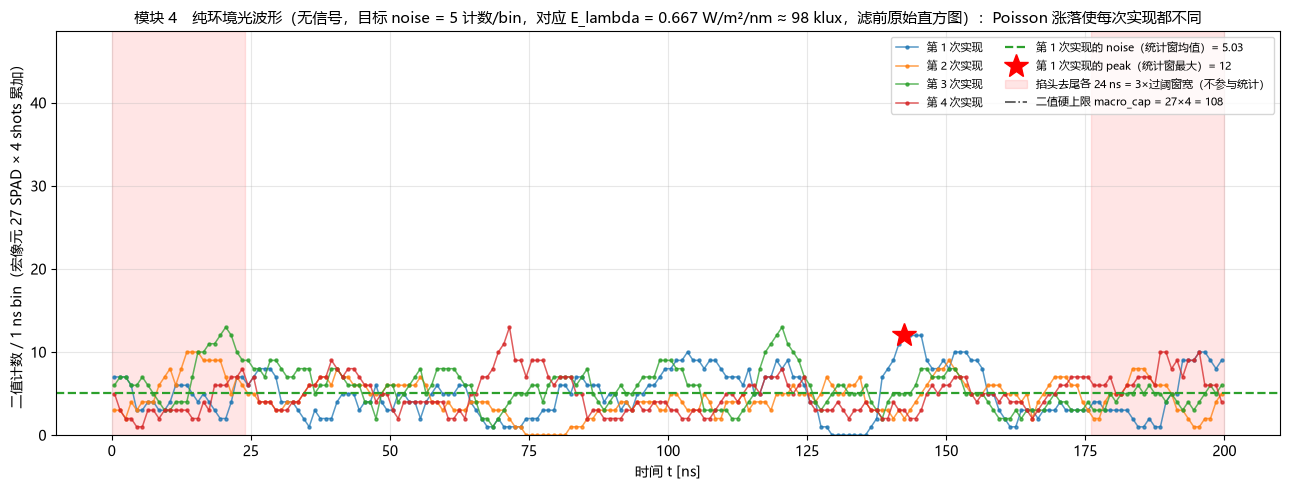

6 次实现的 (noise, peak)：
  实现 1: noise =  5.026 计数/bin,  peak =  12 计数 @ t = 142.5 ns
  实现 2: noise =  4.289 计数/bin,  peak =   9 计数 @ t = 150.5 ns
  实现 3: noise =  5.645 计数/bin,  peak =  13 计数 @ t = 120.5 ns
  实现 4: noise =  4.816 计数/bin,  peak =  13 计数 @ t = 71.5 ns
  实现 5: noise =  4.836 计数/bin,  peak =  10 计数 @ t = 75.5 ns
  实现 6: noise =  5.809 计数/bin,  peak =  13 计数 @ t = 125.5 ns


In [8]:
_DEMO_NOISE = 5.0
_r_demo = r_det_for_noise(_DEMO_NOISE, N_PIX_MACRO*4)
_demo = noise_macro_hist_fast(6, N_PIX_MACRO*4, _r_demo,
                              np.random.default_rng(PARAMS["hist"]["seed"] + 77))

fig, ax = plt.subplots(figsize=(13, 5))
for i in range(4):
    ax.plot(TC_NS, _demo[i], lw=1.1, marker="o", ms=2.2, alpha=0.75, label=f"第 {i+1} 次实现")
w0 = _demo[0, I_STAT0:I_STAT1]
ax.axhline(w0.mean(), color="tab:green", ls="--", lw=1.6,
           label=f"第 1 次实现的 noise（统计窗均值）= {w0.mean():.2f}")
ax.plot(TC_NS[I_STAT0 + int(w0.argmax())], w0.max(), "*", color="red", ms=18,
        label=f"第 1 次实现的 peak（统计窗最大）= {w0.max():.0f}")
ax.axvspan(0, TRIM_NS, color="red", alpha=0.10)
ax.axvspan(WIN_HI_NS-TRIM_NS, WIN_HI_NS, color="red", alpha=0.10,
           label=f"掐头去尾各 {TRIM_NS:.0f} ns = 3×过阈窗宽（不参与统计）")
ax.axhline(N_PIX_MACRO*4, color="k", ls="-.", lw=1.2, alpha=0.7,
           label=f"二值硬上限 macro_cap = 27×4 = {N_PIX_MACRO*4}")
ax.set_xlabel("时间 t [ns]")
ax.set_ylabel("二值计数 / 1 ns bin（宏像元 27 SPAD × 4 shots 累加）")
ax.set_title(f"模块 4　纯环境光波形（无信号，目标 noise = {_DEMO_NOISE:g} 计数/bin，"
             f"对应 E_lambda = {e_lambda_for_r_det(_r_demo):.3f} W/m²/nm ≈ "
             f"{e_lambda_for_r_det(_r_demo)/0.68*100:.0f} klux，滤前原始直方图）："
             f"Poisson 涨落使每次实现都不同", fontsize=10.5)
ax.legend(fontsize=8, loc="upper right", ncol=2)
ax.set_ylim(0, max(N_PIX_MACRO*4*0.45, _demo.max()*1.45))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("pod_v30_noise_waveform.png", dpi=110, bbox_inches="tight")
plt.show()

print(f"6 次实现的 (noise, peak)：")
for i in range(6):
    w = _demo[i, I_STAT0:I_STAT1]
    print(f"  实现 {i+1}: noise = {w.mean():6.3f} 计数/bin,  peak = {w.max():3.0f} 计数 "
          f"@ t = {TC_NS[I_STAT0+int(w.argmax())]:.1f} ns")

## 模块 5 — 纯噪声 bg 扫描（全项目唯一的大重算）

对统一 bg 网格（0.25 → 12，步长 0.25，共 48 档）逐档跑纯环境光 MC，
得到每档的 **peak 分布（bincount）**、**单条 hist 内 152 bin 的 std**，
并由 peak 分布反解各 FAR 目标下的**检测阈值 T**。

本模块的结果 `NOISE_RES` / `THRESH` 是模块 9 / 10 / 11 的**唯一数据源**，后面不再重算。

- **bg**：`hist_add`（累加 N 发后的直方图）在统计窗内每个 1 ns bin 的**平均计数**。全项目横轴统一用它。
- **noise**：单发 `hist_i` 每 bin 的平均计数，`noise = bg / N_shots`。**只用于描述单次直方图的底噪**，不再作为横轴。
- **peak**：一条 `hist_add` 在统计窗 152 个 bin 内的**最大计数**。
- **FAR**（False Alarm Rate，虚警率）：`P(peak ≥ T)`，即一个统计窗出一个噪点的概率。

> **阈值 T 为什么是整数**：`hist_add` 是 27×N 条二值（0/1）轨迹求和，取值只能是整数
> 0…27N，判定就是 `peak >= T`。所以 `T=10.25` 与 `T=11` 是同一个判定，
> 0.25 粒度的阈值在计数轴上不存在。曲线看着像阶梯，是因为 **bg 以 0.25 连续步进、而 T 只能按 1 计数跳**。

In [9]:
def _noise_chunk_stats(m, n_tr, r_det, inv_tab, seed):
    """单个纯噪声分块；返回可直接归并的充分统计量。"""
    h = noise_macro_hist_fast(
        m, n_tr, r_det, np.random.default_rng(seed), inv_tab=inv_tab,
    )
    a = h[:, I_STAT0:I_STAT1]
    nz = a.mean(axis=1)
    return (float(nz.sum()), float((nz*nz).sum()),
            np.bincount(a.max(axis=1), minlength=n_tr + 2),
            float(a.std(axis=1).sum()))   # ★ v30：hist 内 std


def peak_stats_from_cnt(cnt):
    """由 peak 的 bincount 精确算出均值/标准差/各分位数。"""
    v = np.arange(cnt.size, dtype=float)
    n = cnt.sum()
    mean = (v * cnt).sum() / n
    var = (v*v * cnt).sum() / n - mean**2
    cum = np.cumsum(cnt) / n
    q = lambda p: float(np.searchsorted(cum, p))
    return dict(n=int(n), mean=mean, std=np.sqrt(max(var, 0.0)),
                p01=q(0.01), p50=q(0.50), p99=q(0.99),
                p999=q(0.999), p9999=q(0.9999),
                pmax=float(np.nonzero(cnt)[0].max()) if np.any(cnt) else 0.0)


def _atomic_savez(path, **kwargs):
    """先写临时文件再替换，避免中断写出半截缓存。
    注意：np.savez_compressed 若路径不以 .npz 结尾会自动追加 .npz，
    因此临时文件必须自带 .npz 后缀，否则 os.replace 会找不到文件（WinError 2）。
    """
    path = str(path)
    tmp = path + ".tmp.npz"
    np.savez_compressed(tmp, **kwargs)
    os.replace(tmp, path)

def _try_load_noise_cache(path, grid_key):
    if not os.path.exists(path):
        return None
    z = np.load(path, allow_pickle=True)
    if (int(z["n_mc"]) == N_MC_NOISE and list(z["n_shots_list"]) == list(N_SHOTS_LIST)
            and z["grid_key"].shape == grid_key.shape
            and np.allclose(z["grid_key"], grid_key)):
        _r = z["res"].item()
        # ★ v30：没有 hist_std 字段的一律当作旧缓存丢弃
        if any("hist_std" not in _r.get(_n, {}) for _n in N_SHOTS_LIST):
            return None
        return _r
    return None


def _save_noise_cache(path, res, grid_key):
    _atomic_savez(path, res=np.array(res, dtype=object),
                  n_mc=N_MC_NOISE, n_shots_list=np.array(N_SHOTS_LIST),
                  grid_key=grid_key)


def run_noise_scan(n_shots, noise_grid, n_mc, chunk, seed0=2000, verbose_every=5,
                   res=None, start_k=0, on_progress=None):
    """对一组【目标 noise】跑纯噪声 MC；支持从 start_k 断点续跑。"""
    n_tr = N_PIX_MACRO * n_shots
    ng = len(noise_grid)
    if res is None:
        res = {"n_shots": n_shots, "n_tr": n_tr,
               "noise_target": np.asarray(noise_grid, float),
               "r_det": np.zeros(ng), "e_lambda": np.zeros(ng),
               "p_eq": np.zeros(ng), "noise_mc": np.zeros(ng), "noise_std": np.zeros(ng),
               "hist_std": np.zeros(ng),   # ★ v30
               "peak_cnt": np.zeros((ng, n_tr + 2), dtype=np.int64),
               "done": np.zeros(ng, dtype=bool)}
    elif "done" not in res:
        # 兼容旧缓存：peak_cnt 有样本即视为已完成
        res["done"] = np.array([int(c.sum()) > 0 for c in res["peak_cnt"]], dtype=bool)

    t_start = time.time()
    for k, nt in enumerate(noise_grid):
        if k < start_k or bool(res["done"][k]):
            continue
        r_det = r_det_for_noise(float(nt), n_tr)
        res["r_det"][k] = r_det
        res["e_lambda"][k] = e_lambda_for_r_det(r_det)
        res["p_eq"][k] = p_bin_equilibrium(r_det)[0]
        inv_tab = build_inv_table(r_det)
        s1 = s2 = s3 = 0.0
        res["peak_cnt"][k][:] = 0
        specs = [
            (min(chunk, n_mc - s), n_tr, r_det, inv_tab, seed0 + 1000*k + s)
            for s in range(0, n_mc, chunk)
        ]
        if NOISE_WORKERS <= 1:
            parts = [_noise_chunk_stats(*spec) for spec in specs]
        else:
            with ThreadPoolExecutor(max_workers=NOISE_WORKERS) as pool:
                parts = list(pool.map(lambda x: _noise_chunk_stats(*x), specs))
        for p1, p2, pcnt, p3 in parts:
            s1 += p1; s2 += p2; s3 += p3
            res["peak_cnt"][k] += pcnt
        res["noise_mc"][k] = s1 / n_mc
        res["noise_std"][k] = np.sqrt(max(s2/n_mc - (s1/n_mc)**2, 0.0))
        res["hist_std"][k] = s3 / n_mc
        res["done"][k] = True
        if on_progress is not None:
            on_progress(res, k)
        if k == 0 or k == ng-1 or (k+1) % verbose_every == 0:
            el = time.time() - t_start
            remain = max(int((~res["done"]).sum()), 0)
            done_n = int(res["done"].sum())
            eta = el / max(done_n - start_k, 1) * remain
            pk = peak_stats_from_cnt(res["peak_cnt"][k])
            print(f"  [N_shots={n_shots} {done_n:>3d}/{ng}] 目标 noise={nt:>6.2f} → "
                  f"实测 {res['noise_mc'][k]:>6.3f}（E_λ={res['e_lambda'][k]:.4f}，"
                  f"≈{res['e_lambda'][k]/0.68*100:>5.0f} klux）  "
                  f"peak 中位={pk['p50']:>5.1f} 99.99%={pk['p9999']:>5.1f}  "
                  f"[已用 {el:.0f}s, 剩约 {eta:.0f}s]")
    return res





def run_noise_scan_v20_bg(bg_grid, n_mc, chunk, seed0=2000, verbose_every=1,
                          res_all=None, on_progress=None):
    """★ v20：按统一 bg 网格扫；对每个 N 单独设 noise_amb=bg/N。

    返回 {N: res_dict}；res_dict 字段兼容旧作图（noise_mc=实测 bg，noise_target=目标 bg）。
    """
    grid = np.asarray(bg_grid, float)
    ng = len(grid)
    if res_all is None:
        res_all = {}
    for n in N_SHOTS_LIST:
        n_tr = N_PIX_MACRO * n
        if n not in res_all:
            res_all[n] = {
                "n_shots": n, "n_tr": n_tr,
                "noise_target": grid.copy(),                 # 目标 bg
                "noise_amb_target": np.round(grid / n, 6),  # 对应单次 noise
                "r_det": np.zeros(ng), "e_lambda": np.zeros(ng), "p_eq": np.zeros(ng),
                "noise_mc": np.zeros(ng), "noise_std": np.zeros(ng),  # = bg
                "noise_amb_mc": np.zeros(ng), "noise_amb_std": np.zeros(ng),
                "peak_cnt": np.zeros((ng, n_tr + 2), dtype=np.int64),
                "done": np.zeros(ng, dtype=bool),
            }
        elif "done" not in res_all[n]:
            res_all[n]["done"] = np.array(
                [int(c.sum()) > 0 for c in res_all[n]["peak_cnt"]], dtype=bool)

    t_start = time.time()
    jobs = [(n, k) for n in N_SHOTS_LIST for k in range(ng)
            if not bool(res_all[n]["done"][k])]
    n_jobs = len(jobs)
    print(f"v20 噪声扫描：{ng} bg × N={list(N_SHOTS_LIST)} = {ng*len(N_SHOTS_LIST)} 档，"
          f"待算 {n_jobs}，每档 {n_mc:,} MC", flush=True)
    for ji, (n, k) in enumerate(jobs):
        bg_t = float(grid[k])
        nt_amb = bg_t / n
        r_det = float(r_det_for_noise(float(nt_amb), N_PIX_MACRO))
        e_lam = float(e_lambda_for_r_det(r_det))
        p_eq = float(p_bin_equilibrium(r_det)[0])
        inv_tab = build_inv_table(r_det)

        acc = dict(noise_sum=0.0, noise_sumsq=0.0, bg_sum=0.0, bg_sumsq=0.0,
                   peak_cnt=np.zeros(N_PIX_MACRO * n + 2, dtype=np.int64), nn=0)
        done_m, part = 0, 0
        while done_m < n_mc:
            m = min(chunk, n_mc - done_m)
            seeds = [seed0 + 10007 * (n * 1000 + k) + 104729 * part + 17 * t
                     for t in range(NOISE_WORKERS)]
            ms = [m // NOISE_WORKERS + (1 if t < m % NOISE_WORKERS else 0)
                  for t in range(NOISE_WORKERS)]

            def _one(args, _n=n, _rd=r_det, _it=inv_tab):
                mm, sd = args
                if mm <= 0:
                    return None
                rng = np.random.default_rng(sd)
                hi = noise_hists_per_shot(mm, _n, _rd, rng, inv_tab=_it)
                return stats_from_hist_i(hi, n_shots_list=[_n])

            with ThreadPoolExecutor(max_workers=NOISE_WORKERS) as pool:
                parts = list(pool.map(_one, zip(ms, seeds)))
            for st in parts:
                if st is None:
                    continue
                b = st[n]
                acc["noise_sum"] += b["noise_sum"]; acc["noise_sumsq"] += b["noise_sumsq"]
                acc["bg_sum"] += b["bg_sum"]; acc["bg_sumsq"] += b["bg_sumsq"]
                acc["peak_cnt"] += b["peak_cnt"]; acc["nn"] += b["n"]
            done_m += m; part += 1

        R = res_all[n]; nn = max(acc["nn"], 1)
        R["r_det"][k] = r_det; R["e_lambda"][k] = e_lam; R["p_eq"][k] = p_eq
        R["noise_amb_mc"][k] = acc["noise_sum"] / nn
        R["noise_amb_std"][k] = float(np.sqrt(max(
            acc["noise_sumsq"]/nn - (acc["noise_sum"]/nn)**2, 0.0)))
        R["noise_mc"][k] = acc["bg_sum"] / nn
        R["noise_std"][k] = float(np.sqrt(max(
            acc["bg_sumsq"]/nn - (acc["bg_sum"]/nn)**2, 0.0)))
        R["peak_cnt"][k] = acc["peak_cnt"]
        R["done"][k] = True
        if on_progress is not None:
            on_progress(res_all, n, k)
        if (ji % verbose_every) == 0 or ji == n_jobs - 1:
            el = time.time() - t_start
            eta = el / (ji + 1) * (n_jobs - ji - 1)
            pk = peak_stats_from_cnt(R["peak_cnt"][k])
            print(f"  [{ji+1}/{n_jobs}] N={n} bg={bg_t:.2f}（amb={nt_amb:.3f}）→ "
                  f"bg_mc={R['noise_mc'][k]:.3f} peakμ={pk['mean']:.2f}  "
                  f"已用 {el/60:.1f} min，预计剩余 {eta/60:.1f} min", flush=True)
    return res_all


# 兼容旧名
run_noise_scan_v20_amb = run_noise_scan_v20_bg


# ---- 估算总耗时并开跑（主缓存 + fallback + 增量检查点）----

# ---- ★ v20：统一 BG_GRID，按 (N, bg) 扫（主缓存 + 检查点）----
_grid_key = np.asarray(BG_GRID, float)
NOISE_RES = None
_loaded_from = None
for _cand in [CACHE_NOISE, *CACHE_NOISE_FALLBACK, CACHE_NOISE_CKPT]:
    NOISE_RES = _try_load_noise_cache(_cand, _grid_key)
    if NOISE_RES is not None:
        _loaded_from = _cand
        break

def _noise_is_complete(res_all):
    for n in N_SHOTS_LIST:
        if n not in res_all:
            return False
        r = res_all[n]
        if "done" in r:
            if not np.all(r["done"]):
                return False
        else:
            if not all(int(c.sum()) > 0 for c in r["peak_cnt"]):
                return False
            r["done"] = np.ones(len(r["noise_target"]), dtype=bool)
        if len(r["noise_target"]) != len(BG_GRID):
            return False
        if not np.allclose(r["noise_target"], BG_GRID, atol=1e-6):
            return False
    return True


if NOISE_RES is not None and _noise_is_complete(NOISE_RES):
    print(f"已从缓存 {_loaded_from} 载入纯噪声 MC（每档 {N_MC_NOISE:,} 条，完整，v20 统一 bg）")
    if _loaded_from != CACHE_NOISE:
        _save_noise_cache(CACHE_NOISE, NOISE_RES, _grid_key)
        print(f"已同步写入主缓存 {CACHE_NOISE}")
else:
    import sys
    print("=" * 72)
    print("未找到完整 v20 噪声缓存 → 自动调用多进程扫描（ProcessPool，吃满 CPU）")
    print("下方实时打印子进程进度……")
    print("=" * 72)
    _rc = _run_cmd_stream([sys.executable, "build_pod_core_v20.py"])
    if _rc != 0:
        raise RuntimeError("build_pod_core_v20.py 失败，无法继续噪声扫描")
    _rc = _run_cmd_stream(
        [sys.executable, "run_pod_v30_noise_scan.py",
         "--workers", str(int(N_WORKERS))])
    if _rc != 0:
        raise RuntimeError("run_pod_v30_noise_scan.py 失败，请查看上方进度输出")
    NOISE_RES = _try_load_noise_cache(CACHE_NOISE, _grid_key)
    if NOISE_RES is None or not _noise_is_complete(NOISE_RES):
        raise RuntimeError(
            f"多进程扫描结束但仍无法载入完整缓存 {CACHE_NOISE}")
    print(f"多进程扫描完成，已载入 {CACHE_NOISE}")

已从缓存 pod_esti_v30_cache_noise.npz 载入纯噪声 MC（每档 1,000,000 条，完整，v20 统一 bg）


In [10]:
def far_threshold_from_cnt(cnt, target_far):
    """由 peak 的 bincount 求满足 P(peak ≥ T) < target_far 的最小整数 T。

    全程用【整数计数】比较（n_ge < target_far·n），避免浮点边界误判。
    返回 (T, 该 T 处实测 FAR, 该 T 处越阈次数, 生存函数数组)。
    """
    n = int(cnt.sum())
    n_ge = np.concatenate([[n], n - np.cumsum(cnt)[:-1]])
    lim = target_far * n
    ok = np.where(n_ge < lim)[0]
    sf = n_ge / n
    if ok.size == 0:
        return int(cnt.size), 0.0, 0, sf
    T = int(ok[0])
    return T, float(sf[T]), int(n_ge[T]), sf


def far_threshold_binom_indep(n_tr, p_bin, n_bins, target_far):
    """独立 Binomial 近似阈值（保守对照）。"""
    a_bin = 1.0 - (1.0 - target_far) ** (1.0 / n_bins)
    T = 0
    while T <= n_tr and _binom.sf(T - 1, n_tr, p_bin) > a_bin:
        T += 1
    return T


THRESH = {}
for n_shots in N_SHOTS_LIST:
    R = NOISE_RES[n_shots]
    ng = len(R["noise_target"])
    rec = {"noise": R["noise_mc"], "sigma_bin": np.zeros(ng)}
    for far in TARGET_FARS:
        tag = FAR_TAG[far]
        rec["T"+tag] = np.zeros(ng, dtype=int)
        rec["far"+tag] = np.zeros(ng)
        rec["nev"+tag] = np.zeros(ng, dtype=int)
        rec["Ti"+tag] = np.zeros(ng, dtype=int)
    for k in range(ng):
        rec["sigma_bin"][k] = np.sqrt(R["n_tr"] * R["p_eq"][k] * (1 - R["p_eq"][k]))
        for far in TARGET_FARS:
            tag = FAR_TAG[far]
            T, f_, nev, _ = far_threshold_from_cnt(R["peak_cnt"][k], far)
            rec["T"+tag][k] = T
            rec["far"+tag][k] = f_
            rec["nev"+tag][k] = nev
            rec["Ti"+tag][k] = far_threshold_binom_indep(
                R["n_tr"], R["p_eq"][k], N_STAT, far)
    THRESH[n_shots] = rec

print("="*140)
print(f"检测阈值汇总（每档 {N_MC_NOISE:,} 条 MC；FAR = { [FAR_LABEL[f] for f in TARGET_FARS] }）")
_hdr = f"{'N_shots':>8}{'noise':>8}"
for far in TARGET_FARS:
    _hdr += f"{'T@'+FAR_LABEL[far]:>10}"
_hdr += f"{'上限':>6}"
print(_hdr)
for n_shots in N_SHOTS_LIST:
    R, Tr = NOISE_RES[n_shots], THRESH[n_shots]
    step = max(1, len(Tr["noise"]) // 12)
    for k in range(0, len(Tr["noise"]), step):
        row = f"{n_shots:>8d}{Tr['noise'][k]:>8.3f}"
        for far in TARGET_FARS:
            row += f"{Tr['T'+FAR_TAG[far]][k]:>10d}"
        row += f"{R['n_tr']:>6d}"
        print(row)


def _quantile_from_cnt(cnt, p):
    """由 peak 的 bincount 求 p 分位（返回整数计数值）。"""
    tot = cnt.sum()
    if tot <= 0:
        return 0.0
    return float(np.searchsorted(np.cumsum(cnt) / tot, p))


print(f"模块 5 就绪：NOISE_RES / THRESH（{len(BG_GRID)} 档 bg × N={N_SHOTS_LIST}，"
      f"每档 {N_MC_NOISE:,} MC）。模块 9 / 10 / 11 直接复用，不再重算。")

检测阈值汇总（每档 1,000,000 条 MC；FAR = ['10 ppm', '100 ppm', '0.1%', '0.5%', '1%', '5%', '10%']）
 N_shots   noise  T@10 ppm T@100 ppm    T@0.1%    T@0.5%      T@1%      T@5%     T@10%    上限
       1   0.250         7         6         5         5         4         4         3    27
       1   1.251        11        10         9         8         8         7         6    27
       1   2.251        13        12        11        10        10         9         8    27
       1   3.250        15        14        13        12        12        11        10    27
       1   4.251        17        16        15        14        13        12        12    27
       1   5.252        19        18        16        15        15        14        13    27
       1   6.252        20        19        18        17        16        15        14    27
       1   7.252        21        20        19        18        17        16        16    27
       1   8.252        22        21        20        19        19        

In [11]:
# ==================== 模块 5 绘图参数 ====================
# 只影响画图，不影响任何计算；改完重跑本 cell 与下一个绘图 cell 即可。

M5_FARS        = [0.05, 0.01]   # 【叠加曲线】bg–peak 图上只叠这两条阈值（5% / 1%）
M5_XLIM        = (0.0, 12.25)   # 【上下两排横轴】bg 范围 [计数/bin]
M5_YLIM_PEAK   = None           # 【上排纵轴】peak 计数范围；None = 自动贴合数据
M5_SHOW_CAP    = False          # 【上排】是否画二值硬上限 n_tr。N=4 时上限 108 离数据很远，
                                #   画上去会把曲线压扁，所以默认关掉
M5_BAND_LO     = 0.01           # 【上排阴影带】下分位（0.01 = 1% 分位）
M5_BAND_HI     = 0.99           # 【上排阴影带】上分位
M5_STRIP_YLIM  = None           # 【下排纵轴】密度条带的 peak 范围；None = 自动按数据裁
M5_STRIP_QCUT  = 0.9999         # 【下排纵轴自动裁剪】保留到该分位，压掉长尾空白
M5_STRIP_VMAXQ = 0.98           # 【下排色标上限】取 pmf 的该分位，避免个别高峰吃掉全部色阶
M5_STRIP_CMAP  = "magma"        # 【下排配色】
M5_FIGSIZE     = (5.6 * len(N_SHOTS_LIST), 8.6)
M5_TABLE_STEP  = 6              # 【文字表】每隔几档 bg 打一行

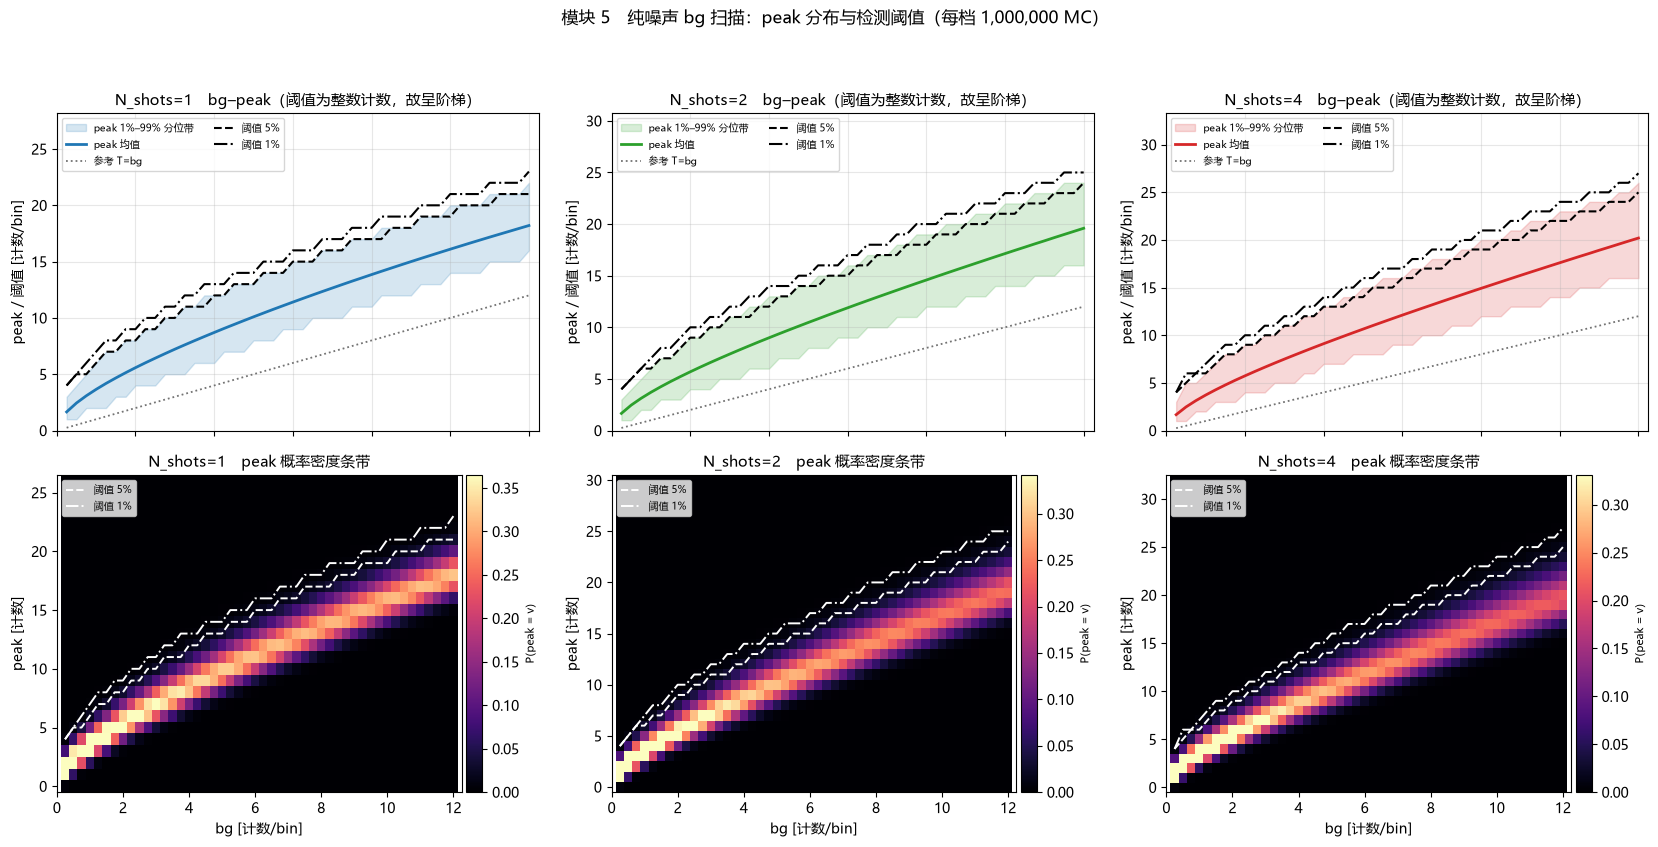

模块 5 抽样表：实测 bg / peak 均值 / 单条 hist 内 std / 1% 与 5% 阈值
    bg | N=1: bg实测 peakμ histσ  T5%  T1% | N=2: bg实测 peakμ histσ  T5%  T1% | N=4: bg实测 peakμ histσ  T5%  T1%
  0.25 |  0.250   1.65  0.468    4    4 |  0.250   1.66  0.468    4    4 |  0.250   1.67  0.469    4    4
  1.75 |  1.751   5.13  1.233    8    9 |  1.751   5.23  1.253    8    9 |  1.751   5.27  1.263    8    9
  3.25 |  3.250   7.60  1.634   11   12 |  3.251   7.81  1.687   11   12 |  3.251   7.91  1.712   11   12
  4.75 |  4.751   9.76  1.914   13   14 |  4.752  10.10  2.010   14   15 |  4.751  10.27  2.057   14   15
  6.25 |  6.252  11.72  2.124   15   16 |  6.252  12.24  2.273   16   17 |  6.252  12.47  2.343   16   18
  7.75 |  7.752  13.55  2.280   17   18 |  7.752  14.26  2.492   18   20 |  7.753  14.58  2.591   19   20
  9.25 |  9.252  15.28  2.394   19   20 |  9.252  16.19  2.680   20   22 |  9.253  16.61  2.811   21   23
 10.75 | 10.752  16.91  2.471   20   21 | 10.753  18.07  2.842   22   24 | 10.753  18.59  3.007

In [12]:
# ==================== 模块 5 绘图 ====================
# 只读 NOISE_RES / THRESH，不重算。
_bg = np.asarray(BG_GRID, float)
fig, axes = plt.subplots(2, len(N_SHOTS_LIST), figsize=M5_FIGSIZE, sharex=True)
axes = np.atleast_2d(axes)

for j, n in enumerate(N_SHOTS_LIST):
    R, Tr = NOISE_RES[n], THRESH[n]
    st = [peak_stats_from_cnt(c) for c in R["peak_cnt"]]
    pk_mean = np.array([s["mean"] for s in st])
    pk_lo = np.array([_quantile_from_cnt(c, M5_BAND_LO) for c in R["peak_cnt"]])
    pk_hi = np.array([_quantile_from_cnt(c, M5_BAND_HI) for c in R["peak_cnt"]])

    # ---- 上排：bg–peak 曲线 + 1%/5% 阈值 ----
    a = axes[0, j]
    a.fill_between(_bg, pk_lo, pk_hi, color=_COLORS_N[n], alpha=0.18,
                   label=f"peak {M5_BAND_LO:.0%}–{M5_BAND_HI:.0%} 分位带")
    a.plot(_bg, pk_mean, "-", color=_COLORS_N[n], lw=2.0, label="peak 均值")
    a.plot(_bg, _bg, ":", color="0.45", lw=1.3, label="参考 T=bg")
    for far, ls in zip(M5_FARS, ["--", "-."]):
        a.plot(_bg, Tr["T" + FAR_TAG[far]], ls, color="k", lw=1.5,
               label=f"阈值 {FAR_LABEL[far]}")
    if M5_SHOW_CAP:
        a.axhline(R["n_tr"], color="0.3", ls=(0, (1, 1)), lw=1.1,
                  label=f"二值硬上限 {R['n_tr']}")
    a.set_title(f"N_shots={n}　bg–peak（阈值为整数计数，故呈阶梯）", fontsize=10.5)
    a.set_ylabel("peak / 阈值 [计数/bin]")
    if M5_YLIM_PEAK is not None:
        a.set_ylim(*M5_YLIM_PEAK)
    else:   # 贴着数据自动定范围，别让远处的硬上限把曲线压扁
        a.set_ylim(0, max(pk_hi.max(), Tr["T" + FAR_TAG[M5_FARS[0]]].max()) * 1.28)
    a.set_xlim(*M5_XLIM)
    a.grid(alpha=0.3); a.legend(fontsize=7.2, ncol=2, loc="upper left")

    # ---- 下排：peak 密度条带 ----
    b = axes[1, j]
    pmf = np.array([c / max(c.sum(), 1) for c in R["peak_cnt"]])      # [bg, peak]
    if M5_STRIP_YLIM is not None:
        v_hi = int(M5_STRIP_YLIM[1])
    else:
        v_hi = int(max(_quantile_from_cnt(c, M5_STRIP_QCUT)
                       for c in R["peak_cnt"])) + 2
    v_hi = min(v_hi, pmf.shape[1] - 1)
    sub = pmf[:, :v_hi + 1]
    vmax = np.quantile(sub[sub > 0], M5_STRIP_VMAXQ) if np.any(sub > 0) else 1.0
    mesh = b.pcolormesh(_bg, np.arange(v_hi + 1), sub.T, cmap=M5_STRIP_CMAP,
                        vmin=0.0, vmax=vmax, shading="nearest")
    fig.colorbar(mesh, ax=b, pad=0.01).set_label("P(peak = v)", fontsize=8)
    for far, ls in zip(M5_FARS, ["--", "-."]):
        b.plot(_bg, Tr["T" + FAR_TAG[far]], ls, color="w", lw=1.4,
               label=f"阈值 {FAR_LABEL[far]}")
    b.set_title(f"N_shots={n}　peak 概率密度条带", fontsize=10.5)
    b.set_xlabel("bg [计数/bin]"); b.set_ylabel("peak [计数]")
    if M5_STRIP_YLIM is not None:
        b.set_ylim(*M5_STRIP_YLIM)
    b.set_xlim(*M5_XLIM)
    b.legend(fontsize=7.2, loc="upper left")

fig.suptitle(f"模块 5　纯噪声 bg 扫描：peak 分布与检测阈值（每档 {N_MC_NOISE:,} MC）",
             fontsize=12.5)
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig("pod_v30_m5_bg_peak.png", dpi=120, bbox_inches="tight")
plt.show()

print("=" * 108)
print("模块 5 抽样表：实测 bg / peak 均值 / 单条 hist 内 std / 1% 与 5% 阈值")
_hdr = f"{'bg':>6}"
for n in N_SHOTS_LIST:
    _hdr += f" | N={n}: bg实测 peakμ histσ  T5%  T1%"
print(_hdr)
for k in range(0, len(_bg), M5_TABLE_STEP):
    row = f"{_bg[k]:6.2f}"
    for n in N_SHOTS_LIST:
        R, Tr = NOISE_RES[n], THRESH[n]
        pm = peak_stats_from_cnt(R["peak_cnt"][k])["mean"]
        row += (f" | {R['noise_mc'][k]:6.3f} {pm:6.2f} {R['hist_std'][k]:6.3f}"
                f" {Tr['T5pct'][k]:4d} {Tr['T1pct'][k]:4d}")
    print(row)

## 模块 6 — PoD 临界能量（逐 bg 档求 50% / 90% 交点）

对每个 bg 档、每个 `N_shots`，扫描回波能量倍率 `boost`，用模块 5 的阈值 `T` 判定，
求 **PoD**（Probability of Detection，探测概率）达到 50% / 90% 的临界能量。

只对 `POD_FARS` 这几条 FAR 求临界能量（0.5% / 1% / 5% / 10%）；
更严的 ppm 档阈值仍然算，只是不在这里解 PoD 交点（省一大半机时）。

In [13]:
# ---- PoD 专用子窗（只计算信号附近，前方保留暖机）----
POD_T_LO = T0_SIG - POD_WARM_NS * 1e-9
POD_T_HI = T0_SIG + SIG_POST_NS * 1e-9
TF_POD = np.arange(POD_T_LO, POD_T_HI, DT_FINE)
_sigmask = (TC_NS >= T0_SIG_NS - SIG_PRE_NS) & (TC_NS <= T0_SIG_NS + SIG_POST_NS)
IDX_SIG = np.where(_sigmask)[0]
CENTERS_SIG = CENTERS[IDX_SIG]
R_SIG_UNIT_POD = signal_photon_rate_fine(ECHO0, 1.0, TF_POD)
_NPH_BASE = np.trapezoid(R_SIG_UNIT_POD, TF_POD) * F_VALS.sum()

print(f"PoD 子窗：{POD_T_LO*1e9:.1f}–{POD_T_HI*1e9:.1f} ns，{TF_POD.size} 个细网格步")
print(f"每种 N_shots 对统一 BG_GRID 求解："
      f"{[len(NOISE_GRID[n]) for n in N_SHOTS_LIST]} 档，bg 步长 0.25；noise_amb=bg/N")
print(f"并行：外层 POD_BIN_WORKERS={POD_BIN_WORKERS} × 内层 POD_WORKERS={POD_WORKERS}；"
      f"MC 分块 POD_MC_CHUNK={POD_MC_CHUNK}；临界验证 {N_MC_POD_VERIFY:,} 次/点")


def _peaks_chunk(boost, n_shots, r_amb, n_real, seed):
    """★ v20：按当前 N 仿 n_shots 发（r_amb 已对应 noise=bg/N）。"""
    rng = np.random.default_rng(seed)
    hist_i = binary_macro_stepping_per_shot(
        n_real, F_VALS, n_shots, R_SIG_UNIT_POD, TF_POD, r_amb, CENTERS_SIG,
        rng, boost=boost,
    )
    return hist_i.sum(axis=1).max(axis=1)


def sig_peaks(boost, n_shots, r_amb, n_real, seed):
    """兼容入口：大 n_real 时按 POD_MC_CHUNK 切开，用 POD_WORKERS 并行。"""
    n_real = int(n_real)
    if n_real <= POD_MC_CHUNK or POD_WORKERS <= 1:
        return _peaks_chunk(boost, n_shots, r_amb, n_real, seed)
    specs = []
    for s in range(0, n_real, POD_MC_CHUNK):
        m = min(POD_MC_CHUNK, n_real - s)
        specs.append((boost, n_shots, r_amb, m, seed + 104729 * s))
    with ThreadPoolExecutor(max_workers=POD_WORKERS) as pool:
        parts = list(pool.map(lambda sp: _peaks_chunk(*sp), specs))
    return np.concatenate(parts)


def _eval_mc_jobs(job_specs, n_shots, r_amb):
    """统一并行入口。
    job_specs: [(boost, n_real, seed), ...] → 与输入等长的 peak 数组列表。
    每个 job 再按 POD_MC_CHUNK 切开，全部丢进同一个线程池，避免嵌套池。
    """
    flat, owners = [], []
    for j, (boost, n_real, seed) in enumerate(job_specs):
        n_real = int(n_real)
        if n_real <= 0:
            continue
        for s in range(0, n_real, POD_MC_CHUNK):
            m = min(POD_MC_CHUNK, n_real - s)
            flat.append((float(boost), n_shots, r_amb, m, int(seed) + 104729 * s))
            owners.append(j)
    out = [None] * len(job_specs)
    if not flat:
        return [np.zeros(0, dtype=int) for _ in job_specs]
    if POD_WORKERS <= 1:
        parts = [_peaks_chunk(*sp) for sp in flat]
    else:
        with ThreadPoolExecutor(max_workers=POD_WORKERS) as pool:
            parts = list(pool.map(lambda sp: _peaks_chunk(*sp), flat))
    buckets = [[] for _ in job_specs]
    for own, pk in zip(owners, parts):
        buckets[own].append(pk)
    for j, segs in enumerate(buckets):
        out[j] = np.concatenate(segs) if segs else np.zeros(0, dtype=int)
    return out


def _eval_boost_grid(boosts, n_shots, r_amb, n_real, seed0):
    """并行评估若干独立能量点；返回每点的 peak 样本。"""
    boosts = np.asarray(boosts, float)
    jobs = [(float(b), n_real, seed0 + 1009 * i) for i, b in enumerate(boosts)]
    return _eval_mc_jobs(jobs, n_shots, r_amb)


def _isotonic(p):
    """简单保序：消除有限 MC 导致的局部 PoD 下降。"""
    return np.maximum.accumulate(np.asarray(p, float))


def _crossing_logboost(boosts, pod, level):
    """在 log10(boost) 上找首次跨越；越界返回 NaN。"""
    order = np.argsort(boosts)
    x = np.log10(np.asarray(boosts)[order])
    p = _isotonic(np.asarray(pod)[order])
    if p[0] >= level:
        return float(x[0])
    if p[-1] < level:
        return np.nan
    i = int(np.searchsorted(p, level))
    dp = p[i] - p[i - 1]
    w = 0.5 if dp <= 0 else (level - p[i - 1]) / dp
    return float(x[i - 1] + w * (x[i] - x[i - 1]))


def _probit_fit(boosts, pod, n_real):
    """拟合 Phi^-1(PoD) = slope*log10(boost) + intercept。"""
    boosts = np.asarray(boosts, float)
    success = np.rint(np.asarray(pod, float) * n_real)
    p = (success + 0.5) / (n_real + 1.0)
    transition = (p > 0.01) & (p < 0.99)
    if transition.sum() < 3:
        transition = np.argsort(np.abs(p - 0.5))[:min(5, len(p))]
    x = np.log10(boosts[transition])
    z = _norm.ppf(p[transition])
    slope, intercept = np.polyfit(x, z, 1)
    return float(slope), float(intercept)


def _pk_to_record(boost, pk, T, n_shots):
    return {
        "boost": float(boost),
        "pod": float((pk >= T).mean()),
        "peak_mean": float(pk.mean()),
        "peak_std": float(pk.std()),
        "peak_cnt": np.bincount(pk, minlength=N_PIX_MACRO * n_shots + 1),
        "n_verify": int(pk.size),
    }


def _probit_fit_local(boosts, pod, n_real, level, half_decade=0.6):
    """只用经验交点附近的点做 probit 拟合。

    ★ v30 修复：全域拟合会被 4 个数量级上的饱和点（PoD≈0 与 PoD≈1）拽偏，
    5% FAR 档的初值经常偏半个数量级以上。
    """
    x0 = _crossing_logboost(boosts, pod, level)
    if not np.isfinite(x0):
        return _probit_fit(boosts, pod, n_real)
    x = np.log10(np.asarray(boosts, float))
    sel = np.abs(x - x0) <= half_decade
    if sel.sum() >= 3:
        return _probit_fit(np.asarray(boosts, float)[sel],
                           np.asarray(pod, float)[sel], n_real)
    return _probit_fit(boosts, pod, n_real)


def _next_root_guess(hist, level, slope, max_step=0.5):
    """由已验证的 (log10 boost, PoD) 历史给出下一个试探点。

    有括号（一点低于目标、一点高于目标）就在 probit 空间做割线，
    割线跑出括号则退回二分；没有括号就用拟合斜率做 Newton 步并主动向外扩。
    """
    n = float(N_MC_POD_VERIFY)
    _clip = lambda p: min(max(p, 0.5 / n), 1.0 - 0.5 / n)
    below = [h for h in hist if h[1] < level]
    above = [h for h in hist if h[1] > level]
    if below and above:
        lo = max(below, key=lambda h: h[0])
        hi = min(above, key=lambda h: h[0])
        if hi[0] > lo[0]:
            zl, zh, zt = _norm.ppf(_clip(lo[1])), _norm.ppf(_clip(hi[1])), _norm.ppf(level)
            x = (lo[0] + (zt - zl) / (zh - zl) * (hi[0] - lo[0])
                 if zh > zl else 0.5 * (lo[0] + hi[0]))
            if not (lo[0] < x < hi[0]):
                x = 0.5 * (lo[0] + hi[0])
            return float(x)
    x0, p0 = hist[-1][0], hist[-1][1]
    s = slope if (slope and slope > 0) else 2.0
    dx = float(np.clip((_norm.ppf(level) - _norm.ppf(_clip(p0))) / s, -max_step, max_step))
    if dx == 0.0:
        dx = max_step if p0 < level else -max_step
    return float(x0 + dx)


def _verify_critical_batch(cands, n_shots, r_amb, seed0):
    """多轮批量迭代求根，把每个 (FAR, PoD 等级) 临界点解到验证 PoD 落进容差。

    ★ v30 修复：v20 只做一次 Newton 步、步长夹在 ±0.25 decade，初值偏 0.5 decade
    以上时根本追不回来，却仍然无条件接受结果。表现是模块 7 的临界能量曲线出现
    3–5 倍的毛刺，验证 PoD 实测 0.68 或 1.000 而不是 0.90。
    现在每轮把所有活跃候选一起并行评估（保持吞吐），最多 POD_VERIFY_ROUNDS 轮，
    最终取历史上最接近目标的那个点，并把 pod_err 一并存进记录备查。
    """
    if not cands:
        return {}
    state = [{"c": c, "i": i, "x": float(np.log10(c["boost"])), "hist": [], "done": False}
             for i, c in enumerate(cands)]

    for rnd in range(POD_VERIFY_ROUNDS):
        act = [s for s in state if not s["done"]]
        if not act:
            break
        pks = _eval_mc_jobs(
            [(float(10.0 ** s["x"]), N_MC_POD_VERIFY,
              seed0 + 7919 * s["i"] + 1_000_003 * rnd) for s in act],
            n_shots, r_amb,
        )
        for s, pk in zip(act, pks):
            c = s["c"]
            rec = _pk_to_record(10.0 ** s["x"], pk, c["T"], n_shots)
            s["hist"].append((s["x"], rec["pod"], rec))
            if abs(rec["pod"] - c["level"]) <= POD_VERIFY_TOL:
                s["done"] = True
                continue
            nx = _next_root_guess(s["hist"], c["level"], c["slope"])
            if not np.isfinite(nx):
                s["done"] = True
            else:
                s["x"] = nx

    finals = {}
    for s in state:
        c = s["c"]
        best = min(s["hist"], key=lambda h: abs(h[1] - c["level"]))
        rec = dict(best[2])
        rec["verify_rounds"] = len(s["hist"])
        rec["pod_err"] = float(best[1] - c["level"])
        finals[(c["tag"], f"{c['level']:.2f}")] = rec
    return finals


def solve_pod_noise(n_shots, k, seed0):
    """求一个 noise 档、全部 FAR 阈值下的 PoD50/90 临界点。"""
    R, Tr = NOISE_RES[n_shots], THRESH[n_shots]
    nt = float(R["noise_target"][k])
    n_tr = int(R["n_tr"])
    r_amb = float(R["r_det"][k] / PDE)
    # ★ v30：只对 POD_FARS 求 PoD 交点（阈值本身七条都在 THRESH 里）
    T_map = {FAR_TAG[far]: int(Tr["T" + FAR_TAG[far]][k]) for far in POD_FARS}
    if max(T_map.values()) > n_tr:
        return (n_shots, nt), {
            "noise": float(R["noise_mc"][k]), "e_lambda": float(R["e_lambda"][k]),
            "n_tr": n_tr, "T_map": T_map, "critical": {}, "invalid": "阈值超过二值硬上限",
        }

    coarse_boost = np.logspace(POD_LOG_BOOST_MIN, POD_LOG_BOOST_MAX, N_POD_COARSE)
    coarse_pk = _eval_boost_grid(
        coarse_boost, n_shots, r_amb, N_MC_POD_COARSE, seed0,
    )
    coarse_pod = {
        tag: np.array([(pk >= T).mean() for pk in coarse_pk])
        for tag, T in T_map.items()
    }

    roots0 = []
    for tag in T_map:
        for level in POD_LEVELS:
            x0 = _crossing_logboost(coarse_boost, coarse_pod[tag], level)
            if np.isfinite(x0):
                roots0.append(x0)
    if roots0:
        local_x = np.unique(np.concatenate([
            np.linspace(x0 - POD_LOCAL_HALF_DECADE, x0 + POD_LOCAL_HALF_DECADE,
                        N_POD_LOCAL_PER_ROOT)
            for x0 in roots0
        ]))
        local_boost = 10.0 ** local_x
        local_pk = _eval_boost_grid(
            local_boost, n_shots, r_amb, N_MC_POD_LOCAL, seed0 + 500_000,
        )
    else:
        local_boost = np.array([], float)
        local_pk = []

    critical = {tag: {} for tag in T_map}
    curve = {}
    cands = []
    for tag, T in T_map.items():
        boosts_fit = np.concatenate([coarse_boost, local_boost])
        pod_fit = np.concatenate([
            coarse_pod[tag],
            np.array([(pk >= T).mean() for pk in local_pk]) if len(local_pk) else np.array([], float),
        ])
        order = np.argsort(boosts_fit)
        boosts_fit, pod_fit = boosts_fit[order], pod_fit[order]
        curve[tag] = {"boost": boosts_fit, "pod": pod_fit}
        for level in POD_LEVELS:
            # ★ v30：逐 level 做局部 probit 拟合，别让远处的饱和点拽偏初值
            slope, intercept = _probit_fit_local(
                boosts_fit, pod_fit, N_MC_POD_LOCAL, level)
            x_root = (_norm.ppf(level) - intercept) / slope if slope > 0 else np.nan
            x_emp = _crossing_logboost(boosts_fit, pod_fit, level)
            if np.isfinite(x_emp) and (not np.isfinite(x_root)
                                       or abs(x_root - x_emp) > 0.5):
                x_root = x_emp   # 拟合外推得离谱时，经验交点更可信
            if not np.isfinite(x_root):
                critical[tag][f"{level:.2f}"] = None
                continue
            cands.append({
                "tag": tag, "level": level, "T": T, "slope": slope,
                "boost": float(10.0 ** x_root),
            })

    verified = _verify_critical_batch(cands, n_shots, r_amb, seed0 + 700_000)
    for (tag, lk), rec in verified.items():
        critical[tag][lk] = rec
    for tag in T_map:
        for level in POD_LEVELS:
            critical[tag].setdefault(f"{level:.2f}", None)

    return (n_shots, nt), {
        "noise": float(R["noise_mc"][k]),
        "noise_target": nt,
        "e_lambda": float(R["e_lambda"][k]),
        "n_tr": n_tr,
        "T_map": T_map,
        "curve": curve,
        "critical": critical,
    }


# ---- 对完整 0.25-bg 网格求解；主缓存 + fallback + 增量检查点 ----
_pod_grid_key = np.concatenate([NOISE_GRID[n] for n in N_SHOTS_LIST])


def _try_load_pod_cache(path, grid_key):
    """仅当噪声网格、MC 精度与 FAR 标签集合全部一致时才接受缓存。"""
    if not os.path.exists(path):
        return None
    z = np.load(path, allow_pickle=True)
    if "far_tags" not in z.files:
        return None  # 旧缓存无 FAR 标签 → 一律作废
    if (
        np.array_equal(z["grid_key"], grid_key)
        and list(z["far_tags"]) == list(FAR_TAGS)
        and int(z["n_coarse"]) == N_MC_POD_COARSE
        and int(z["n_local"]) == N_MC_POD_LOCAL
        and int(z["n_verify"]) == N_MC_POD_VERIFY
    ):
        return z["res"].item()
    return None


def _save_pod_cache(path, res, grid_key):
    _atomic_savez(
        path, res=np.array(res, dtype=object),
        grid_key=grid_key,
        far_tags=np.array(FAR_TAGS),
        n_coarse=N_MC_POD_COARSE, n_local=N_MC_POD_LOCAL,
        n_verify=N_MC_POD_VERIFY,
    )


POD_RES = None
_loaded_pod_from = None
for _cand in [CACHE_POD, *CACHE_POD_FALLBACK, CACHE_POD_CKPT]:
    POD_RES = _try_load_pod_cache(_cand, _pod_grid_key)
    if POD_RES is not None:
        _loaded_pod_from = _cand
        break

_expected_keys = {(ns, float(nt)) for ns in N_SHOTS_LIST for nt in NOISE_GRID[ns]}
_have_keys = set(POD_RES.keys()) if POD_RES else set()

def _pod_entry_has_all_fars(ent):
    crit = ent.get("critical", {})
    return all(tag in crit for tag in FAR_TAGS)

_complete = (
    POD_RES is not None
    and _expected_keys.issubset(_have_keys)
    and all(_pod_entry_has_all_fars(POD_RES[k]) for k in _expected_keys)
)

if _complete:
    print(f"已从缓存 {_loaded_pod_from} 载入逐 noise PoD 临界点（完整 "
          f"{len(_have_keys)} 档）")
    if _loaded_pod_from != CACHE_POD:
        _save_pod_cache(CACHE_POD, POD_RES, _pod_grid_key)
        print(f"已同步写入主缓存 {CACHE_POD}")
else:
    # ★ v20：缺 PoD 缓存时自动多进程扫描（Run All 可连续跑完）
    import sys
    print("=" * 72)
    print("未找到完整 PoD 缓存 → 自动调用多进程扫描（ProcessPool，吃满 CPU）")
    print("下方实时打印子进程进度……")
    print("=" * 72)
    _rc = _run_cmd_stream(
        [sys.executable, "run_pod_v30_pod_scan.py", "--workers", str(int(N_WORKERS))])
    if _rc != 0:
        raise RuntimeError("run_pod_v30_pod_scan.py 失败，请查看上方进度输出")
    POD_RES = _try_load_pod_cache(CACHE_POD, _pod_grid_key)
    _have_keys = set(POD_RES.keys()) if POD_RES else set()
    if POD_RES is None or _have_keys != _expected_keys:
        raise RuntimeError(
            f"多进程 PoD 扫描结束但仍无法载入完整缓存 {CACHE_POD} "
            f"(有 {len(_have_keys)}/{len(_expected_keys)} 档)")
    print(f"多进程 PoD 扫描完成，已载入 {CACHE_POD}（{len(_have_keys)} 档）")

PoD 子窗：40.1–112.1 ns，361 个细网格步
每种 N_shots 对统一 BG_GRID 求解：[48, 48, 48] 档，bg 步长 0.25；noise_amb=bg/N
并行：外层 POD_BIN_WORKERS=20 × 内层 POD_WORKERS=1；MC 分块 POD_MC_CHUNK=250；临界验证 5,000 次/点
未找到完整 PoD 缓存 → 自动调用多进程扫描（ProcessPool，吃满 CPU）
下方实时打印子进程进度……
[run] c:\ProgramData\miniconda3\python.exe run_pod_v30_pod_scan.py --workers 20
从 pod_esti_v30_cache_pod.npz 载入 144 档，断点续跑
全部 144 档均已完成
多进程 PoD 扫描完成，已载入 pod_esti_v30_cache_pod.npz（144 档）


In [14]:
# ==================== 模块 6 绘图参数 ====================
M6_SHOW_N      = 4               # 【画哪个 N_shots】的 PoD 曲线
M6_SHOW_BG     = [1.0, 6.0, 12.0]  # 【画哪几个 bg 档】
M6_FAR         = 0.01            # 【用哪条 FAR 的阈值】判定
M6_POD_XPAD    = 0.30            # 【上排横轴】交点两侧各留多少 decade（放大交点区）
M6_POD_YLIM    = (-0.02, 1.04)   # 【上排纵轴】PoD 范围
M6_DIST_STYLE  = "fill"          # 【下排画法】"fill"=实心直方图 / "line"=折线
M6_DIST_QLO    = 0.0005          # 【下排横轴】左端取分布的这个分位
M6_DIST_QHI    = 0.9995          # 【下排横轴】右端取分布的这个分位（保证右尾不被切掉）
M6_FIGSIZE     = (5.4 * 3, 8.0)

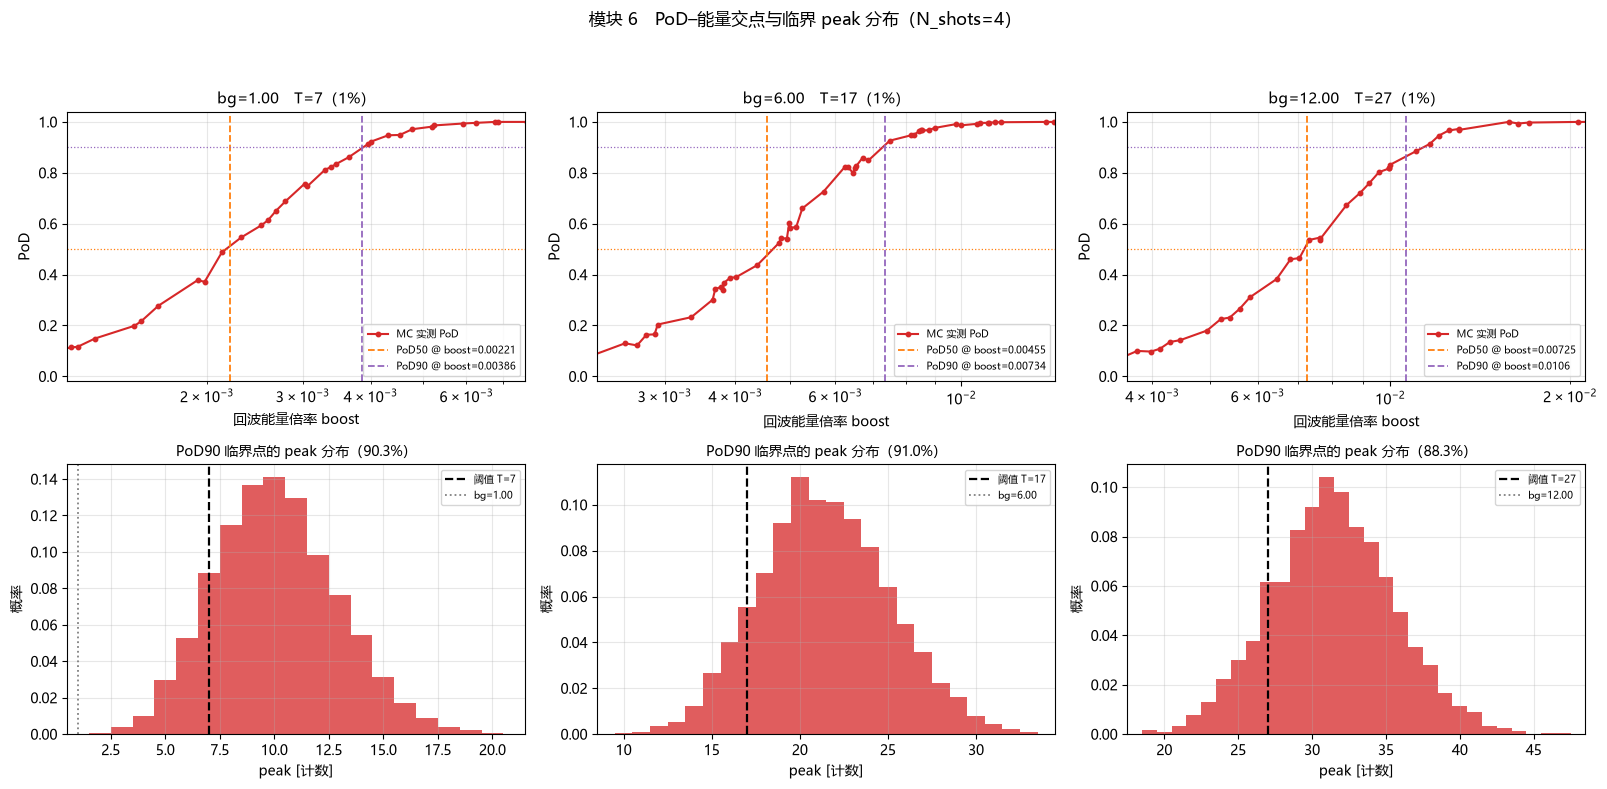

In [15]:
# ==================== 模块 6 绘图 ====================
_tag6 = FAR_TAG[M6_FAR]
_ks6 = [int(np.argmin(np.abs(np.asarray(BG_GRID, float) - b))) for b in M6_SHOW_BG]
fig, axes = plt.subplots(2, len(_ks6), figsize=M6_FIGSIZE)
axes = np.atleast_2d(axes)

for j, k in enumerate(_ks6):
    key = (M6_SHOW_N, float(NOISE_GRID[M6_SHOW_N][k]))
    r = POD_RES.get(key)
    a_pod, a_dist = axes[0, j], axes[1, j]
    if not r or _tag6 not in r.get("curve", {}):
        a_pod.text(0.5, 0.5, "该档无 PoD 结果", ha="center", va="center")
        continue
    cur = r["curve"][_tag6]
    T = int(r["T_map"][_tag6])
    bgv = float(r["noise"])

    # ---- 上排：PoD–能量曲线，横轴放大到交点附近 ----
    a_pod.semilogx(cur["boost"], cur["pod"], "o-", color=_COLORS_N[M6_SHOW_N],
                   ms=3.2, lw=1.5, label="MC 实测 PoD")
    xr = []
    for lv, c in zip(POD_LEVELS, ["tab:orange", "tab:purple"]):
        rec = r["critical"].get(_tag6, {}).get(f"{lv:.2f}")
        if rec:
            a_pod.axvline(rec["boost"], color=c, ls="--", lw=1.3,
                          label=f"PoD{int(lv*100)} @ boost={rec['boost']:.3g}")
            a_pod.axhline(lv, color=c, ls=":", lw=0.9)
            xr.append(rec["boost"])
    if xr:  # 只画交点前后 M6_POD_XPAD 个 decade，掐掉两头没用的平台
        a_pod.set_xlim(10 ** (np.log10(min(xr)) - M6_POD_XPAD),
                       10 ** (np.log10(max(xr)) + M6_POD_XPAD))
    a_pod.set_ylim(*M6_POD_YLIM)
    a_pod.set_title(f"bg={bgv:.2f}　T={T}（{FAR_LABEL[M6_FAR]}）", fontsize=10.5)
    a_pod.set_xlabel("回波能量倍率 boost"); a_pod.set_ylabel("PoD")
    a_pod.grid(alpha=0.3, which="both"); a_pod.legend(fontsize=7.4)

    # ---- 下排：临界点上的 peak 分布（实心/折线，不再用空心直方图）----
    rec90 = r["critical"].get(_tag6, {}).get("0.90")
    if rec90 and rec90.get("peak_cnt") is not None:
        cnt = np.asarray(rec90["peak_cnt"], float)
        pmf = cnt / max(cnt.sum(), 1.0)
        x = np.arange(pmf.size)
        m = pmf > 0
        if M6_DIST_STYLE == "line":
            a_dist.plot(x[m], pmf[m], "-", color=_COLORS_N[M6_SHOW_N], lw=1.8)
        else:
            a_dist.bar(x[m], pmf[m], width=1.0, color=_COLORS_N[M6_SHOW_N],
                       alpha=0.75, edgecolor="none")
        a_dist.axvline(T, color="k", ls="--", lw=1.6, label=f"阈值 T={T}")
        a_dist.axvline(bgv, color="0.5", ls=":", lw=1.3, label=f"bg={bgv:.2f}")
        # 横轴按分布自身的分位取，并保证阈值 T 一定在视野里（固定 ±N 计数会切掉右尾）
        cum = np.cumsum(pmf)
        lo = float(np.searchsorted(cum, M6_DIST_QLO))
        hi = float(np.searchsorted(cum, M6_DIST_QHI))
        a_dist.set_xlim(min(lo, T) - 1.5, max(hi, T) + 1.5)
        a_dist.set_title(f"PoD90 临界点的 peak 分布（{rec90['pod']:.1%}）", fontsize=10)
        a_dist.set_xlabel("peak [计数]"); a_dist.set_ylabel("概率")
        a_dist.grid(alpha=0.3); a_dist.legend(fontsize=7.4)

fig.suptitle(f"模块 6　PoD–能量交点与临界 peak 分布（N_shots={M6_SHOW_N}）", fontsize=12.5)
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig("pod_v30_m6_pod_critical.png", dpi=120, bbox_inches="tight")
plt.show()

## 模块 7 — 全 bg 档汇总：临界 peak、临界能量与等效测距

把模块 6 的临界点按 bg 排开，给出 **PoD50 / PoD90** 下的临界 peak、临界发射能量，
以及在平方反比下等效到多远（`equiv_distance`）。按用户要求只画 **1% 与 5%** 两条 FAR。

In [16]:
# ==================== 模块 7 计算（只做换算，不跑 MC）====================
def equiv_distance(boost, D_ref=D_TARGET, p=PARAMS):
    """把 boost 折算成发射能量和反射率不变时的等效距离。"""
    if not np.isfinite(boost) or boost <= 0:
        return np.nan
    alpha = p["channel"]["alpha"]
    Ds = np.logspace(np.log10(0.3), np.log10(5000.0), 6000)
    vals = (D_ref**2 / Ds**2) * np.exp(-2*alpha*(Ds-D_ref))
    if boost > vals[0] or boost < vals[-1]:
        return np.nan
    return float(np.interp(-boost, -vals, Ds))


def _collect_critical(n_shots, far_tag, level):
    """把 POD_RES 里某 (N, FAR, PoD水平) 的临界点按 bg 升序排成表。

    列：0=bg  1=实测PoD  2=peak均值  3=临界能量[nJ]  4=等效距离[m]  5=阈值T  6=boost
    """
    rows = []
    for nt in NOISE_GRID[n_shots]:
        r = POD_RES.get((n_shots, float(nt)))
        if not r or "critical" not in r:
            continue
        rec = r["critical"].get(far_tag, {}).get(f"{level:.2f}")
        if not rec:
            continue
        b = float(rec["boost"])
        rows.append((float(r["noise"]), float(rec["pod"]), float(rec["peak_mean"]),
                     b * E_PULSE_BASE * 1e9, equiv_distance(b),
                     float(r["T_map"][far_tag]), b))
    a = np.asarray(rows, float)
    return a[np.argsort(a[:, 0])] if a.size else a


print(f"模块 7 就绪：POD_RES 共 {len(POD_RES)} 个 (N, bg) 档；"
      f"临界能量只解 FAR={[FAR_LABEL[f] for f in POD_FARS]}")

模块 7 就绪：POD_RES 共 144 个 (N, bg) 档；临界能量只解 FAR=['0.5%', '1%', '5%', '10%']


In [17]:
# ==================== 模块 7 绘图参数 ====================
M7_FARS    = [0.05, 0.01]     # 【画哪几条 FAR】只画 5% 与 1%
M7_LEVELS  = [0.50, 0.90]     # 【画哪几个 PoD 水平】
M7_XLIM    = (0.0, 12.25)     # 【横轴】bg 范围
M7_YLIM_E  = None             # 【能量子图纵轴】None = 自动（对数轴）
M7_YLIM_D  = None             # 【测距子图纵轴】None = 自动
M7_FIGSIZE = (16.5, 4.6)

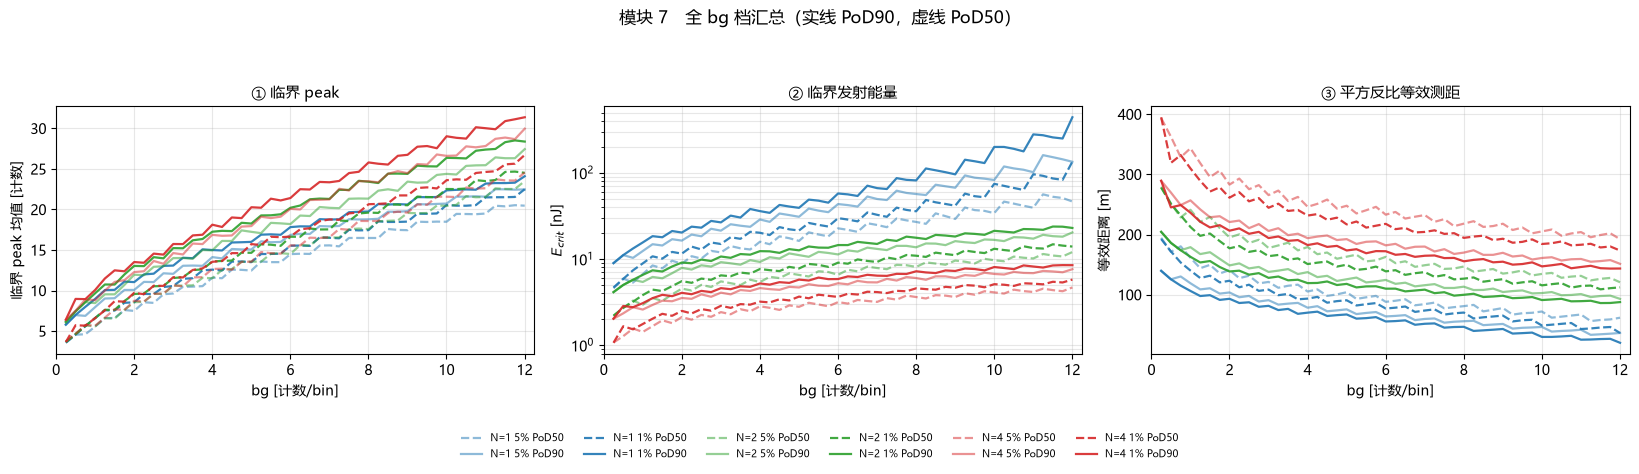

In [18]:
# ==================== 模块 7 绘图 ====================
_LS_LV = {0.50: "--", 0.90: "-"}
fig, ax = plt.subplots(1, 3, figsize=M7_FIGSIZE)
for n in N_SHOTS_LIST:
    for far in M7_FARS:
        tag = FAR_TAG[far]
        for lv in M7_LEVELS:
            arr = _collect_critical(n, tag, lv)
            if not arr.size:
                continue
            lab = f"N={n} {FAR_LABEL[far]} PoD{int(lv*100)}"
            ax[0].plot(arr[:, 0], arr[:, 2], _LS_LV[lv], color=_COLORS_N[n],
                       lw=1.6, alpha=0.9 if far == 0.01 else 0.5, label=lab)
            ax[1].semilogy(arr[:, 0], arr[:, 3], _LS_LV[lv], color=_COLORS_N[n],
                           lw=1.6, alpha=0.9 if far == 0.01 else 0.5, label=lab)
            ax[2].plot(arr[:, 0], arr[:, 4], _LS_LV[lv], color=_COLORS_N[n],
                       lw=1.6, alpha=0.9 if far == 0.01 else 0.5, label=lab)
ax[0].set_ylabel("临界 peak 均值 [计数]"); ax[0].set_title("① 临界 peak", fontsize=11)
ax[1].set_ylabel("$E_{crit}$ [nJ]");      ax[1].set_title("② 临界发射能量", fontsize=11)
ax[2].set_ylabel("等效距离 [m]");          ax[2].set_title("③ 平方反比等效测距", fontsize=11)
for i, a in enumerate(ax):
    a.set_xlabel("bg [计数/bin]"); a.set_xlim(*M7_XLIM)
    a.grid(alpha=0.3, which="both")
if M7_YLIM_E is not None:
    ax[1].set_ylim(*M7_YLIM_E)
if M7_YLIM_D is not None:
    ax[2].set_ylim(*M7_YLIM_D)
# 12 条曲线，图例放进画框会盖住数据 → 全图共用一个图例，摆在下方
_h, _l = ax[0].get_legend_handles_labels()
fig.legend(_h, _l, loc="lower center", ncol=6, fontsize=7.4,
           frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("模块 7　全 bg 档汇总（实线 PoD90，虚线 PoD50）", fontsize=12.5)
fig.tight_layout(rect=[0, 0.10, 1, 0.92])
fig.savefig("pod_v30_m7_summary.png", dpi=120, bbox_inches="tight")
plt.show()

## 模块 8 — 固定信号强度 × 全 bg 网格

对每个 `(N_shots, bg, boost)` 组合跑 MC，**保存完整的 peak 分布**（bincount）。
`boost` 固定不变、只让 bg 从 0.25 涨到 12，用来回答"同样的信号，底噪涨上来之后还剩多少"。

结果 `SIG_RES` 也是模块 14 的数据源，两个模块共用一份缓存。

- **boost**：回波能量倍率，`boost=0` 表示纯噪声（作为基线）。
- **Δpeak**：`peak_mean(boost) − peak_mean(0)`，信号带来的净抬升。

In [19]:
# ==================== 模块 8 计算（多进程脚本 + 缓存）====================
BOOST_LIST_SIG = np.round(np.arange(0.0, 0.032 + 1e-12, 0.004), 6)
SIG_SCRIPT = "run_pod_v30_sig_scan.py"


def _try_load_sig(path):
    if not (USE_CACHE and os.path.exists(path)):
        return None
    try:
        z = np.load(path)
        if (int(z["n_mc"]) != N_MC_SIG
                or not np.allclose(z["grid_key"], BG_GRID)
                or not np.array_equal(z["n_shots_list"], np.asarray(N_SHOTS_LIST))
                or not np.allclose(z["boosts"], BOOST_LIST_SIG)):
            return None
        for n in N_SHOTS_LIST:
            cnt = z[f"peak_cnt_{n}"]
            done = z[f"done_{n}"] if f"done_{n}" in z.files else (cnt.sum(axis=2) > 0)
            if not np.all(done):
                return None
        return z
    except Exception:
        return None


_zsig = None
for _cand in [CACHE_SIG, CACHE_SIG_CKPT]:
    _zsig = _try_load_sig(_cand)
    if _zsig is not None:
        print(f"模块 8 命中缓存 {_cand}")
        break

if _zsig is None:
    import sys
    print("=" * 72)
    print("未找到完整 v30 信号缓存 → 自动调用多进程扫描（ProcessPool，吃满 CPU）")
    print(f"规模：{len(BG_GRID)} bg × {len(BOOST_LIST_SIG)} boost × N={N_SHOTS_LIST}"
          f" × {N_MC_SIG:,} MC")
    print("=" * 72)
    _rc = _run_cmd_stream([sys.executable, SIG_SCRIPT,
                           "--workers", str(int(N_WORKERS)),
                           "--n-mc", str(int(N_MC_SIG))])
    if _rc != 0:
        raise RuntimeError(f"{SIG_SCRIPT} 失败，请查看上方进度输出")
    _zsig = _try_load_sig(CACHE_SIG)
    if _zsig is None:
        raise RuntimeError(f"多进程信号扫描结束但仍无法载入完整缓存 {CACHE_SIG}")
    print(f"多进程信号扫描完成，已载入 {CACHE_SIG}")

SIG_RES = {}
for n in N_SHOTS_LIST:
    cnt = np.asarray(_zsig[f"peak_cnt_{n}"])
    mu = np.zeros((len(BOOST_LIST_SIG), len(BG_GRID)))
    sd = np.zeros_like(mu)
    for i in range(len(BOOST_LIST_SIG)):
        for k in range(len(BG_GRID)):
            s = peak_stats_from_cnt(cnt[i, k])
            mu[i, k] = s["mean"]; sd[i, k] = s["std"]
    SIG_RES[n] = dict(cnt=cnt, mu=mu, sd=sd)
print(f"模块 8 就绪：{len(BOOST_LIST_SIG)} boost × {len(BG_GRID)} bg × N={N_SHOTS_LIST}，"
      f"每档 {N_MC_SIG:,} MC（含完整 peak 分布）。模块 14 直接复用。")

模块 8 命中缓存 pod_esti_v30_cache_signal.npz
模块 8 就绪：9 boost × 48 bg × N=[1, 2, 4]，每档 20,000 MC（含完整 peak 分布）。模块 14 直接复用。


In [20]:
# ==================== 模块 8 绘图参数 ====================
M8_XLIM      = (0.0, 12.25)  # 【两排横轴】bg 范围
M8_YLIM_MU   = None          # 【上排纵轴】peak 均值；None = 自动
M8_YLIM_GAIN = None          # 【下排纵轴】归一化增益 Δpeak/boost；None = 自动
M8_CMAP      = "viridis"     # 【配色】boost 由小到大
M8_FARS      = [0.01, 0.05]  # 【上排叠加的阈值】只画 1% 与 5%（来自模块 5 的 THRESH）
M8_FIGSIZE   = (5.4 * len(N_SHOTS_LIST), 8.2)

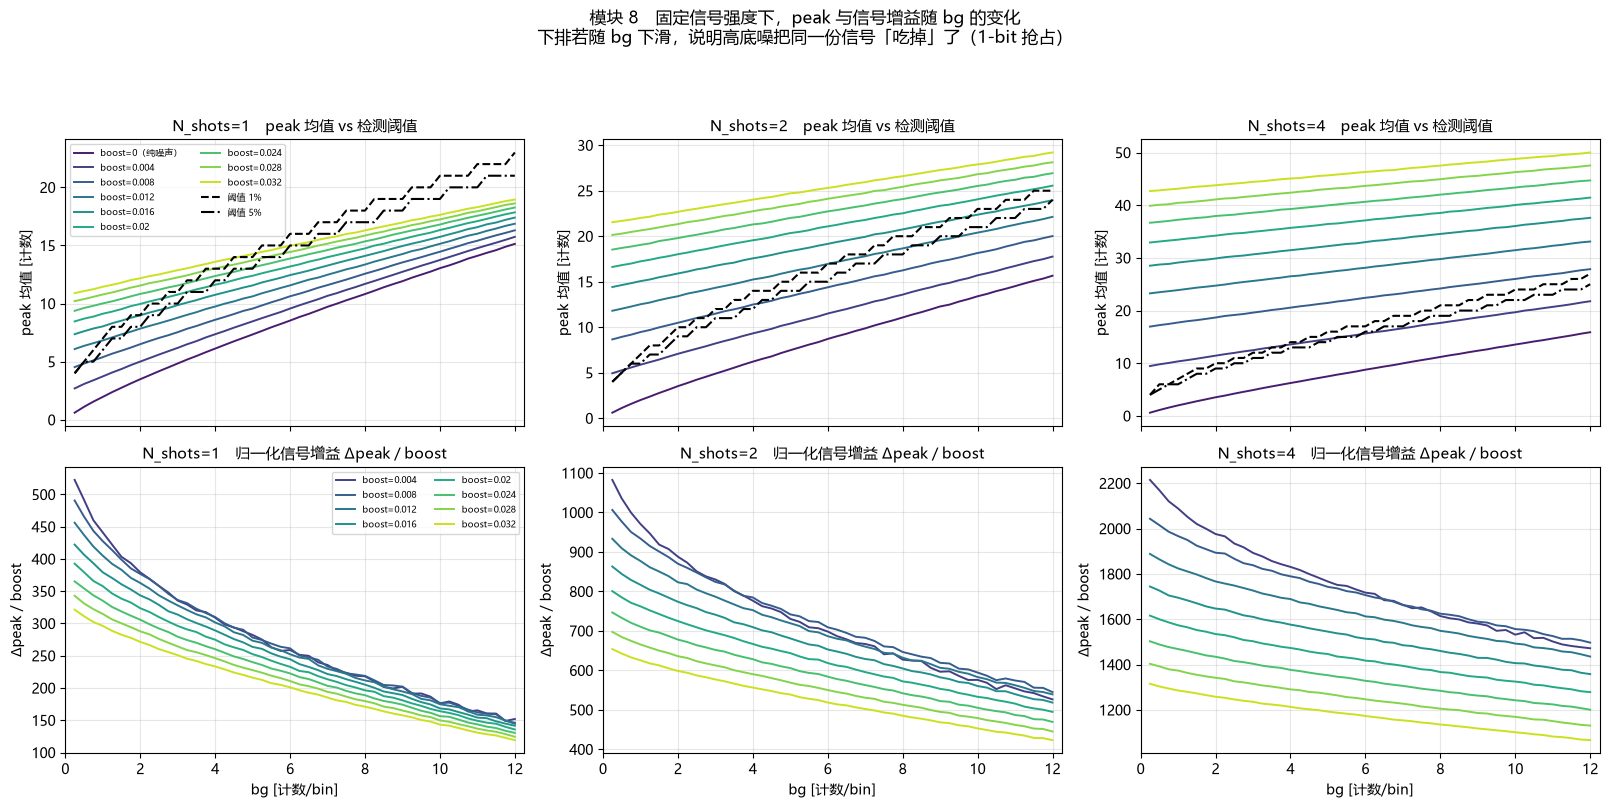

归一化增益随 bg 的衰减（越小说明信号被底噪吃得越狠）
  N    boost   bg=0.25     bg=6    bg=12      12档/最低档
  1    0.004    522.51   258.88   151.95        0.291
  1    0.008    490.56   261.48   146.21        0.298
  1    0.012    456.22   252.33   144.44        0.317
  1    0.016    422.26   244.59   141.52        0.335
  1    0.020    392.72   232.80   135.72        0.346
  1    0.024    365.18   222.61   130.41        0.357
  1    0.028    342.91   210.83   124.41        0.363
  1    0.032    321.43   201.09   119.22        0.371
  2    0.004   1082.49   698.33   526.46        0.486
  2    0.008   1006.38   709.22   544.91        0.541
  2    0.012    933.30   686.63   539.17        0.578
  2    0.016    863.09   652.88   518.35        0.601
  2    0.020    800.68   618.50   494.84        0.618
  2    0.024    746.66   584.01   469.40        0.629
  2    0.028    697.57   550.17   445.12        0.638
  2    0.032    653.93   518.56   423.27        0.647
  4    0.004   2214.79  1717.44  1471.89        0.665

In [21]:
# ==================== 模块 8 绘图 ====================
_bg = np.asarray(BG_GRID, float)
_bo = np.asarray(BOOST_LIST_SIG, float)
_cb = plt.get_cmap(M8_CMAP)(np.linspace(0.08, 0.92, len(_bo)))
fig, axes = plt.subplots(2, len(N_SHOTS_LIST), figsize=M8_FIGSIZE, sharex=True)
axes = np.atleast_2d(axes)
for j, n in enumerate(N_SHOTS_LIST):
    mu = SIG_RES[n]["mu"]
    for i, b in enumerate(_bo):
        axes[0, j].plot(_bg, mu[i], "-", color=_cb[i], lw=1.4,
                        label=f"boost={b:g}" + ("（纯噪声）" if b == 0 else ""))
        if b > 0:   # 归一化增益：同样一份信号在不同 bg 下还剩多少
            axes[1, j].plot(_bg, (mu[i] - mu[0]) / b, "-", color=_cb[i], lw=1.4,
                            label=f"boost={b:g}")
    # 叠上 1% / 5% 检测阈值：peak 均值曲线跌到阈值以下，就是这份信号在该 bg 下失守的位置
    for far, ls in zip(M8_FARS, ["--", "-."]):
        axes[0, j].plot(_bg, THRESH[n]["T" + FAR_TAG[far]], ls, color="k", lw=1.5,
                        label=f"阈值 {FAR_LABEL[far]}")
    axes[0, j].set_title(f"N_shots={n}　peak 均值 vs 检测阈值", fontsize=11)
    axes[0, j].set_ylabel("peak 均值 [计数]")
    axes[1, j].set_title(f"N_shots={n}　归一化信号增益 Δpeak / boost", fontsize=11)
    axes[1, j].set_xlabel("bg [计数/bin]")
    axes[1, j].set_ylabel(r"$\Delta$peak / boost")
    for r in (0, 1):
        axes[r, j].set_xlim(*M8_XLIM); axes[r, j].grid(alpha=0.3)
    if M8_YLIM_MU is not None:
        axes[0, j].set_ylim(*M8_YLIM_MU)
    if M8_YLIM_GAIN is not None:
        axes[1, j].set_ylim(*M8_YLIM_GAIN)
axes[0, 0].legend(fontsize=6.8, ncol=2)
axes[1, 0].legend(fontsize=6.8, ncol=2)
fig.suptitle("模块 8　固定信号强度下，peak 与信号增益随 bg 的变化\n"
             "下排若随 bg 下滑，说明高底噪把同一份信号「吃掉」了（1-bit 抢占）",
             fontsize=12.2)
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig("pod_v30_m8_sig_vs_bg.png", dpi=120, bbox_inches="tight")
plt.show()

print("=" * 84)
print("归一化增益随 bg 的衰减（越小说明信号被底噪吃得越狠）")
print(f"{'N':>3}{'boost':>9}{'bg=0.25':>10}{'bg=6':>9}{'bg=12':>9}{'12档/最低档':>13}")
_k_lo, _k_mid, _k_hi = 0, int(np.argmin(np.abs(_bg - 6.0))), len(_bg) - 1
for n in N_SHOTS_LIST:
    mu = SIG_RES[n]["mu"]
    for i, b in enumerate(_bo):
        if b == 0:
            continue
        g = (mu[i] - mu[0]) / b
        print(f"{n:>3d}{b:>9.3f}{g[_k_lo]:>10.2f}{g[_k_mid]:>9.2f}{g[_k_hi]:>9.2f}"
              f"{g[_k_hi]/max(g[_k_lo],1e-9):>13.3f}")

print("\n" + "=" * 84)
print("固定信号的「失守 bg」：peak 均值跌破阈值时的 bg（—— 表示全程都在阈值之上）")
print(f"{'N':>3}{'boost':>9}" + "".join(f"{'跌破'+FAR_LABEL[f]:>12}" for f in M8_FARS))
for n in N_SHOTS_LIST:
    mu = SIG_RES[n]["mu"]
    for i, b in enumerate(_bo):
        if b == 0:
            continue
        row = f"{n:>3d}{b:>9.3f}"
        for far in M8_FARS:
            d = mu[i] - THRESH[n]["T" + FAR_TAG[far]]
            k = np.where(d < 0)[0]
            row += f"{(f'{_bg[k[0]]:.2f}' if k.size else '——'):>12}"
        print(row)

## 模块 9 — 同 bg 下不同 N 的阈值倍数 ρ

**问的是什么**：把 N=1 / 2 / 4 拉到**同一个 bg**（同样的底噪水平）上，
它们需要的检测阈值差几倍？定义

`ρ_N = T_N / T_1`（同一个 bg、同一条 FAR）

如果 ρ 是一个与 bg 无关的常数，那么"多发累加要把阈值抬高几倍"就可以用一个数概括；
本模块就是检验这件事，并给出偏离常数有多大。

数据**全部来自模块 5 的 `THRESH`**，本模块不重算、也不重画阈值曲线本身。

In [22]:
# ==================== 模块 9 绘图参数 ====================
M9_FARS    = [0.05, 0.01]    # 【画哪几条 FAR】
M9_XLIM    = (0.0, 12.25)    # 【横轴】bg 范围
M9_YLIM_R  = None            # 【左图纵轴】ρ 范围；None = 自动
M9_YLIM_RES= (-15, 15)       # 【右图纵轴】相对残差 [%]
M9_BG_MIN  = 1.0             # 【统计 ρ̄ 时忽略多小的 bg】小 bg 处 T 只有几个计数，量化噪声极大
M9_FIGSIZE = (13.0, 4.6)

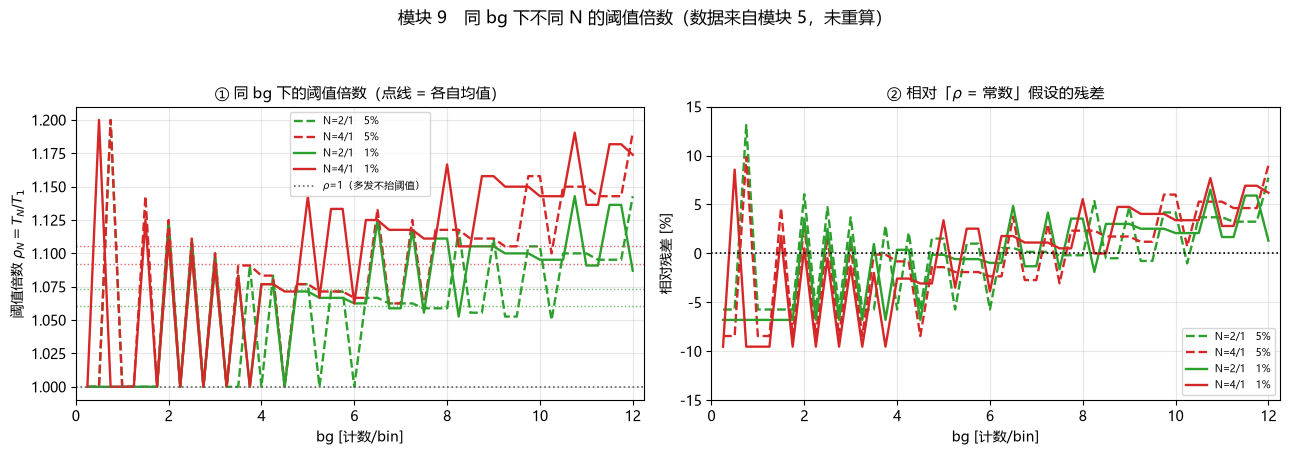

阈值倍数汇总（只统计 bg ≥ 1 的档，小 bg 处 T 量化噪声太大）
       FAR   N/1       ρ均值      ρ最小      ρ最大    残差rms[%]
        5%     2    1.0609   1.0000   1.1429        3.97
        5%     4    1.0923   1.0000   1.1905        4.56
        1%     2    1.0730   1.0000   1.1429        3.93
        1%     4    1.1054   1.0000   1.1905        4.96

【怎么读】残差 rms 越小，说明「阈值差一个固定倍数」这个说法越站得住。
  ρ 随 bg 上翘 = 大 bg 时多发累加要额外多抬阈值；根因见 theory_PoD_esti_v30.md。


In [23]:
# ==================== 模块 9 绘图 ====================
_bg = np.asarray(BG_GRID, float)
_msk9 = _bg >= M9_BG_MIN
fig, ax = plt.subplots(1, 2, figsize=M9_FIGSIZE)
_rows9 = []
for far in M9_FARS:
    tag = FAR_TAG[far]
    T1 = THRESH[1]["T" + tag].astype(float)
    for n in N_SHOTS_LIST:
        if n == 1:
            continue
        rho = THRESH[n]["T" + tag].astype(float) / np.maximum(T1, 1e-9)
        rho_bar = float(np.nanmean(rho[_msk9]))
        resid = (rho - rho_bar) / rho_bar * 100.0
        ls = "-" if far == 0.01 else "--"
        ax[0].plot(_bg, rho, ls, color=_COLORS_N[n], lw=1.7,
                   label=f"N={n}/1　{FAR_LABEL[far]}")
        ax[0].axhline(rho_bar, color=_COLORS_N[n], ls=":", lw=1.0, alpha=0.7)
        ax[1].plot(_bg, resid, ls, color=_COLORS_N[n], lw=1.7,
                   label=f"N={n}/1　{FAR_LABEL[far]}")
        _rows9.append((FAR_LABEL[far], n, rho_bar,
                       float(np.nanmin(rho[_msk9])), float(np.nanmax(rho[_msk9])),
                       float(np.sqrt(np.nanmean(resid[_msk9] ** 2)))))
ax[0].axhline(1.0, color="0.4", ls=":", lw=1.2, label=r"$\rho$=1（多发不抬阈值）")
ax[0].set_xlabel("bg [计数/bin]"); ax[0].set_ylabel(r"阈值倍数 $\rho_N=T_N/T_1$")
ax[0].set_title("① 同 bg 下的阈值倍数（点线 = 各自均值）", fontsize=11)
if M9_YLIM_R is not None:
    ax[0].set_ylim(*M9_YLIM_R)
ax[1].axhline(0.0, color="k", ls=":", lw=1.2)
ax[1].set_xlabel("bg [计数/bin]"); ax[1].set_ylabel("相对残差 [%]")
ax[1].set_title(r"② 相对「$\rho$ = 常数」假设的残差", fontsize=11)
ax[1].set_ylim(*M9_YLIM_RES)
for a in ax:
    a.set_xlim(*M9_XLIM); a.grid(alpha=0.3); a.legend(fontsize=7.4)
fig.suptitle("模块 9　同 bg 下不同 N 的阈值倍数（数据来自模块 5，未重算）", fontsize=12.5)
fig.tight_layout(rect=[0, 0, 1, 0.92])
fig.savefig("pod_v30_m9_rho.png", dpi=120, bbox_inches="tight")
plt.show()

print("=" * 88)
print(f"阈值倍数汇总（只统计 bg ≥ {M9_BG_MIN:g} 的档，小 bg 处 T 量化噪声太大）")
print(f"{'FAR':>10}{'N/1':>6}{'ρ均值':>10}{'ρ最小':>9}{'ρ最大':>9}{'残差rms[%]':>12}")
for lab, n, rb, rlo, rhi, rms in _rows9:
    print(f"{lab:>10}{n:>6d}{rb:>10.4f}{rlo:>9.4f}{rhi:>9.4f}{rms:>12.2f}")
print("\n【怎么读】残差 rms 越小，说明「阈值差一个固定倍数」这个说法越站得住。")
print("  ρ 随 bg 上翘 = 大 bg 时多发累加要额外多抬阈值；根因见 theory_PoD_esti_v30.md。")

## 模块 10 — 单条 hist 内的 std、peak 均值、peak 标准差 随 bg

三个统计量，全部来自模块 5 的同一批 MC（每档 1e6 条），不重算：

| # | 量 | 定义 |
|---|---|---|
| ① | **单条 hist 内 std** | 一条 `hist_add` 在统计窗 152 个 bin 上的样本标准差，再对所有 MC 条取平均。注意是"**一条直方图内部**的起伏"，不是"同一个 bin 在多条直方图之间的起伏" |
| ② | **peak 均值** | 统计窗内最大 bin 的均值 |
| ③ | **peak 标准差** | 统计窗内最大 bin 跨 MC 条的标准差 |

①③ 各叠一条解析对照线，公式与推导见 `theory_PoD_esti_v30.md`。

In [24]:
# ==================== 模块 10 绘图参数 ====================
M10_XLIM      = (0.0, 12.25)  # 【三张图横轴】bg 范围
M10_YLIM_STD  = None          # 【① 纵轴】hist 内 std；None = 自动
M10_YLIM_MEAN = None          # 【② 纵轴】peak 均值；None = 自动
M10_YLIM_PSTD = None          # 【③ 纵轴】peak 标准差；None = 自动
M10_SHOW_POISSON = True       # 【①】是否叠纯泊松 √bg 参考线
M10_SHOW_GUMBEL  = True       # 【③】是否叠 Gumbel 极值解析线
M10_FIGSIZE   = (16.5, 4.8)

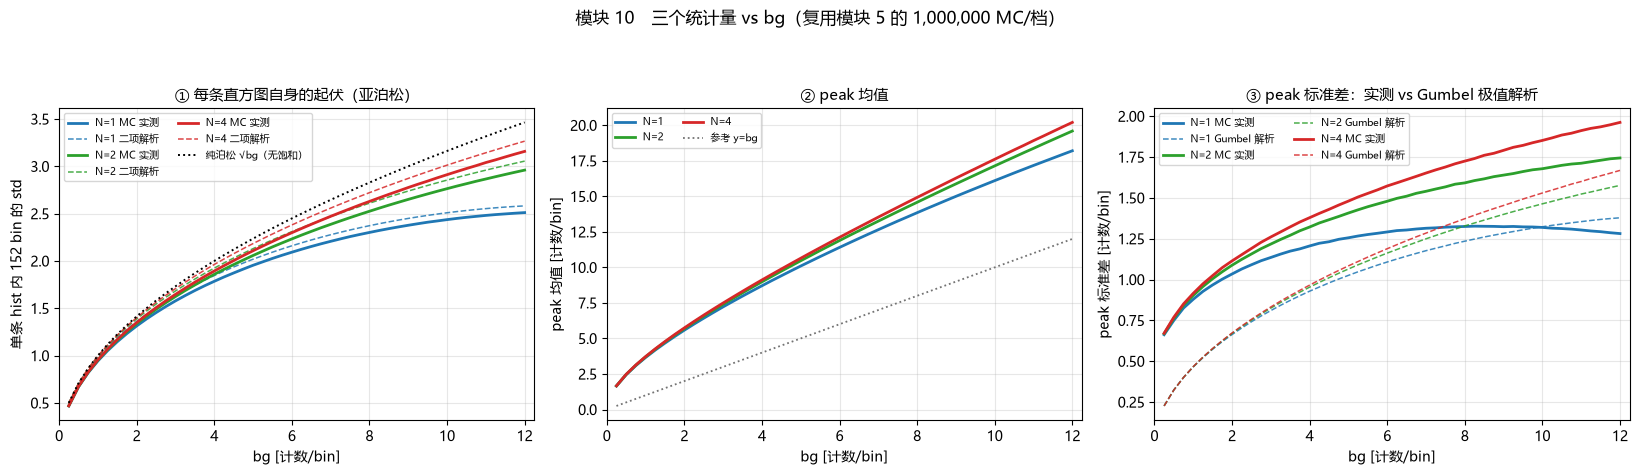

In [25]:
# ==================== 模块 10 绘图 ====================
_bg = np.asarray(BG_GRID, float)
fig, ax = plt.subplots(1, 3, figsize=M10_FIGSIZE)

for n in N_SHOTS_LIST:
    R = NOISE_RES[n]
    st = [peak_stats_from_cnt(c) for c in R["peak_cnt"]]
    pk_mean = np.array([s["mean"] for s in st])
    pk_std = np.array([s["std"] for s in st])
    sig_bin = np.sqrt(_bg * (1.0 - _bg / (N_PIX_MACRO * n)))   # 二项饱和解析

    ax[0].plot(_bg, R["hist_std"], "-", color=_COLORS_N[n], lw=2.0, label=f"N={n} MC 实测")
    ax[0].plot(_bg, sig_bin, "--", color=_COLORS_N[n], lw=1.1, alpha=0.85,
               label=f"N={n} 二项解析")
    ax[1].plot(_bg, pk_mean, "-", color=_COLORS_N[n], lw=2.0, label=f"N={n}")
    ax[2].plot(_bg, pk_std, "-", color=_COLORS_N[n], lw=2.0, label=f"N={n} MC 实测")
    if M10_SHOW_GUMBEL:
        z_M = (pk_mean - _bg) / np.maximum(sig_bin, 1e-9)
        sig_evt = (np.pi / np.sqrt(6.0)) * sig_bin / np.maximum(z_M, 1e-9)
        ax[2].plot(_bg, sig_evt, "--", color=_COLORS_N[n], lw=1.1, alpha=0.85,
                   label=f"N={n} Gumbel 解析")

if M10_SHOW_POISSON:
    ax[0].plot(_bg, np.sqrt(_bg), ":", color="k", lw=1.4, label="纯泊松 √bg（无饱和）")
ax[1].plot(_bg, _bg, ":", color="0.45", lw=1.3, label="参考 y=bg")

ax[0].set_ylabel("单条 hist 内 152 bin 的 std")
ax[0].set_title("① 每条直方图自身的起伏（亚泊松）", fontsize=11)
ax[1].set_ylabel("peak 均值 [计数/bin]")
ax[1].set_title("② peak 均值", fontsize=11)
ax[2].set_ylabel("peak 标准差 [计数/bin]")
ax[2].set_title("③ peak 标准差：实测 vs Gumbel 极值解析", fontsize=11)
for a, yl in zip(ax, [M10_YLIM_STD, M10_YLIM_MEAN, M10_YLIM_PSTD]):
    a.set_xlabel("bg [计数/bin]"); a.set_xlim(*M10_XLIM)
    if yl is not None:
        a.set_ylim(*yl)
    a.grid(alpha=0.3); a.legend(fontsize=7.0, ncol=2)
fig.suptitle(f"模块 10　三个统计量 vs bg（复用模块 5 的 {N_MC_NOISE:,} MC/档）", fontsize=12.5)
fig.tight_layout(rect=[0, 0, 1, 0.92])
fig.savefig("pod_v30_m10_stats.png", dpi=120, bbox_inches="tight")
plt.show()

## 模块 11 — 有效 z 值：阈值离 peak 均值几个 peak 标准差

`z = (T − μ_peak) / σ_peak`，其中 `μ_peak` / `σ_peak` 是**纯噪声** peak 的均值与标准差
（都来自模块 5）。它回答"这条 FAR 的阈值，在噪声 peak 分布上站在第几个 σ"，
是把不同 bg、不同 N 拉到同一把尺子上比较阈值裕量的最直接方式。

In [26]:
# ==================== 模块 11 绘图参数 ====================
M11_FARS   = [0.05, 0.01]    # 【画哪几条 FAR】
M11_XLIM   = (0.0, 12.25)    # 【横轴】bg 范围
M11_YLIM   = None            # 【纵轴】z 范围；None = 自动
M11_BG_MIN = 1.0             # 【统计均值时】忽略比它小的 bg
M11_FIGSIZE= (5.6 * 2, 4.6)

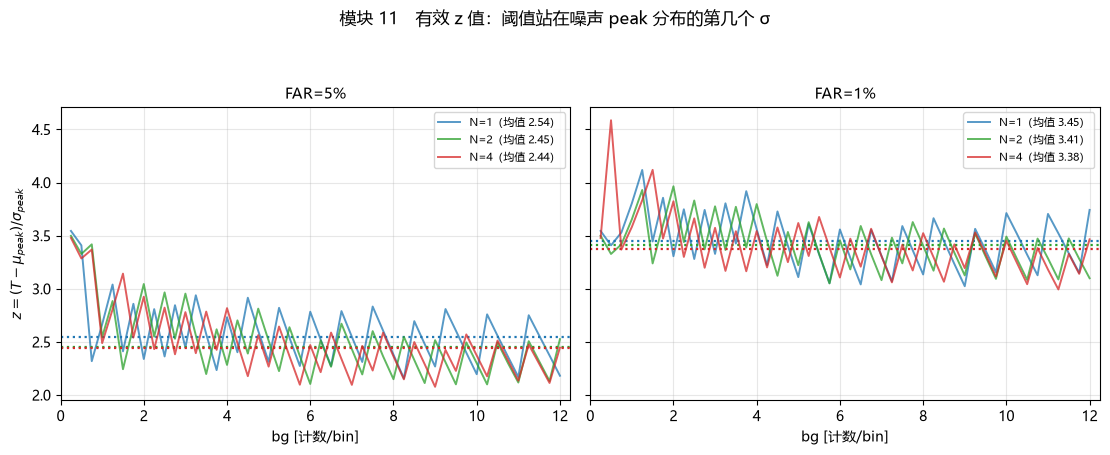

In [27]:
# ==================== 模块 11 绘图 ====================
_bg = np.asarray(BG_GRID, float)
_msk11 = _bg >= M11_BG_MIN
fig, axes = plt.subplots(1, len(M11_FARS), figsize=M11_FIGSIZE, sharey=True)
axes = np.atleast_1d(axes)
for a, far in zip(axes, M11_FARS):
    tag = FAR_TAG[far]
    for n in N_SHOTS_LIST:
        R = NOISE_RES[n]
        st = [peak_stats_from_cnt(c) for c in R["peak_cnt"]]
        mu = np.array([s["mean"] for s in st])
        sd = np.array([s["std"] for s in st])
        z = (THRESH[n]["T" + tag].astype(float) - mu) / np.maximum(sd, 1e-9)
        zbar = float(np.nanmean(z[_msk11]))
        a.plot(_bg, z, "-", color=_COLORS_N[n], lw=1.4, alpha=0.75,
               label=f"N={n}（均值 {zbar:.2f}）")
        # 锯齿来自整数阈值（T 只能跳 1，bg 连续步进），均值线才是可引用的结论
        a.axhline(zbar, color=_COLORS_N[n], ls=":", lw=1.6)
    a.set_xlabel("bg [计数/bin]")
    a.set_title(f"FAR={FAR_LABEL[far]}", fontsize=11)
    a.set_xlim(*M11_XLIM)
    if M11_YLIM is not None:
        a.set_ylim(*M11_YLIM)
    a.grid(alpha=0.3); a.legend(fontsize=8)
axes[0].set_ylabel(r"$z=(T-\mu_{peak})/\sigma_{peak}$")
fig.suptitle("模块 11　有效 z 值：阈值站在噪声 peak 分布的第几个 σ", fontsize=12.5)
fig.tight_layout(rect=[0, 0, 1, 0.92])
fig.savefig("pod_v30_m11_zeff.png", dpi=120, bbox_inches="tight")
plt.show()

## 模块 12 — 各 FAR 下 PoD50 / PoD90 所需信号的均值

复用模块 6 的 `POD_RES`，不重算。"所需信号"给三种口径，避免歧义：

| 口径 | 定义 |
|---|---|
| `peak_mean` | 临界点上 `hist_add` 峰值的均值（含底噪） |
| `S_net = peak_mean − bg` | 净峰高 |
| `E_crit` | 临界发射脉冲能量 [nJ]，可直接对照激光器指标 |

> `S_net` 会**高估**信号贡献：即使没有信号，在信号窗里取最大值本身也已高于 bg（极值抬升）。

In [28]:
# ==================== 模块 12 绘图参数 ====================
M12_FARS   = [0.05, 0.01]   # 【画哪几条 FAR】
M12_LEVELS = [0.50, 0.90]   # 【画哪几个 PoD 水平】
M12_XLIM   = (0.0, 12.25)   # 【横轴】bg 范围
M12_YLIM_S = None           # 【① 纵轴】净峰高；None = 自动
M12_YLIM_E = None           # 【② 纵轴】能量（对数）；None = 自动
M12_FIGSIZE= (5.8 * len(M12_FARS), 8.4)
M12_TABLE_FAR = 0.01        # 【文字表】用哪条 FAR
M12_TABLE_STEP = 8          # 【文字表】每隔几档 bg 打一行

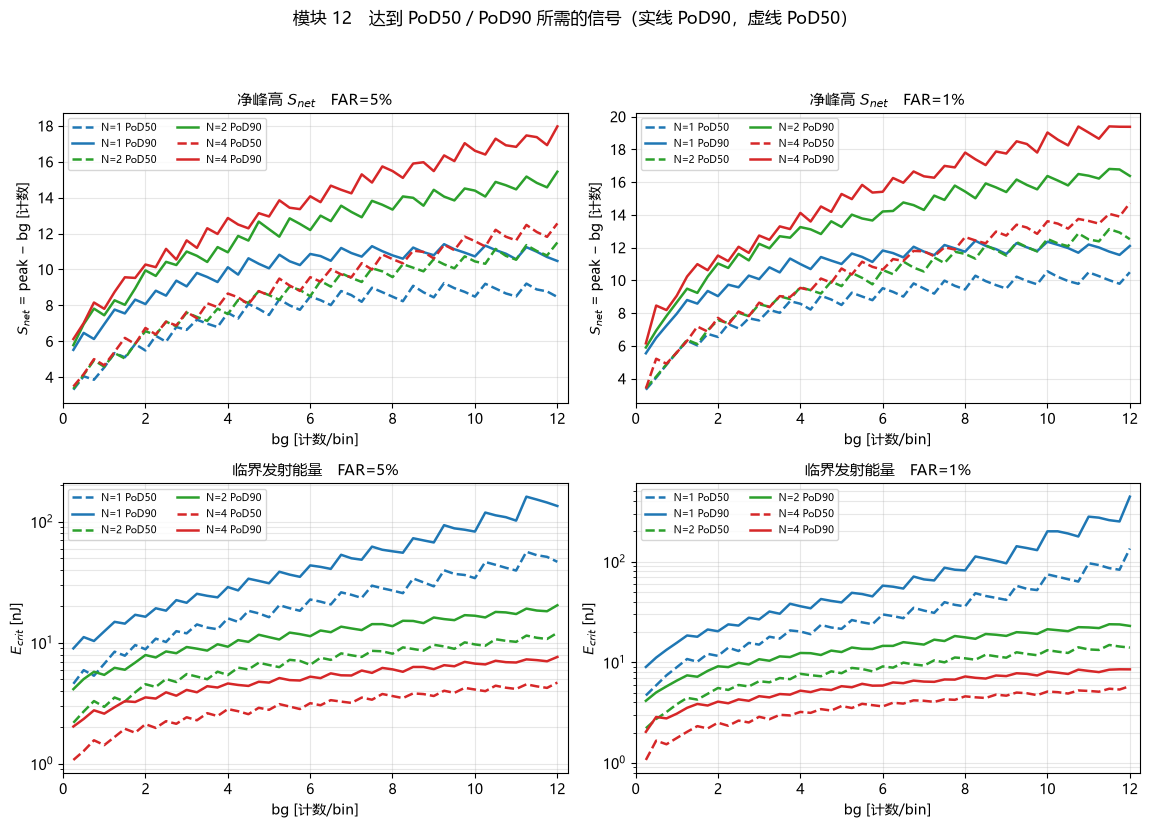

模块 12 抽样表（FAR=1%）
  N     bg   PoD    T    peakμ    S_net      E[nJ]
  1   0.25  0.49    4     3.58     3.33      4.680
  1   2.25  0.51   10     9.58     7.33     13.972
  1   4.25  0.49   13    12.47     8.22     19.029
  1   6.25  0.50   16    15.55     9.30     28.808
  1   8.25  0.51   19    18.54    10.29     48.605
  1  10.25  0.50   21    20.47    10.22     70.884
  1   0.25  0.90    4     5.80     5.55      8.987
  1   2.25  0.90   10    11.99     9.74     23.828
  1   4.25  0.89   13    14.94    10.69     34.432
  1   6.25  0.90   16    17.92    11.67     56.460
  1   8.25  0.91   19    20.67    12.42    112.831
  1  10.25  0.90   21    22.43    12.17    200.622
  2   0.25  0.50    4     3.68     3.43      2.207
  2   2.25  0.51   10     9.64     7.39      5.308
  2   4.25  0.52   14    13.65     9.40      7.443
  2   6.25  0.51   17    16.63    10.38      8.846
  2   8.25  0.51   20    19.58    11.33     10.609
  2  10.25  0.50   23    22.52    12.26     12.749
  2   0.25  0

In [29]:
# ==================== 模块 12 绘图 ====================
_LS_LV = {0.50: "--", 0.90: "-"}
fig, axes = plt.subplots(2, len(M12_FARS), figsize=M12_FIGSIZE)
axes = np.atleast_2d(axes)
for j, far in enumerate(M12_FARS):
    tag = FAR_TAG[far]
    for n in N_SHOTS_LIST:
        for lv in M12_LEVELS:
            arr = _collect_critical(n, tag, lv)
            if not arr.size:
                continue
            lab = f"N={n} PoD{int(lv*100)}"
            axes[0, j].plot(arr[:, 0], arr[:, 2] - arr[:, 0], _LS_LV[lv],
                            color=_COLORS_N[n], lw=1.8, label=lab)
            axes[1, j].semilogy(arr[:, 0], arr[:, 3], _LS_LV[lv],
                                color=_COLORS_N[n], lw=1.8, label=lab)
    axes[0, j].set_title(f"净峰高 $S_{{net}}$　FAR={FAR_LABEL[far]}", fontsize=11)
    axes[0, j].set_ylabel("$S_{net}$ = peak − bg [计数]")
    axes[1, j].set_title(f"临界发射能量　FAR={FAR_LABEL[far]}", fontsize=11)
    axes[1, j].set_ylabel("$E_{crit}$ [nJ]")
    for r in (0, 1):
        axes[r, j].set_xlabel("bg [计数/bin]"); axes[r, j].set_xlim(*M12_XLIM)
        axes[r, j].grid(alpha=0.3, which="both"); axes[r, j].legend(fontsize=7.4, ncol=2)
if M12_YLIM_S is not None:
    for j in range(len(M12_FARS)):
        axes[0, j].set_ylim(*M12_YLIM_S)
if M12_YLIM_E is not None:
    for j in range(len(M12_FARS)):
        axes[1, j].set_ylim(*M12_YLIM_E)
fig.suptitle("模块 12　达到 PoD50 / PoD90 所需的信号（实线 PoD90，虚线 PoD50）", fontsize=12.5)
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig("pod_v30_m12_signal_req.png", dpi=120, bbox_inches="tight")
plt.show()

print("=" * 96)
print(f"模块 12 抽样表（FAR={FAR_LABEL[M12_TABLE_FAR]}）")
print(f"{'N':>3}{'bg':>7}{'PoD':>6}{'T':>5}{'peakμ':>9}{'S_net':>9}{'E[nJ]':>11}")
_tag12 = FAR_TAG[M12_TABLE_FAR]
for n in N_SHOTS_LIST:
    for lv in M12_LEVELS:
        arr = _collect_critical(n, _tag12, lv)
        for i in range(0, len(arr), M12_TABLE_STEP):
            bgv, pod, pm, e_nj = arr[i, 0], arr[i, 1], arr[i, 2], arr[i, 3]
            Tv = int(arr[i, 5])
            print(f"{n:>3d}{bgv:>7.2f}{pod:>6.2f}{Tv:>5d}{pm:>9.2f}"
                  f"{pm-bgv:>9.2f}{e_nj:>11.3f}")

## 模块 13 — 平方反比下的测距能力

信号回波功率 ∝ `1/D²`。把模块 6 的临界能量换算成"在给定发射能量下能测多远"：
给出**纯平方反比**与**含大气衰减** `exp(−2αD)` 两种口径。复用 `POD_RES`，不重算。

In [30]:
# ==================== 模块 13 绘图参数 ====================
M13_FAR      = 0.01          # 【用哪条 FAR】
M13_LEVEL    = 0.90          # 【用哪个 PoD 水平】
M13_E_BUDGET = [1.0, 10.0, 100.0]   # 【发射能量预算 nJ】每个值一条曲线
M13_XLIM     = (0.0, 12.25)  # 【横轴】bg 范围
M13_YLIM     = None          # 【纵轴】距离 [m]；None = 自动
M13_FIGSIZE  = (12.6, 4.6)

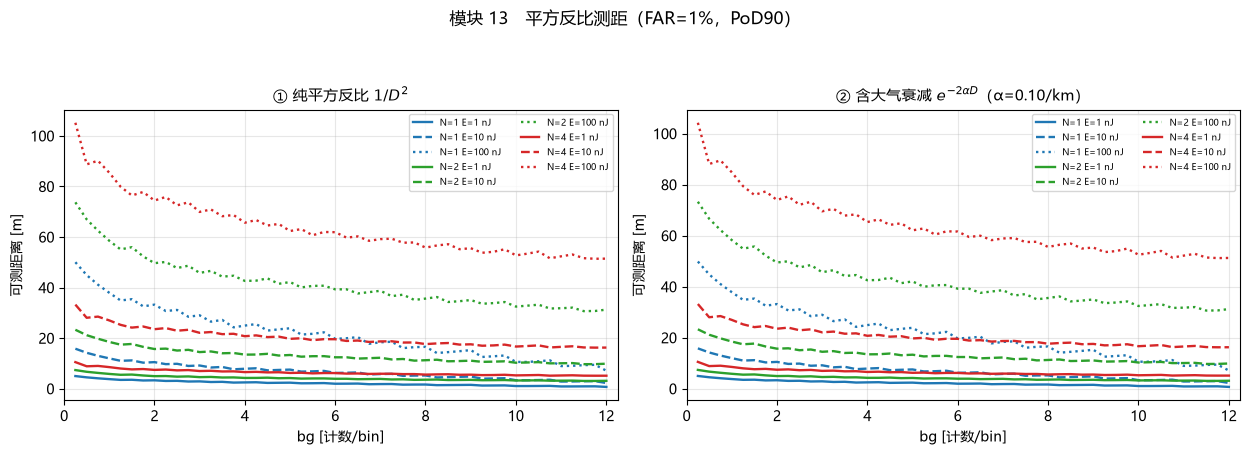

In [31]:
# ==================== 模块 13 绘图 ====================
# 记号：boost = 发射能量倍率；接收端衰减比 ratio = boost_crit / boost_avail，
#       满足 (D_ref/D)²·exp(−2α(D−D_ref)) = ratio。equiv_distance() 就是解这个方程。
_tag13 = FAR_TAG[M13_FAR]
fig, ax = plt.subplots(1, 2, figsize=M13_FIGSIZE)
for n in N_SHOTS_LIST:
    arr = _collect_critical(n, _tag13, M13_LEVEL)
    if not arr.size:
        continue
    bgv, boost_crit = arr[:, 0], arr[:, 6]
    for e_bud, ls in zip(M13_E_BUDGET, ["-", "--", ":"]):
        boost_avail = e_bud * 1e-9 / E_PULSE_BASE
        ratio = boost_crit / max(boost_avail, 1e-30)
        d_pure = D_TARGET / np.sqrt(np.maximum(ratio, 1e-30))   # 纯 1/D²
        d_att = np.array([equiv_distance(r) for r in ratio])    # 含 exp(−2αD)
        ax[0].plot(bgv, d_pure, ls, color=_COLORS_N[n], lw=1.7,
                   label=f"N={n} E={e_bud:g} nJ")
        ax[1].plot(bgv, d_att, ls, color=_COLORS_N[n], lw=1.7,
                   label=f"N={n} E={e_bud:g} nJ")
ax[0].set_title("① 纯平方反比 $1/D^2$", fontsize=11)
ax[1].set_title(f"② 含大气衰减 $e^{{-2\\alpha D}}$"
                f"（α={PARAMS['channel']['alpha']*1e3:.2f}/km）", fontsize=11)
for a in ax:
    a.set_xlabel("bg [计数/bin]"); a.set_ylabel("可测距离 [m]")
    a.set_xlim(*M13_XLIM)
    if M13_YLIM is not None:
        a.set_ylim(*M13_YLIM)
    a.grid(alpha=0.3); a.legend(fontsize=6.8, ncol=2)
fig.suptitle(f"模块 13　平方反比测距（FAR={FAR_LABEL[M13_FAR]}，PoD{int(M13_LEVEL*100)}）",
             fontsize=12.5)
fig.tight_layout(rect=[0, 0, 1, 0.92])
fig.savefig("pod_v30_m13_range.png", dpi=120, bbox_inches="tight")
plt.show()

## 模块 14 — 同一信号强度、不同 bg 时 peak 分布怎么变

用模块 8 的固定信号扫描（每个 `(N, bg, boost)` 都存了**完整 peak 分布**），回答三件事：

1. **分布形状怎么变**：同一个 `boost` 在不同 bg 下的 peak 概率质量函数（PMF）叠一起看。
2. **peak 均值是不是"只是加上 bg"**：叠一条**理想加法线**
   `μ_ideal(bg) = μ(b, bg_min) + (bg − bg_min)`（斜率 = 1）。贴合则成立，偏离即证伪。
3. **peak 标准差怎么变**：对比有信号与无信号的 `σ_peak`，并看偏度。

In [32]:
# ==================== 模块 14 绘图参数 ====================
M14_BG_SHOW  = [0.5, 3.0, 6.0, 9.0, 12.0]  # 【① PMF 叠加】画哪几个 bg 档
M14_BOOST_I  = None        # 【用第几档 boost】None = 取中间那档
M14_XLIM     = (0.0, 12.25)   # 【②③ 横轴】bg 范围
M14_PMF_XLIM = None        # 【① 横轴】peak 计数范围；None = 自动
M14_YLIM_MU  = None        # 【② 纵轴】peak 均值；None = 自动
M14_YLIM_SD  = None        # 【③ 纵轴】peak 标准差；None = 自动
M14_FIGSIZE  = (5.6 * len(N_SHOTS_LIST), 12.0)

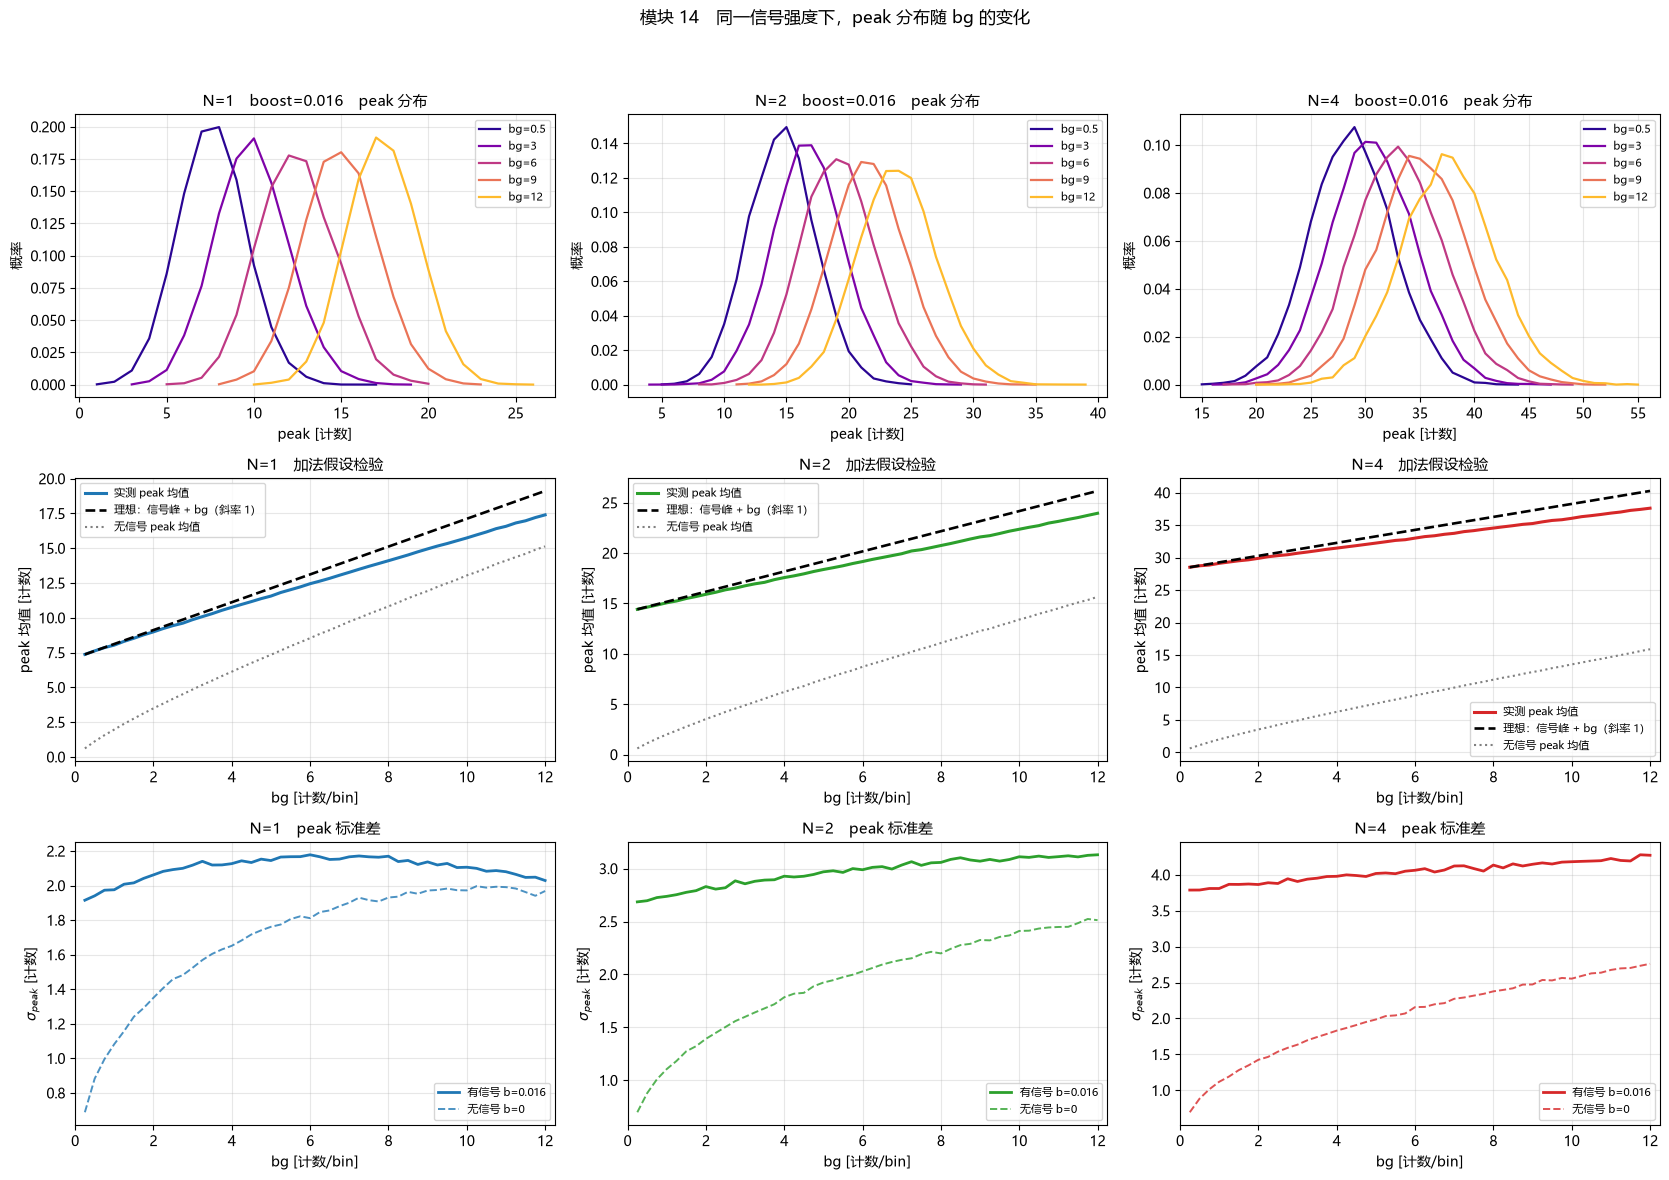

加法假设检验（boost=0.016）：理想线 = μ(b,bg_min)+(bg−bg_min)，斜率应为 1
  N            bg范围    实测Δpeak     Δbg      实测斜率      高bg残差
  1      0.25→12.00      10.03   11.75     0.854      -1.72
  2      0.25→12.00       9.53   11.75     0.811      -2.22
  4      0.25→12.00       9.09   11.75     0.774      -2.66


In [33]:
# ==================== 模块 14 绘图 ====================
_bg = np.asarray(BG_GRID, float)
_bo = np.asarray(BOOST_LIST_SIG, float)
_ib = int(len(_bo) // 2) if M14_BOOST_I is None else int(M14_BOOST_I)
_ks = [int(np.argmin(np.abs(_bg - b))) for b in M14_BG_SHOW]
_k0 = int(np.argmin(_bg))
_cbg = plt.cm.plasma(np.linspace(0.05, 0.85, len(_ks)))

fig, axes = plt.subplots(3, len(N_SHOTS_LIST), figsize=M14_FIGSIZE)
axes = np.atleast_2d(axes)
for j, n in enumerate(N_SHOTS_LIST):
    mu_b = SIG_RES[n]["mu"][_ib]
    sd_b = SIG_RES[n]["sd"][_ib]
    mu_0 = SIG_RES[n]["mu"][0]
    sd_0 = SIG_RES[n]["sd"][0]

    # ① 不同 bg 下的 peak PMF
    for c, k in zip(_cbg, _ks):
        cnt = np.asarray(SIG_RES[n]["cnt"][_ib, k], float)
        tot = max(cnt.sum(), 1.0)
        x = np.arange(cnt.size); m = cnt > 0
        axes[0, j].plot(x[m], (cnt / tot)[m], "-", color=c, lw=1.6,
                        label=f"bg={_bg[k]:g}")
    axes[0, j].set_title(f"N={n}　boost={_bo[_ib]:g}　peak 分布", fontsize=11)
    axes[0, j].set_xlabel("peak [计数]"); axes[0, j].set_ylabel("概率")
    if M14_PMF_XLIM is not None:
        axes[0, j].set_xlim(*M14_PMF_XLIM)
    axes[0, j].grid(alpha=0.3); axes[0, j].legend(fontsize=7.6)

    # ② 「peak = 信号峰 + bg」加法理想线
    ideal = mu_b[_k0] + (_bg - _bg[_k0])
    axes[1, j].plot(_bg, mu_b, "-", color=_COLORS_N[n], lw=2.2, label="实测 peak 均值")
    axes[1, j].plot(_bg, ideal, "k--", lw=1.9, label="理想：信号峰 + bg（斜率 1）")
    axes[1, j].plot(_bg, mu_0, ":", color="0.5", lw=1.5, label="无信号 peak 均值")
    axes[1, j].set_title(f"N={n}　加法假设检验", fontsize=11)
    axes[1, j].set_xlabel("bg [计数/bin]"); axes[1, j].set_ylabel("peak 均值 [计数]")
    axes[1, j].set_xlim(*M14_XLIM)
    if M14_YLIM_MU is not None:
        axes[1, j].set_ylim(*M14_YLIM_MU)
    axes[1, j].grid(alpha=0.3); axes[1, j].legend(fontsize=7.6)

    # ③ peak 标准差：有信号 vs 无信号
    axes[2, j].plot(_bg, sd_b, "-", color=_COLORS_N[n], lw=2.0,
                    label=f"有信号 b={_bo[_ib]:g}")
    axes[2, j].plot(_bg, sd_0, "--", color=_COLORS_N[n], lw=1.4, alpha=0.8,
                    label="无信号 b=0")
    axes[2, j].set_title(f"N={n}　peak 标准差", fontsize=11)
    axes[2, j].set_xlabel("bg [计数/bin]"); axes[2, j].set_ylabel(r"$\sigma_{peak}$ [计数]")
    axes[2, j].set_xlim(*M14_XLIM)
    if M14_YLIM_SD is not None:
        axes[2, j].set_ylim(*M14_YLIM_SD)
    axes[2, j].grid(alpha=0.3); axes[2, j].legend(fontsize=7.6)

fig.suptitle("模块 14　同一信号强度下，peak 分布随 bg 的变化", fontsize=12.5)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig("pod_v30_m14_peak_vs_bg.png", dpi=120, bbox_inches="tight")
plt.show()

print("=" * 92)
print(f"加法假设检验（boost={_bo[_ib]:g}）：理想线 = μ(b,bg_min)+(bg−bg_min)，斜率应为 1")
print(f"{'N':>3}{'bg范围':>16}{'实测Δpeak':>11}{'Δbg':>8}{'实测斜率':>10}{'高bg残差':>11}")
for n in N_SHOTS_LIST:
    mu_b = SIG_RES[n]["mu"][_ib]
    dbg = _bg[-1] - _bg[_k0]
    dpk = mu_b[-1] - mu_b[_k0]
    print(f"{n:>3d}{f'{_bg[_k0]:.2f}→{_bg[-1]:.2f}':>16}{dpk:>11.2f}{dbg:>8.2f}"
          f"{dpk/max(dbg,1e-9):>10.3f}{mu_b[-1]-(mu_b[_k0]+dbg):>+11.2f}")

## 模块 15 — 宏像元 3×9 vs 3×6 阈值对比

比较两种宏像元尺寸：3×9 = 27 个 SPAD、3×6 = 18 个 SPAD。

**口径（不写清会得到相反结论）**：
- 噪声在每个 SPAD 上**均匀**，只由 `p_eq`（单 SPAD、单发、单 bin 被点亮的平衡态概率）刻画，
  与宏像元多大无关。宏像元每 bin 底噪 `bg = n_tr · p_eq`，`n_tr = n_pix × N_shots`。
- 信号也按每 SPAD **均匀**处理（用户指定；若按像斑加权结论会反过来）。
  灵敏度判据取 `q_req = (T − bg) / n_tr`，越小越灵敏。

**出图**（三张独立图，不再并排）：
- ①a 同 bg 阈值精简版：只画 3×6@N=2、3×9@N=2、3×9@N=4
- ①b 同 bg 阈值全量版：全部配置
- ② `q_req`：全部配置（内容与原先右图相同）

In [34]:
# ==================== 模块 15 计算（多进程脚本 + 缓存）====================
MACRO_SCRIPT = "compare_macro_v30.py"
MACRO_CACHE = "compare_macro_v30_cache.npz"
MACRO_FAR = 0.01                 # 主 FAR
MACRO_FAR_KEYS = [0.05, 0.01, 0.001, 100e-6]
MACRO_N_MC = 600_000             # ★ v30：由 v20 的 300k 提到 600k
MACRO_CFGS = [
    # shots 里给 3×6 多留一个 N=6：它的 n_tr = 18×6 = 108，与 3×9 N=4 相同，
    # 是「纯噪声只经 n_tr 进入」这条理论的等 n_tr 校验点。
    {"name": "3×9（27 SPAD）", "nx": 9, "ny": 3, "n_pix": 27, "shots": [1, 2, 4]},
    {"name": "3×6（18 SPAD）", "nx": 6, "ny": 3, "n_pix": 18, "shots": [1, 2, 4, 6]},
]
_MACRO_COLOR = {
    ("3×9（27 SPAD）", 1): "#9ecae1", ("3×9（27 SPAD）", 2): "#4292c6",
    ("3×9（27 SPAD）", 4): "#08519c",
    ("3×6（18 SPAD）", 1): "#fcae91", ("3×6（18 SPAD）", 2): "#fb6a4a",
    ("3×6（18 SPAD）", 4): "#cb181d", ("3×6（18 SPAD）", 6): "#67000d",
}

if not os.path.exists(MACRO_CACHE):
    import sys
    print("=" * 72)
    print(f"未找到 {MACRO_CACHE} → 调用 {MACRO_SCRIPT}（{MACRO_N_MC:,} MC/档，耗时较长）")
    print("=" * 72)
    _rc = _run_cmd_stream([sys.executable, MACRO_SCRIPT,
                           "--workers", str(int(N_WORKERS)),
                           "--n-mc", str(int(MACRO_N_MC))])
    if _rc != 0:
        raise RuntimeError(f"{MACRO_SCRIPT} 失败，请查看上方进度输出")

_zm = np.load(MACRO_CACHE)
_cfgs_raw = [tuple(int(v) for v in c) for c in np.asarray(_zm["cfgs"])]
_i_far = MACRO_FAR_KEYS.index(MACRO_FAR)
MACRO_RES = {}
for cfg in MACRO_CFGS:
    for n in cfg["shots"]:
        key = (cfg["nx"], cfg["ny"], n)
        if key not in _cfgs_raw:
            continue
        ci = _cfgs_raw.index(key)
        ok = np.asarray(_zm["done"])[ci]
        bg = np.asarray(_zm["bg_mc"])[ci][ok]
        T = np.asarray(_zm[f"thr_{_i_far}"])[ci][ok]
        o = np.argsort(bg)
        bg, T = bg[o], T[o]
        n_tr = cfg["n_pix"] * n
        MACRO_RES[(cfg["name"], n)] = dict(
            bg=bg, T=T, n_tr=n_tr, q_req=(T - bg) / n_tr,
            peak_mean=np.asarray(_zm["peak_mean"])[ci][ok][o],
        )
print(f"模块 15 就绪：{len(MACRO_RES)} 条曲线，FAR={MACRO_FAR:.0%}，"
      f"每档 {MACRO_N_MC:,} MC，来自 {MACRO_CACHE}")

模块 15 就绪：7 条曲线，FAR=1%，每档 600,000 MC，来自 compare_macro_v30_cache.npz


In [35]:
# ==================== 模块 15 绘图参数 ====================
# 三张独立图，不再并排连图：
#   ①a 阈值精简版（只画 3×6@N=2、3×9@N=2、3×9@N=4）
#   ①b 阈值全量版（全部配置）
#   ②  q_req（全部配置，内容与原先右图相同）
M15_XLIM    = None       # 【横轴】三张图共用的 bg 范围；None = 自动（线性轴）
M15_YLIM_T  = None       # 【①a / ①b 纵轴】阈值 T
M15_YLIM_Q  = None       # 【② 纵轴】q_req
M15_ANNOT   = True       # 【②】是否标注等 n_tr 的两个配置重合（打印表里仍会校验）
M15_FIGSIZE = (7.6, 4.8) # 【单张图】尺寸；三张各自独立输出
# 【①a 精简版】只画这些 (宏像元名, N_shots)。名字必须与 MACRO_CFGS 里的 name 完全一致。
M15_T_FOCUS = [
    ("3×6（18 SPAD）", 2),
    ("3×9（27 SPAD）", 2),
    ("3×9（27 SPAD）", 4),
]

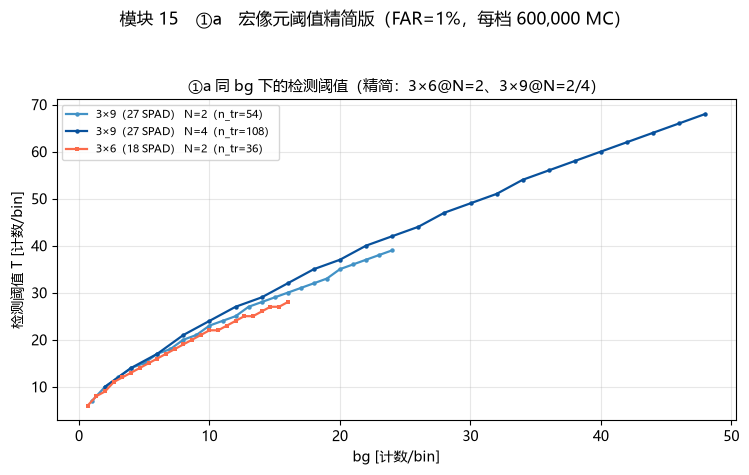

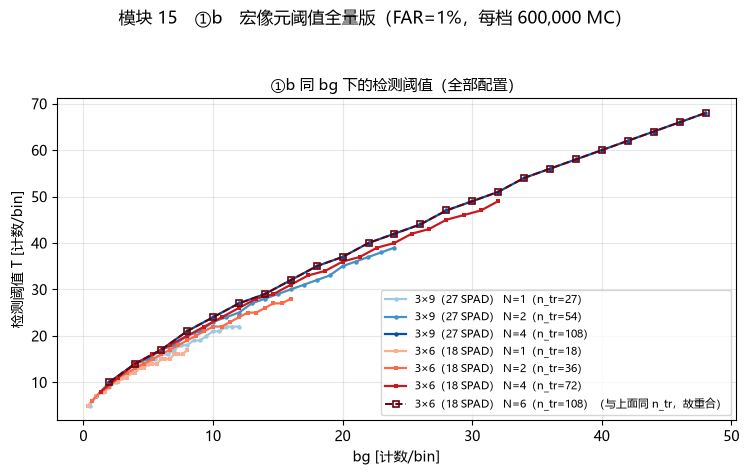

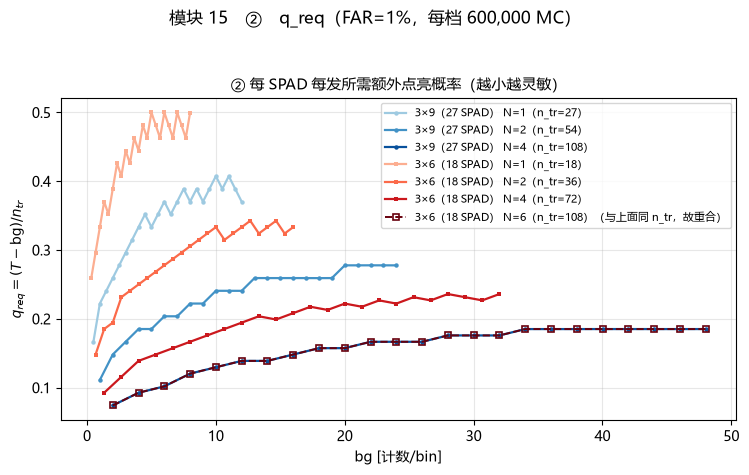

等 n_tr 校验：n_tr 相同的配置，纯噪声阈值应当完全一致（噪声只经 n_tr 进入）
  n_tr= 108：3×9（27 SPAD） N=4、3×6（18 SPAD） N=6　→ 阈值完全相同


In [36]:
# ==================== 模块 15 绘图 ====================
_MARKER = {"3×9（27 SPAD）": "o", "3×6（18 SPAD）": "s"}


def _m15_iter(keys=None):
    # keys=None → 全部配置；否则只迭代给定的 (name, N) 列表。
    # n_tr 相同的第二条改画虚线 + 空心点，让底下那条透出来，才能看出"重合"。
    drawn_ntr = set()
    for cfg in MACRO_CFGS:
        mk = _MARKER.get(cfg["name"], "o")
        for n in cfg["shots"]:
            if keys is not None and (cfg["name"], n) not in keys:
                continue
            d = MACRO_RES.get((cfg["name"], n))
            if not d:
                continue
            ntr = cfg["n_pix"] * n
            dup = ntr in drawn_ntr
            drawn_ntr.add(ntr)
            col = _MACRO_COLOR[(cfg["name"], n)]
            sty = dict(ls="--" if dup else "-", marker=mk, ms=5.0 if dup else 3.2,
                       color=col, lw=1.4 if dup else 1.6,
                       mfc="none" if dup else col, mew=1.2 if dup else 0.0)
            tail = "（与上面同 n_tr，故重合）" if dup else ""
            yield d, sty, f"{cfg['name']} N={n}（n_tr={ntr}）{tail}", cfg["name"], n


def _m15_apply_axes(a, ylabel, title, ylim):
    a.set_xlabel("bg [计数/bin]")
    a.set_ylabel(ylabel)
    a.set_title(title, fontsize=11)
    if M15_XLIM is not None:
        a.set_xlim(*M15_XLIM)
    if ylim is not None:
        a.set_ylim(*ylim)
    a.grid(alpha=0.3)
    a.legend(fontsize=7.6, loc="best")


_focus = set(M15_T_FOCUS)

# ---- ①a：阈值精简版 ----
fig, ax = plt.subplots(figsize=M15_FIGSIZE)
for d, sty, lab, _, _ in _m15_iter(_focus):
    ax.plot(d["bg"], d["T"], **sty, label=lab)
_m15_apply_axes(ax, "检测阈值 T [计数/bin]",
                "①a 同 bg 下的检测阈值（精简：3×6@N=2、3×9@N=2/4）", M15_YLIM_T)
fig.suptitle(f"模块 15　①a　宏像元阈值精简版（FAR={FAR_LABEL[MACRO_FAR]}，"
             f"每档 {MACRO_N_MC:,} MC）", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig("pod_v30_m15_T_focus.png", dpi=120, bbox_inches="tight")
plt.show()

# ---- ①b：阈值全量版 ----
fig, ax = plt.subplots(figsize=M15_FIGSIZE)
for d, sty, lab, _, _ in _m15_iter(None):
    ax.plot(d["bg"], d["T"], **sty, label=lab)
_m15_apply_axes(ax, "检测阈值 T [计数/bin]",
                "①b 同 bg 下的检测阈值（全部配置）", M15_YLIM_T)
fig.suptitle(f"模块 15　①b　宏像元阈值全量版（FAR={FAR_LABEL[MACRO_FAR]}，"
             f"每档 {MACRO_N_MC:,} MC）", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig("pod_v30_m15_T_all.png", dpi=120, bbox_inches="tight")
plt.show()

# ---- ②：q_req（内容与原先右图相同，单独成图）----
fig, ax = plt.subplots(figsize=M15_FIGSIZE)
for d, sty, lab, _, _ in _m15_iter(None):
    ax.plot(d["bg"], d["q_req"], **sty, label=lab)
_m15_apply_axes(ax, r"$q_{req}=(T-\mathrm{bg})/n_{tr}$",
                "② 每 SPAD 每发所需额外点亮概率（越小越灵敏）", M15_YLIM_Q)
fig.suptitle(f"模块 15　②　q_req（FAR={FAR_LABEL[MACRO_FAR]}，"
             f"每档 {MACRO_N_MC:,} MC）", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig("pod_v30_m15_qreq.png", dpi=120, bbox_inches="tight")
plt.show()

print("=" * 96)
print("等 n_tr 校验：n_tr 相同的配置，纯噪声阈值应当完全一致（噪声只经 n_tr 进入）")
_by_ntr = {}
for cfg in MACRO_CFGS:
    for n in cfg["shots"]:
        d = MACRO_RES.get((cfg["name"], n))
        if d:
            _by_ntr.setdefault(cfg["n_pix"] * n, []).append((cfg["name"], n, d["T"]))
for ntr, items in sorted(_by_ntr.items()):
    if len(items) < 2:
        continue
    base = items[0][2]
    same = all(np.array_equal(base, it[2]) for it in items[1:])
    names = "、".join(f"{a} N={b}" for a, b, _ in items)
    print(f"  n_tr={ntr:>4d}：{names}　→ 阈值{'完全相同' if same else '不同（需排查）'}")

## 回收站（不运行）

以下是 v20 中已被替换或判定无用的代码，**整段注释保留只为可追溯**。
变量名与 v30 已经不一致，不要取消注释直接跑。

- v20 模块 6 的六条 FAR 阈值大图 → v30 并入模块 5，且只画 1% / 5%。
- v20 模块 12 的连续（实数）阈值 → 已确认阈值必须是整数计数，整块作废；
  其中 12C 的「有效 z 值」被保留，成为 v30 模块 11。

In [37]:
# ================= v20 模块 6：六条 FAR 阈值大图（作废） =================
# # ---- 阈值图：6 条 FAR（2 条 ppm + 4 条百分数）----
# fig, ax = plt.subplots(1, 3, figsize=(18.5, 5.4))
# _cns = {1: "tab:blue", 2: "tab:green", 4: "tab:red"}
# # 线型按 FAR 从严到松区分
# _ls_by_tag = {
#     "100ppm": "-", "10ppm": "--",
#     "5pct": "-.", "1pct": ":",
#     "0p5pct": (0, (3, 1, 1, 1)), "0p1pct": (0, (1, 1)),
# }
# 
# _FAR_CMP = [f for f in TARGET_FARS if f in (0.05, 0.01)]  # 不同 shot 对比图只画 1% 与 5%
# 
# # ① noise–threshold
# for n_shots in N_SHOTS_LIST:
#     R, Tr = NOISE_RES[n_shots], THRESH[n_shots]
#     c = _cns.get(n_shots, "k")
#     for far in _FAR_CMP:
#         tag = FAR_TAG[far]
#         ax[0].plot(
#             Tr["noise"], Tr["T"+tag], ls=_ls_by_tag.get(tag, "-"),
#             color=c, lw=1.8,
#             label=f"N={n_shots}, {FAR_LABEL[far]}",
#         )
#     ax[0].axhline(R["n_tr"], color=c, ls="-.", lw=1.0, alpha=0.4,
#                   label=f"N={n_shots} 硬上限 {R['n_tr']}")
# ax[0].set_xlabel("噪声均值 noise [计数 / 1 ns bin]")
# ax[0].set_ylabel("检测阈值 T [计数 / 1 ns bin]")
# ax[0].set_title("① noise–threshold（色=N_shots，线型=FAR）", fontsize=11)
# ax[0].legend(fontsize=6.8, ncol=2, loc="upper left")
# ax[0].grid(alpha=0.3)
# 
# # ② peak 生存函数 + 全部 FAR 水平线
# _ns_sf = N_SHOTS_LIST[-1]
# R = NOISE_RES[_ns_sf]
# _sel = np.linspace(0, len(R["noise_target"])-1, 7).astype(int)
# _cols = plt.cm.viridis(np.linspace(0.08, 0.92, len(_sel)))
# for c, k in zip(_cols, _sel):
#     cnt = R["peak_cnt"][k]; n = cnt.sum()
#     n_ge = np.concatenate([[n], n - np.cumsum(cnt)[:-1]])
#     Ts = np.arange(n_ge.size); m = n_ge > 0
#     ax[1].semilogy(Ts[m], n_ge[m]/n, "-", color=c, lw=1.5,
#                    label=f"noise={R['noise_mc'][k]:.2f}")
# _far_colors = plt.cm.Reds(np.linspace(0.35, 0.95, len(_FAR_CMP)))
# for far, fc in zip(_FAR_CMP, _far_colors):
#     ax[1].axhline(far, color=fc, ls="--", lw=1.4,
#                   label=f"目标 {FAR_LABEL[far]}")
# ax[1].axhline(1.0/N_MC_NOISE, color="0.5", ls="-.", lw=1.1,
#               label=f"MC 分辨极限 1/{N_MC_NOISE:,}")
# ax[1].set_ylim(0.5/N_MC_NOISE, 1.5)
# ax[1].set_xlabel("检测阈值 T [计数 / 1 ns bin]")
# ax[1].set_ylabel("窗口级噪点率 P(peak ≥ T)")
# ax[1].set_title(f"② peak 生存函数（N_shots={_ns_sf}）", fontsize=11)
# ax[1].legend(fontsize=6.8, ncol=2)
# ax[1].grid(alpha=0.3, which="both")
# 
# # ③ k_th = T/noise
# for n_shots in N_SHOTS_LIST:
#     Tr = THRESH[n_shots]
#     for far in _FAR_CMP:
#         tag = FAR_TAG[far]
#         ax[2].plot(
#             Tr["noise"], Tr["T"+tag]/np.maximum(Tr["noise"], 1e-9),
#             ls=_ls_by_tag.get(tag, "-"), color=_cns.get(n_shots, "k"), lw=1.7,
#             label=f"N={n_shots}, {FAR_LABEL[far]}",
#         )
# ax[2].axhline(5.0, color="0.4", ls=":", lw=1.4, label="v45 固定 k_th=5")
# ax[2].set_xlabel("噪声均值 noise [计数 / 1 ns bin]")
# ax[2].set_ylabel("阈值倍数 k_th = T / noise")
# ax[2].set_ylim(0, 30)
# ax[2].set_title("③ 阈值相对底噪的倍数", fontsize=11)
# ax[2].legend(fontsize=6.8, ncol=2)
# ax[2].grid(alpha=0.3)
# 
# plt.suptitle(
#     f"模块 6　FAR 阈值曲线：{[FAR_LABEL[f] for f in _FAR_CMP]}（不同 shot 对比只画 5%/1%；统计窗 {N_STAT} bins）",
#     fontsize=12,
# )
# plt.tight_layout(rect=[0, 0, 1, 0.93])
# plt.savefig("pod_v30_threshold.png", dpi=110, bbox_inches="tight")
# plt.show()
# 
# # 相邻 FAR 之间的 ΔT
# print("="*90)
# print("相邻 FAR（从严到松排列的反序：从松到严）阈值抬升量 ΔT：")
# _order = list(TARGET_FARS)  # FAR_SPECS 顺序：10ppm → 100ppm → 0.1% → 0.5% → 1% → 5%
# # 按 FAR 数值从松到严排序打印差分
# _sorted = sorted(TARGET_FARS, reverse=True)  # 大 FAR → 小 FAR
# for n_shots in N_SHOTS_LIST:
#     Tr = THRESH[n_shots]
#     print(f"  N_shots={n_shots}:")
#     for a, b in zip(_sorted[:-1], _sorted[1:]):
#         d = Tr["T"+FAR_TAG[b]] - Tr["T"+FAR_TAG[a]]
#         print(f"    {FAR_LABEL[a]} → {FAR_LABEL[b]}: 平均 ΔT=+{d.mean():.2f} "
#               f"（范围 {d.min()}~{d.max()}）")

# ================= v20 模块 12：连续阈值（作废） =================
# # ---- 模块 12：连续阈值 ----
# def far_threshold_continuous(cnt, target_far):
#     """连续（实数）阈值：在 log(生存函数) 上线性插值，使 S(T_c)=target_far。
# 
#     返回 NaN 表示 MC 分辨不到（目标 FAR 处生存函数已经为 0）。
#     整数阈值 = ceil(T_c)，与 far_threshold_from_cnt 一致。
#     """
#     cnt = np.asarray(cnt)
#     n = int(cnt.sum())
#     if n <= 0:
#         return np.nan
#     n_ge = np.concatenate([[n], n - np.cumsum(cnt)[:-1]]).astype(float)
#     sf = n_ge / n
#     idx = np.where(sf < target_far)[0]
#     if idx.size == 0:
#         return np.nan                      # 整条曲线都在目标之上，MC 不够
#     j = int(idx[0])
#     if j == 0:
#         return 0.0
#     s_hi, s_lo = sf[j - 1], sf[j]
#     if s_lo <= 0.0 or s_hi <= 0.0:
#         return np.nan                      # 掉进 MC 分辨极限，不外推
#     if s_hi <= target_far:
#         return float(j - 1)
#     w = (np.log(s_hi) - np.log(target_far)) / (np.log(s_hi) - np.log(s_lo))
#     return float((j - 1) + w)
# 
# 
# THRESH_C = {}
# for n in N_SHOTS_LIST:
#     R = NOISE_RES[n]
#     rec = {"bg": np.asarray(R["noise_mc"], float)}
#     st = [peak_stats_from_cnt(c) for c in R["peak_cnt"]]
#     rec["peak_mean"] = np.array([s["mean"] for s in st])
#     rec["peak_std"] = np.array([s["std"] for s in st])
#     for far in TARGET_FARS:
#         tag = FAR_TAG[far]
#         rec["Tc" + tag] = np.array(
#             [far_threshold_continuous(c, far) for c in R["peak_cnt"]])
#     THRESH_C[n] = rec
# 
# _nan_report = []
# for n in N_SHOTS_LIST:
#     for far in TARGET_FARS:
#         bad = int(np.sum(~np.isfinite(THRESH_C[n]["Tc" + FAR_TAG[far]])))
#         if bad:
#             _nan_report.append(f"N={n} {FAR_LABEL[far]}: {bad}/{len(BG_GRID)} 档超出 MC 分辨")
# print("连续阈值计算完成。" + ("　".join(_nan_report) if _nan_report else "全部档位均在 MC 分辨范围内。"))
# 
# # --- 图 A：阈值 vs bg。整数阈值的采样点用【直线】连成折线（不是阶梯函数）；
# #          连续阈值 Tc 作为更平滑的趋势线叠上去 ---
# fig, axes = plt.subplots(1, len(N_SHOTS_LIST),
#                          figsize=(5.7 * len(N_SHOTS_LIST), 5.0), sharex=True)
# _far_cols = plt.cm.viridis(np.linspace(0.05, 0.92, len(TARGET_FARS)))
# for a, n in zip(np.atleast_1d(axes), N_SHOTS_LIST):
#     bg = THRESH_C[n]["bg"]
#     for far, c in zip(TARGET_FARS, _far_cols):
#         tag = FAR_TAG[far]
#         # 硬件用的整数阈值：每个 bg 档一个点，点与点之间用直线连（折线）
#         a.plot(bg, THRESH[n]["T" + tag], "-", marker=".", ms=3.5, color=c,
#                lw=1.5, label=f"{FAR_LABEL[far]}")
#         # 连续（实数）阈值：更平滑的趋势线，虚线叠加
#         a.plot(bg, THRESH_C[n]["Tc" + tag], "--", color=c, lw=1.0, alpha=0.7)
#     a.plot(bg, bg, ":", color="0.45", lw=1.3, label="参考 T=bg")
#     a.axhline(NOISE_RES[n]["n_tr"], color="k", ls="-.", lw=1.1, alpha=0.7,
#               label=f"二值硬上限 {NOISE_RES[n]['n_tr']}")
#     a.set_xlabel("bg [计数/bin]"); a.set_ylabel("阈值 T [计数]")
#     a.set_title(f"N_shots={n}（实线+点=整数阈值折线，虚线=连续 $T_c$）", fontsize=10.5)
#     a.legend(fontsize=7.6, ncol=2); a.grid(alpha=0.3)
# fig.suptitle("模块 12A　阈值 vs bg —— 采样点用直线相连的折线（6 条 FAR）", fontsize=12.5)
# fig.tight_layout(rect=[0, 0, 1, 0.93])
# fig.savefig("pod_v30_m12_Tc_vs_bg.png", dpi=120, bbox_inches="tight")
# plt.show()
# 
# # --- 图 B：把三个 N 叠在同一张图上比（每条 FAR 一个 panel）---
# # 不同 shot 对比只画 1% 与 5%（100 ppm 等其余 FAR 仍在图 A / 模块 13 里）
# _FAR_M12 = [0.05, 0.01]
# fig, axes = plt.subplots(2, len(_FAR_M12), figsize=(5.6 * len(_FAR_M12), 8.4))
# for j, far in enumerate(_FAR_M12):
#     tag = FAR_TAG[far]
#     for n in N_SHOTS_LIST:
#         bg = THRESH_C[n]["bg"]
#         axes[0, j].plot(bg, THRESH_C[n]["Tc" + tag], "-", color=_COLORS_N[n],
#                         lw=2.0, label=f"N={n}")
#         axes[1, j].plot(bg, THRESH_C[n]["Tc" + tag] - bg, "-", color=_COLORS_N[n],
#                         lw=2.0, label=f"N={n}")
#     axes[0, j].set_title(f"$T_c$ vs bg　FAR={FAR_LABEL[far]}", fontsize=11)
#     axes[0, j].set_ylabel("$T_c$ [计数]")
#     axes[1, j].set_title(f"$T_c$ − bg　FAR={FAR_LABEL[far]}", fontsize=11)
#     axes[1, j].set_ylabel("$T_c$ − bg [计数]")
#     for r in (0, 1):
#         axes[r, j].set_xlabel("bg [计数/bin]")
#         axes[r, j].grid(alpha=0.3); axes[r, j].legend(fontsize=8)
# fig.suptitle("模块 12B　同 bg 下 N=1/2/4 的连续阈值与阈值余量", fontsize=12.5)
# fig.tight_layout(rect=[0, 0, 1, 0.94])
# fig.savefig("pod_v30_m12_Tc_compare.png", dpi=120, bbox_inches="tight")
# plt.show()
# 
# # --- 图 C：有效 z 值 (Tc − peak_mean)/peak_std ---
# fig, axes = plt.subplots(1, len(_FAR_M12), figsize=(5.4 * len(_FAR_M12), 4.4),
#                          sharey=True)
# for a, far in zip(np.atleast_1d(axes), _FAR_M12):
#     tag = FAR_TAG[far]
#     for n in N_SHOTS_LIST:
#         rec = THRESH_C[n]
#         z = (rec["Tc" + tag] - rec["peak_mean"]) / np.maximum(rec["peak_std"], 1e-9)
#         a.plot(rec["bg"], z, "-", color=_COLORS_N[n], lw=1.9, label=f"N={n}")
#     a.set_xlabel("bg"); a.set_ylabel(r"$z=(T_c-\mu_{peak})/\sigma_{peak}$")
#     a.set_title(f"FAR={FAR_LABEL[far]}", fontsize=11)
#     a.grid(alpha=0.3); a.legend(fontsize=8)
# fig.suptitle("模块 12C　有效 z 值：阈值离 peak 均值几个 peak 标准差", fontsize=12.5)
# fig.tight_layout(rect=[0, 0, 1, 0.92])
# fig.savefig("pod_v30_m12_zeff.png", dpi=120, bbox_inches="tight")
# plt.show()
# 
# print("=" * 112)
# print("连续阈值抽样（括号内为硬件用的整数阈值 = ceil(Tc)）")
# _hdr = f"{'bg':>6}"
# for far in _FAR_M12:
#     for n in N_SHOTS_LIST:
#         _hdr += f"{'N'+str(n)+'@'+FAR_LABEL[far]:>16}"
# print(_hdr)
# for k in range(0, len(BG_GRID), 6):
#     row = f"{BG_GRID[k]:6.2f}"
#     for far in _FAR_M12:
#         tag = FAR_TAG[far]
#         for n in N_SHOTS_LIST:
#             tc = THRESH_C[n]["Tc" + tag][k]
#             ti = THRESH[n]["T" + tag][k]
#             row += f"{tc:11.2f}({ti:3d})" if np.isfinite(tc) else f"{'nan':>11}({ti:3d})"
#     print(row)